# Meta-Analysis of RAG Output

## Libraries Imported

In [1]:
import pandas as pd
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer

## Data Import and Transformation

### Data Import

In [2]:
# load the responses from the JSON file
with open('./latest_output.json', 'r') as f:
    responses = json.load(f)


### Structuring the JSON File

In [3]:
def parse_q_string(q_string):
    parts = {}
    for field in ["QuestionText", "ShortAnswer", "Reasoning", "Evidence"]:
        # Match the value starting at the label and ending at the next label or end of string
        pattern = rf"{field}:\s*(.*?)(?=(QuestionText:|ShortAnswer:|Reasoning:|Evidence:|$))"
        match = re.search(pattern, q_string, re.DOTALL)
        if match:
            parts[field] = match.group(1).strip().rstrip(",")  # remove trailing comma if any
        else:
            parts[field] = 'Unfilled'
    return parts

In [4]:
for key in responses.keys():
    for question, answer in responses[key]['answers'].items():
        if type(answer) == str:
            responses[key]['answers'][question] = parse_q_string(answer)

In [5]:
for key in responses.keys():
    for question, answer in responses[key]['answers'].items():
        if type(answer) == str:
            responses = parse_q_string(answer)
            print("k:")
            print(k)
            print(f"id: {key} and title {responses[key]['metadata']['Title']}")
            break

### Flattening JSON File

In [6]:
def flattenDict(d, parent_key='', sep='-'):
    """
    Flattens a nested dictionary.

    Args:
        d (dict): The nested dictionary to flatten.
        parent_key (str): The parent key to use for the flattened dictionary.
        sep (str): The separator to use for the flattened dictionary.

    Returns:
        dict: The flattened dictionary.
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flattenDict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

def flattenJson(json):
    """
    Flattens a response json.

    Args:
        json (dict): The response json to flatten.

    Returns:
        dict: The flattened response json.
    """
    newJson={}
    for k,v in json.items():
        newJson[k]={}
        for k2,v2 in v.items():
            if isinstance(v2,dict):
                newJson[k].update(flattenDict(v2))
            else:
                newJson[k][k2]=v2
    return newJson

In [7]:
flat_responses=flattenJson(responses)

### Converting JSON File to Pandas Dataframe

In [8]:
# convert the json to a pandas dataframe
df = pd.DataFrame.from_dict(flat_responses, orient='index')
df.set_index('paper_id', inplace=True)

In [9]:
def coalesce_columns(df, canonical_name, candidates):
    """
    Fill canonical_name using the first non-null value across candidates.
    Keeps canonical_name and drops the extra candidate columns.
    """
    existing = [c for c in candidates if c in df.columns]
    if not existing:
        return df

    df[canonical_name] = df[existing].bfill(axis=1).iloc[:, 0]

    drop_cols = [c for c in existing if c != canonical_name]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    return df

# normalize whitespace in column names first
df.columns = [c.strip() for c in df.columns]

# merge common metadata duplicates
df = coalesce_columns(df, 'Title',   ['Title', 'title'])
df = coalesce_columns(df, 'Authors', ['Authors', 'authors'])
df = coalesce_columns(df, 'Year',    ['Year', 'year'])

In [10]:
# filter out record where "Key" is ""
# cited_df = df[df["Key"] != ""]
cited_df = df

## Distribution of Values for Each Question

In [11]:
general_df = cited_df

# Check if any column contains lists
for col in general_df.columns:
    if general_df[col].apply(lambda x: isinstance(x, list)).any():
        def safe_join(x):
            if isinstance(x, list):
                try:
                    return ", ".join(str(item) for item in x)
                except Exception as e:
                    print(f"Error in column '{col}': {x} ({type(x)})")
                    raise
            return x

        general_df[col] = general_df[col].apply(safe_join)

## Convert Date to Timestamp Format

In [12]:
general_df['Year'] = pd.to_datetime(general_df['Year'], format='%Y')

## DBMS Component Mapping

In [13]:
general_df['Q2-ShortAnswer'] = general_df['Q2-ShortAnswer'].str.lower()

## DBMS Architecture Mapping

In [14]:
general_df['Q23-ShortAnswer'] = general_df['Q23-ShortAnswer'].str.lower()

## DBMS Input Encoding Mapping

In [15]:
feature_vectors = [
    "numerical data points",
    "feature vectors",
    "cross-features",
    "state vectors",
    "query feature vectors",
    "vectors/arrays of tuples",
    "plan vectors",
    "feature vectors with one-hot and numerical encoding",
    "feature vectors and attribute matrices",
    "vector embeddings",
    "bit vectors",
    "binary encoding with predicate and column value encoding",
]

tree_representations = [
    "tree encoding",
    "trees",
    "trees (relational sum-product networks)",
    "tree-structured networks",
    "tree-structured encoding",
    "trees (fp-tree)",
]

graph_representations = [
    "graph",
    "graphs with specific node types",
    "query graphs",
    "graph representation",
    "join graphs",
    "hypergraphs and relations",
]

hybrid_representations = [
    "feature vectors and trees",
    "vector trees",
    "graph and tree",
    "query plan trees and graphs",
    "trees and hybrid structures",
    "trees and low-rank embeddings",
    "tree structures and vector encodings",
    "graph and tree encoding",
    "graph and tree representations",
]

sequence_token_representations = [
    "tokens with byte-pair encoding and sinusoidal positional embeddings",
    "character and distance embeddings",
    "trie encoding and string embeddings",
]

statistical_distribution_representations = [
    "spatial objects with geographic coordinates and frequencies",
    "normalized data space with uniform histogram buckets",
    "r-vectors, histograms, 1-hot encoding",
    "rank space encoding",
]

not_provided = [
    "not applicable",
    "not provided",
    "applicable",
]


def categorize_representation(x):
    if pd.isna(x):
        return "Not Applicable"

    x = str(x).strip().lower()

    if x in feature_vectors:
        return "Feature Vectors"
    elif x in tree_representations:
        return "Trees"
    elif x in graph_representations:
        return "Graphs"
    elif x in hybrid_representations:
        return "Hybrid Graph/Tree"
    elif x in sequence_token_representations:
        return "Sequence/Tokens"
    elif x in statistical_distribution_representations:
        return "Statistical/Distribution"
    elif x in not_provided:
        return "Not Applicable"
    else:
        return "Other"


general_df["Q19-ShortAnswer"] = (
    general_df["Q19-ShortAnswer"]
    .apply(categorize_representation)
)

## One Hot Encoding Answers

In [16]:

answers_df = general_df[[
    "Year",
    "Q1-ShortAnswer", 
    "Q2-ShortAnswer", 
    "Q3-ShortAnswer", 
    "Q4-ShortAnswer", 
    "Q5-ShortAnswer", 
    "Q6-ShortAnswer", 
    "Q7-ShortAnswer",
    "Q8-ShortAnswer",
    "Q9-ShortAnswer",
    "Q10-ShortAnswer",
    "Q11-ShortAnswer",
    "Q12-ShortAnswer",
    "Q13-ShortAnswer",
    "Q14-ShortAnswer",
    "Q15-ShortAnswer",
    "Q16-ShortAnswer",
    "Q17-ShortAnswer",
    "Q18-ShortAnswer",
    "Q19-ShortAnswer",
    "Q20-ShortAnswer",
    "Q21-ShortAnswer",
    "Q22-ShortAnswer",
    "Q23-ShortAnswer",
    "Q24-ShortAnswer",
    "Q25-ShortAnswer"
]]

answers_df.columns = [
    "Year",
    "Robustness Assessment",
    "DBMS Component", 
    "Formal Definition", 
    "Significant Experimentation",
    "Evaluation Type",
    "Robustness Contribution",
    "Robustness Technique", 
    "Robustness Metric",
    "Benchmark Used",
    "Benchmark Type", 
    "Controlled Features",
    "Robustness Inclusion",
    "ML Usage",
    "ML Task Type", 
    "ML Learning Paradigm",
    "DL Usage",
    "Transfer Learning", 
    "Data Generation", 
    "Input Encoding", 
    "Uncertainty Evaluation",
    "Generalization to OOD",
    "OOD Evaluation", 
    "Architecture Used",
    "Robustness Main Motivation",
    "Other methods Used"
]
answers_df=answers_df.reset_index(drop=True)

multi_label_cols = [
    col for col in answers_df.columns
    if answers_df[col].astype(str).str.contains(',').any()
]


manual_cols = ['Evaluation Type', 'DBMS Component', 'OOD Evaluation', 
               'Uncertainty Evaluation', 'ML Task Type', 'ML Learning Paradigm', 
               'Architecture Used', 'Input Encoding']

multi_label_cols = list(set(
    [col for col in answers_df.columns if answers_df[col].astype(str).str.contains(',').any()]
    + manual_cols
))

for col in answers_df:
    if col in multi_label_cols:
        answers_df[col] = (
            answers_df[col]
            .astype(str)
            .str.upper()
            .str.split(r',\s*')
        )


encoded_dfs = []

for col in multi_label_cols:
    mlb = MultiLabelBinarizer()
    encoded = pd.DataFrame(
        mlb.fit_transform(answers_df[col]),
        columns=[f"{col}_{cls}" for cls in mlb.classes_],  
        index=answers_df.index
    )
    encoded_dfs.append(encoded)
    
answers_df_encoded = pd.concat([answers_df.drop(columns=multi_label_cols)] + encoded_dfs, axis=1)


### Bar plot Function for Individual Variables

In [17]:
def plot_multilabel_distribution(df, prefix, title):
    cols = [col for col in df.columns if col.startswith(prefix + "_")]
    freq = df[cols].sum().sort_values(ascending=False)
    freq.index = freq.index.str.replace(prefix + "_", "")

    # freq = freq.drop(labels='NOT APPLICABLE')


    plt.figure(figsize=(8, 4))
    plt.bar(freq.index, freq.values)
    plt.xlabel(prefix)
    plt.ylabel("Number of Studies")
    plt.title(title)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


### Plot Relations with Multiclass Variables

In [18]:
def plot_multilabel_relation_explode(df, col_x, col_y, top_n=None, figsize=(12,8)):
    df_x = df[[col_x]].explode(col_x)
    df_y = df[[col_y]].explode(col_y)

    combined = df_x.merge(df_y, left_index=True, right_index=True)

    combined = combined[~combined.isin(['NOT APPLICABLE', 'NOT PROVIDED']).any(axis=1)]
    
    # Plot
    plt.figure(figsize=figsize)
    sns.countplot(data=combined, y=col_x, hue=col_y, order=combined[col_x].value_counts().index)
    plt.xlabel("Count")
    plt.ylabel(col_x)
    plt.title(f"{col_y} per {col_x}")
    plt.tight_layout()
    plt.show()

## Analysis on Targeted DBMS Components

### DBMS Components Targeted Over Time

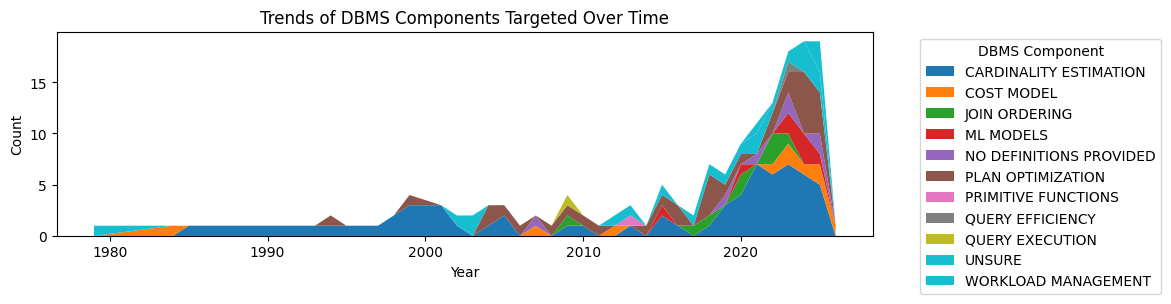

In [19]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('DBMS Component_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('DBMS Component_', '') if x.startswith('DBMS Component_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of DBMS Components Targeted Over Time")
plt.legend(title="DBMS Component", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of DBMS Components Targeted

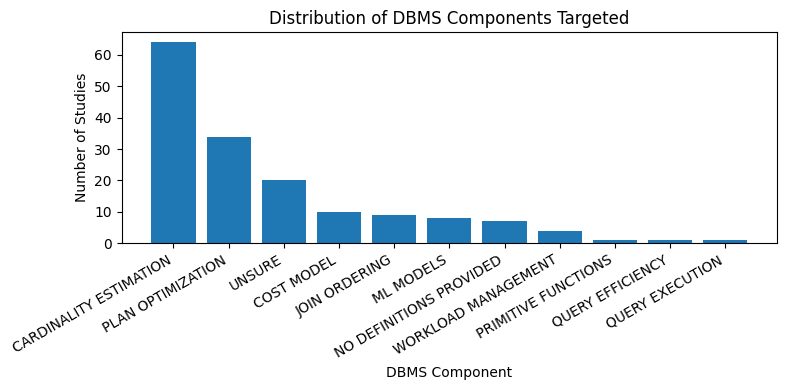

In [20]:
plot_multilabel_distribution(answers_df_encoded, "DBMS Component", "Distribution of DBMS Components Targeted")

### DBMS Components Targeted vs Type of Evaluation

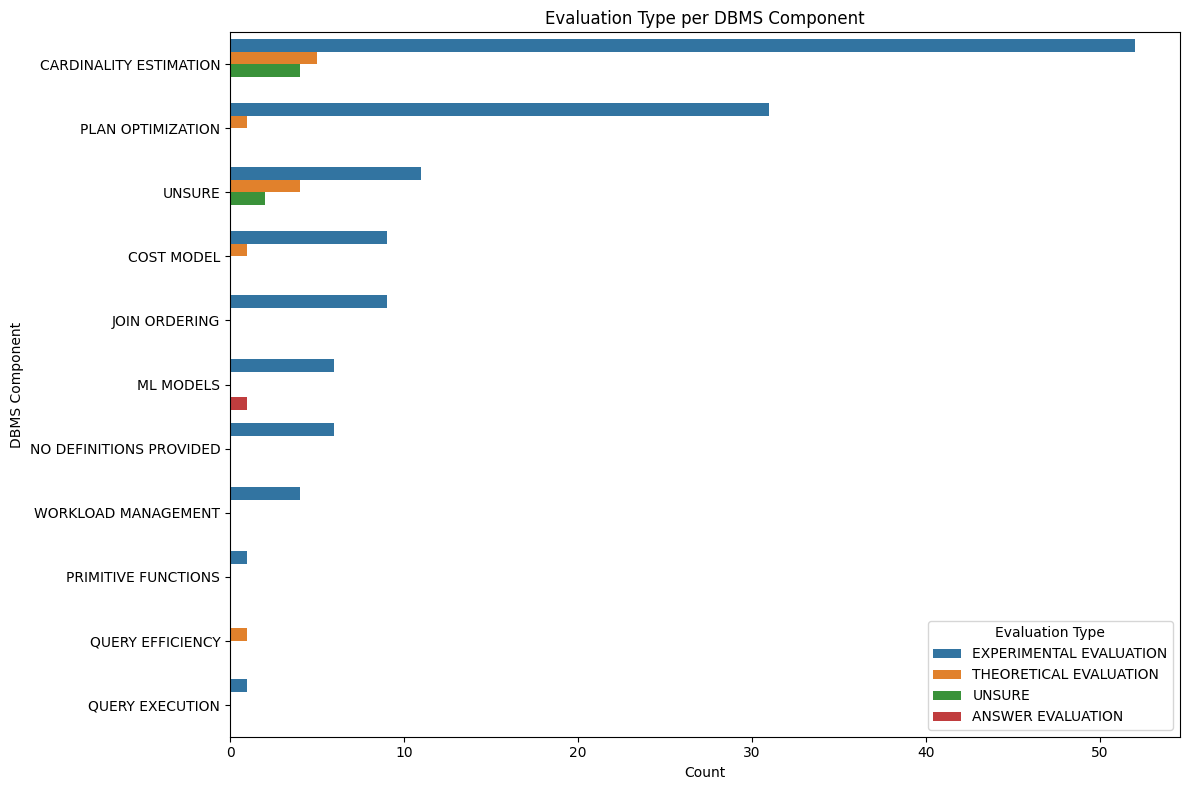

In [21]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Evaluation Type"
)

### DBMS Components Targeted vs Technique Proposed

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/3258963335.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


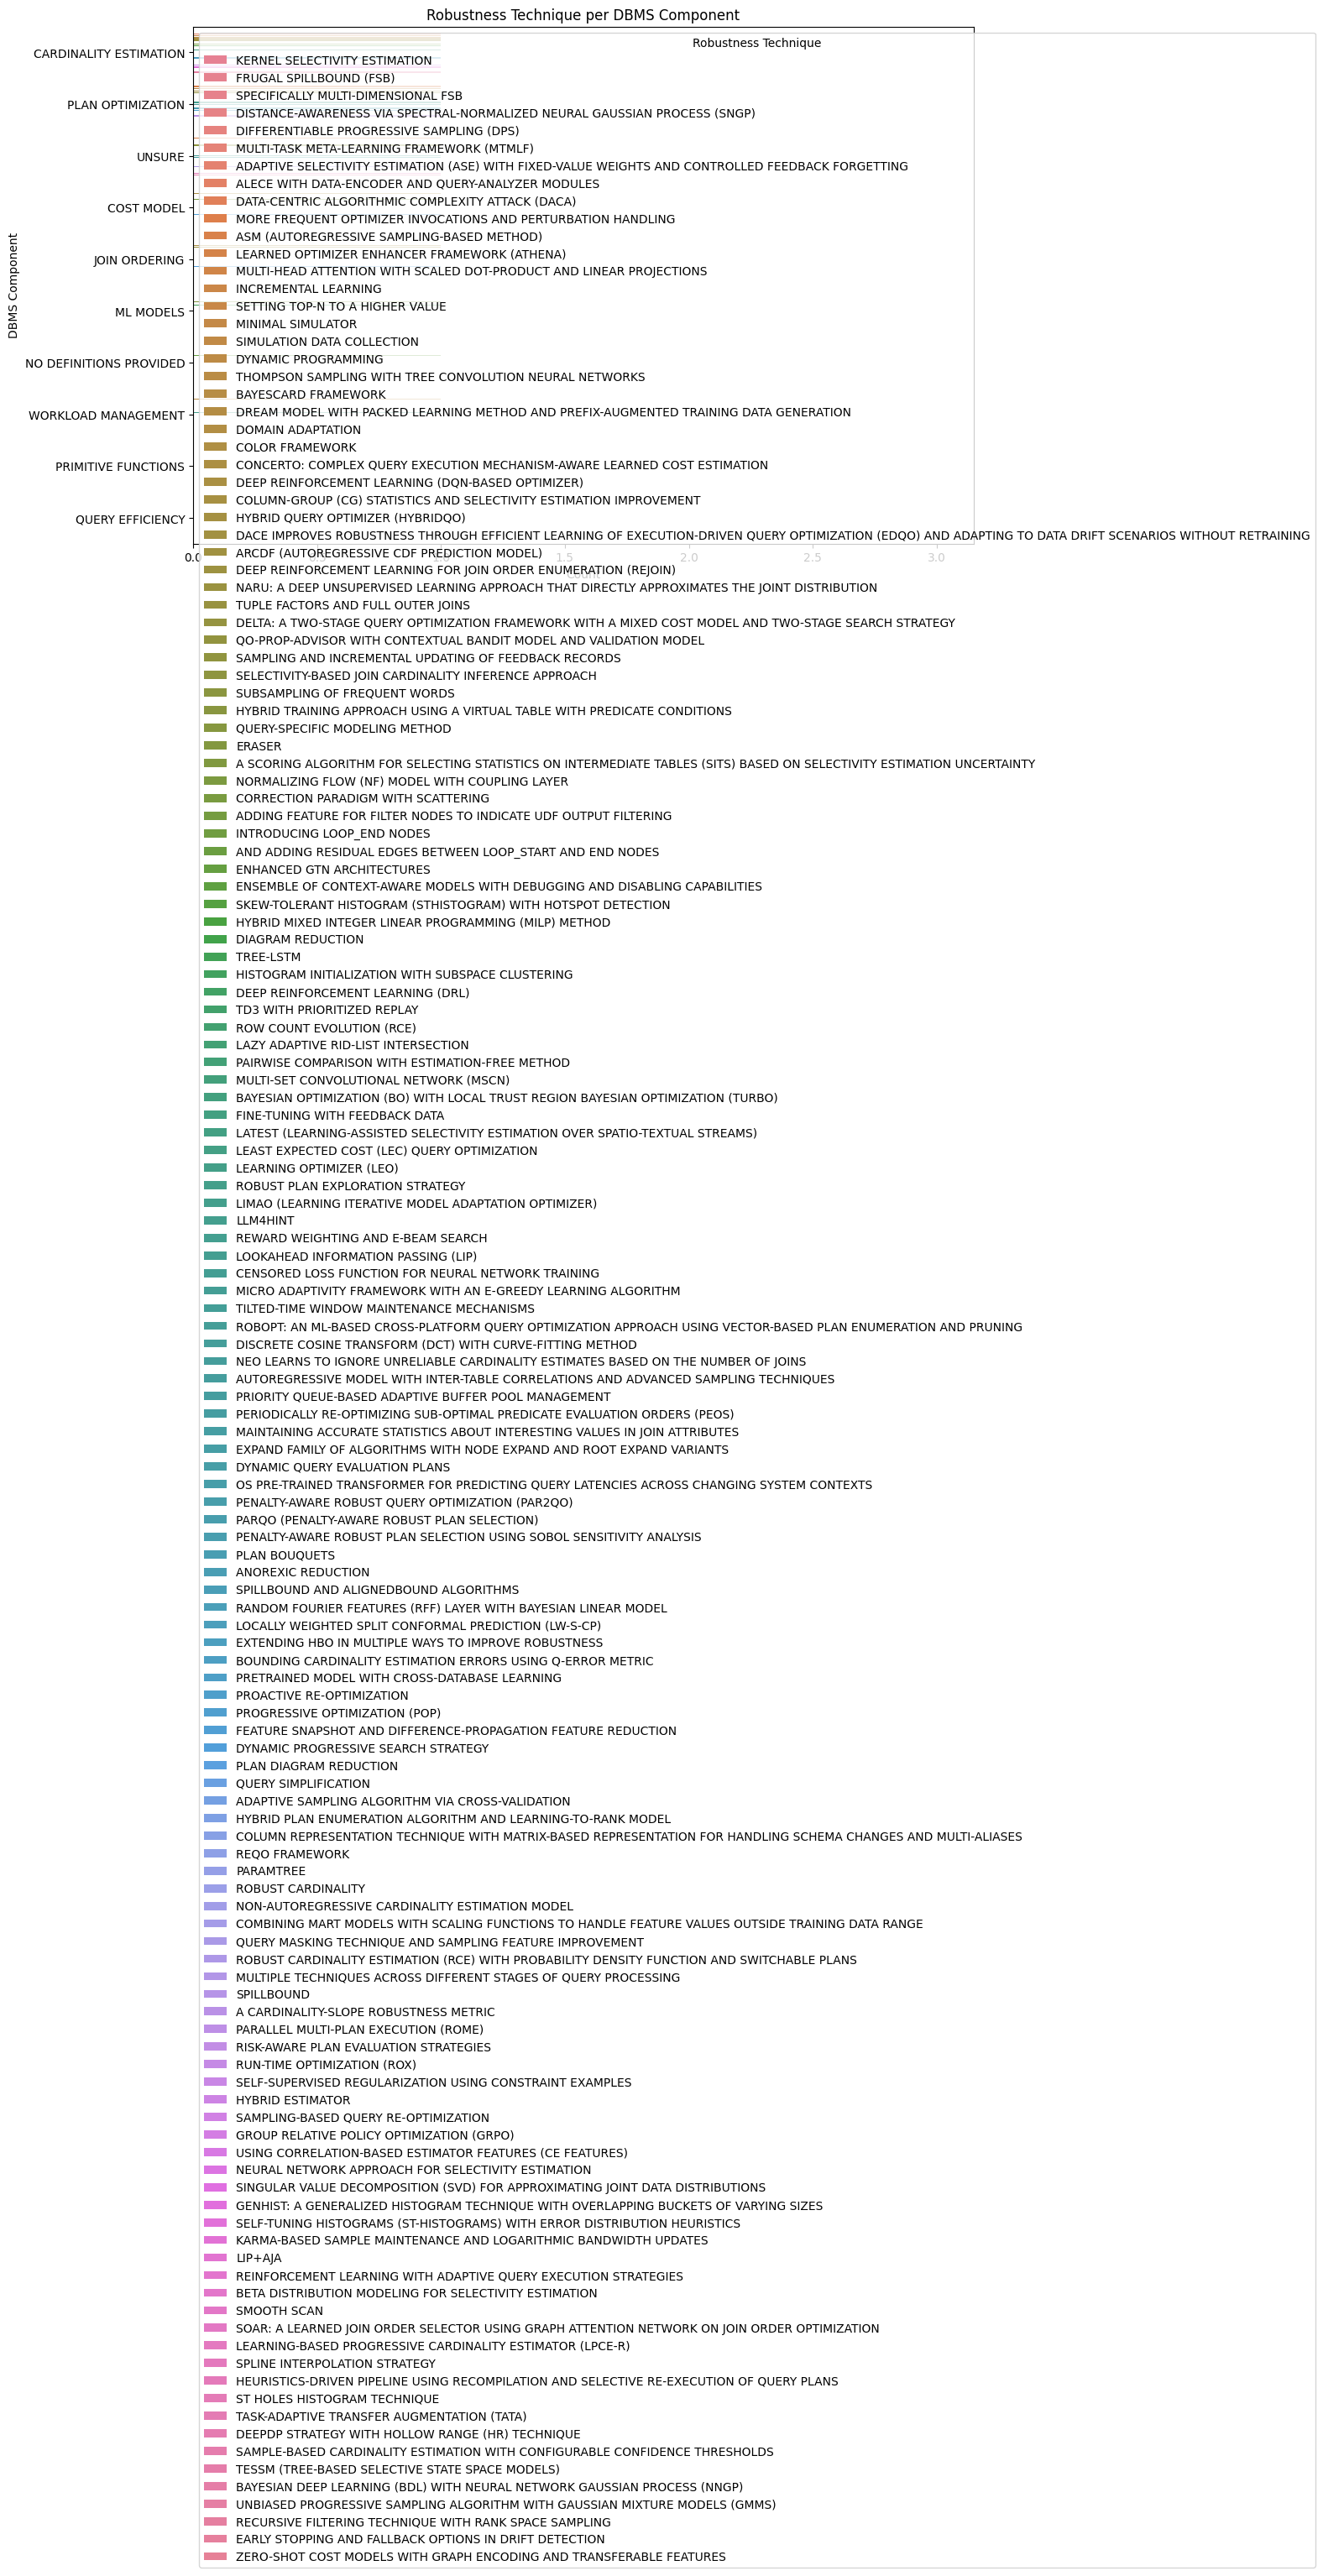

In [22]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Robustness Technique"
)

### DBMS Components Targeted vs Metrics Used

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/3258963335.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


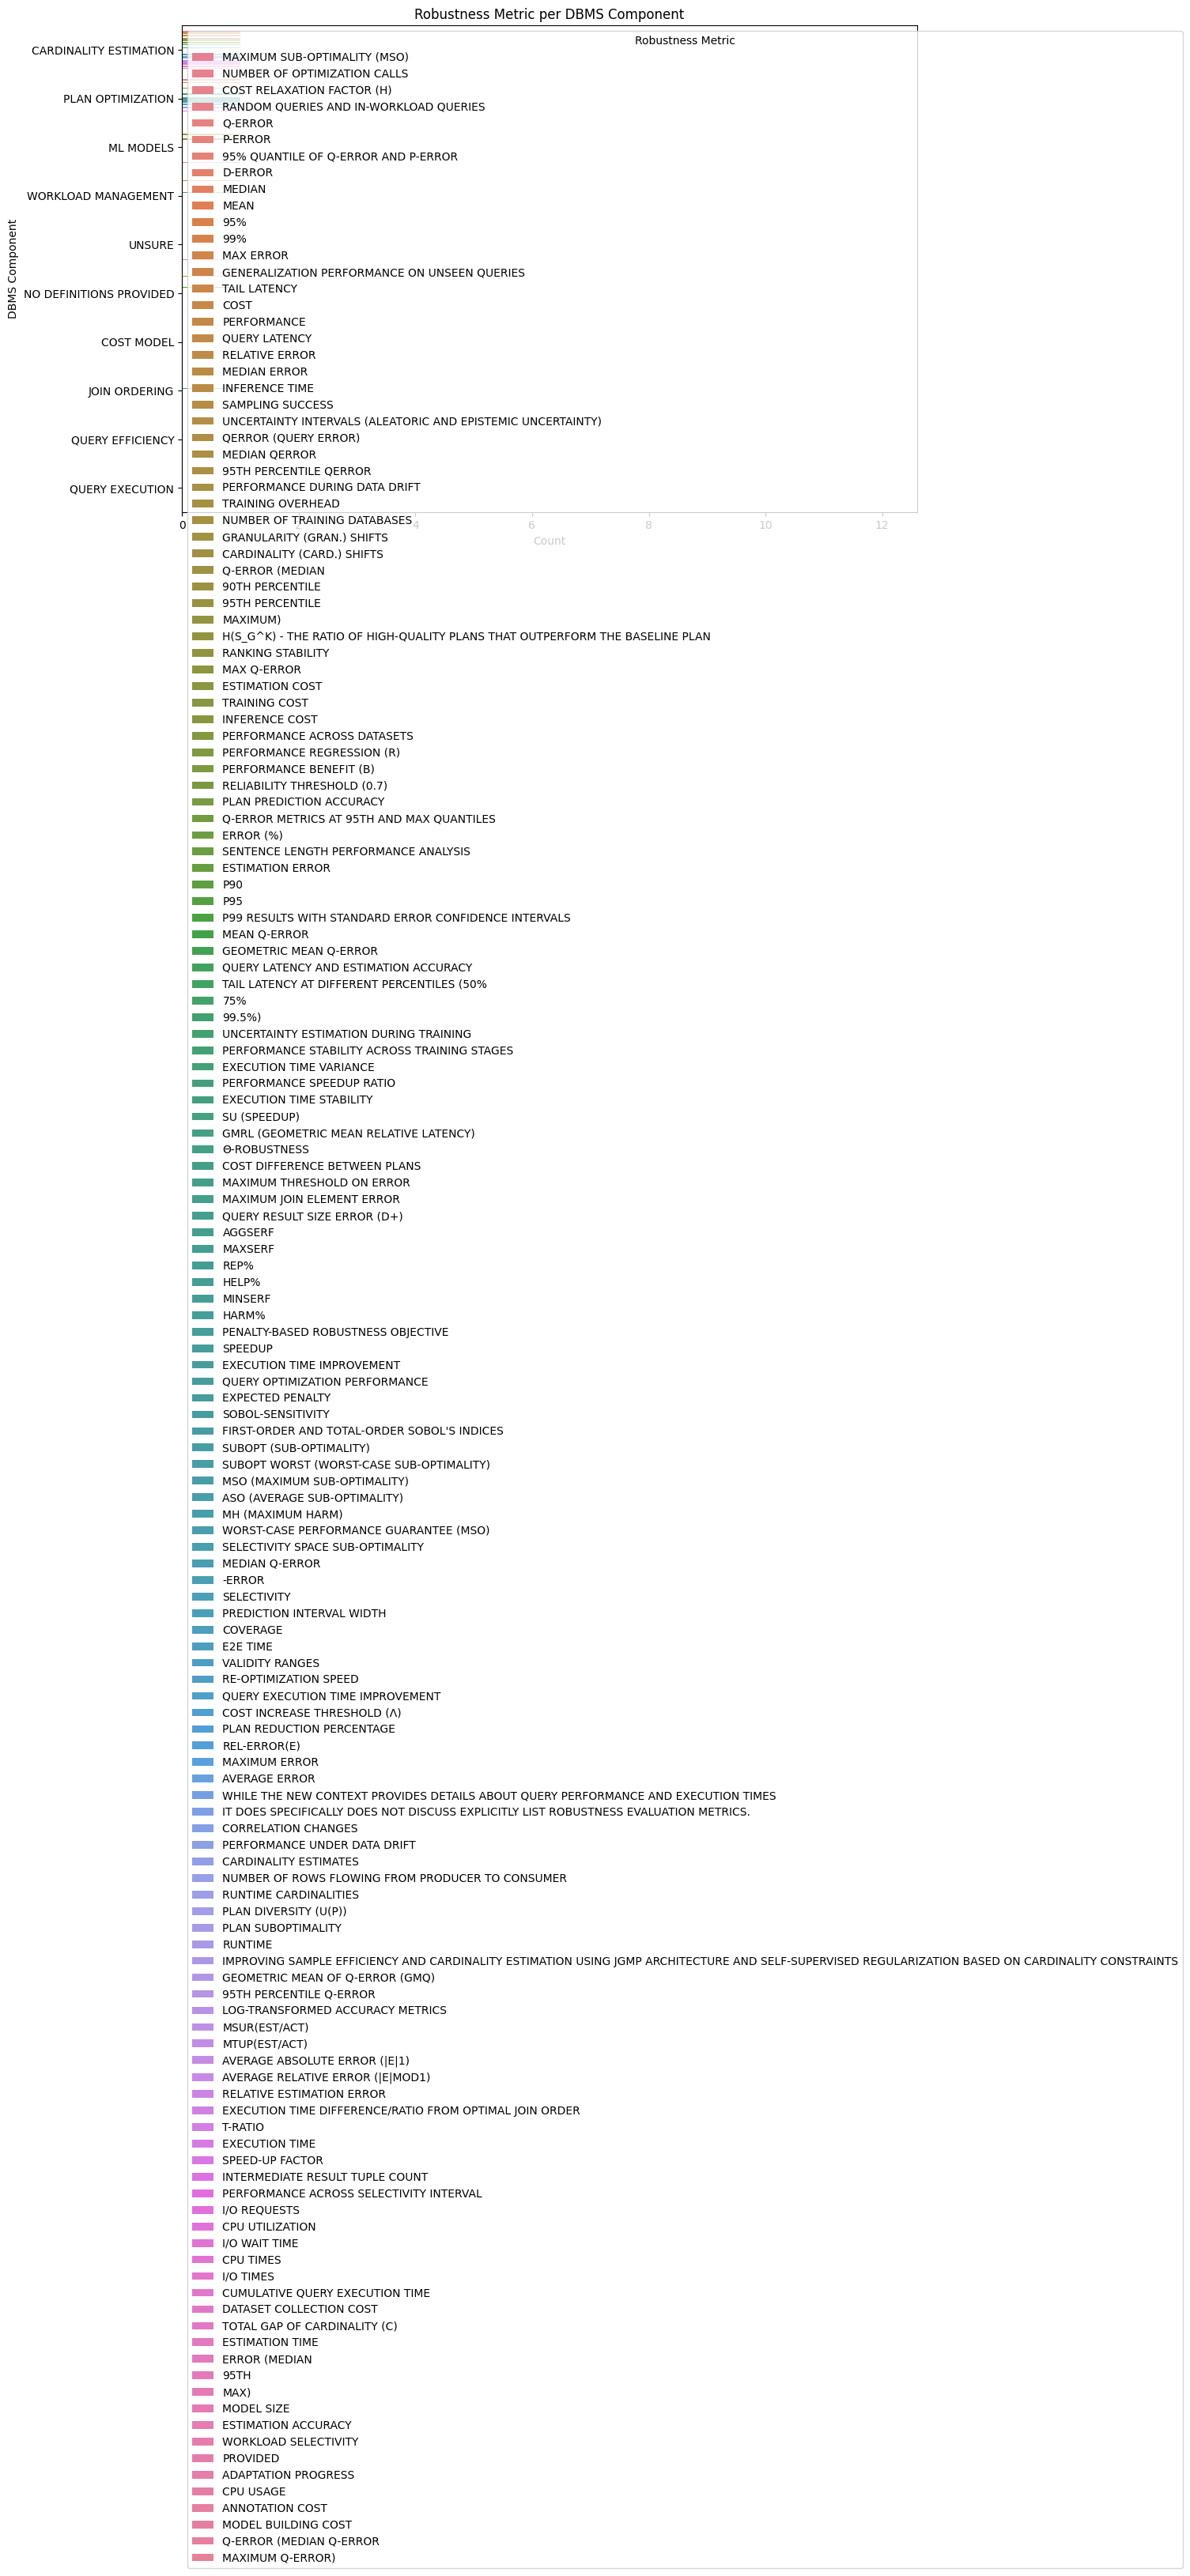

In [23]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Robustness Metric"
)


### DBMS Components Targeted vs Benchmarks Used

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/3258963335.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


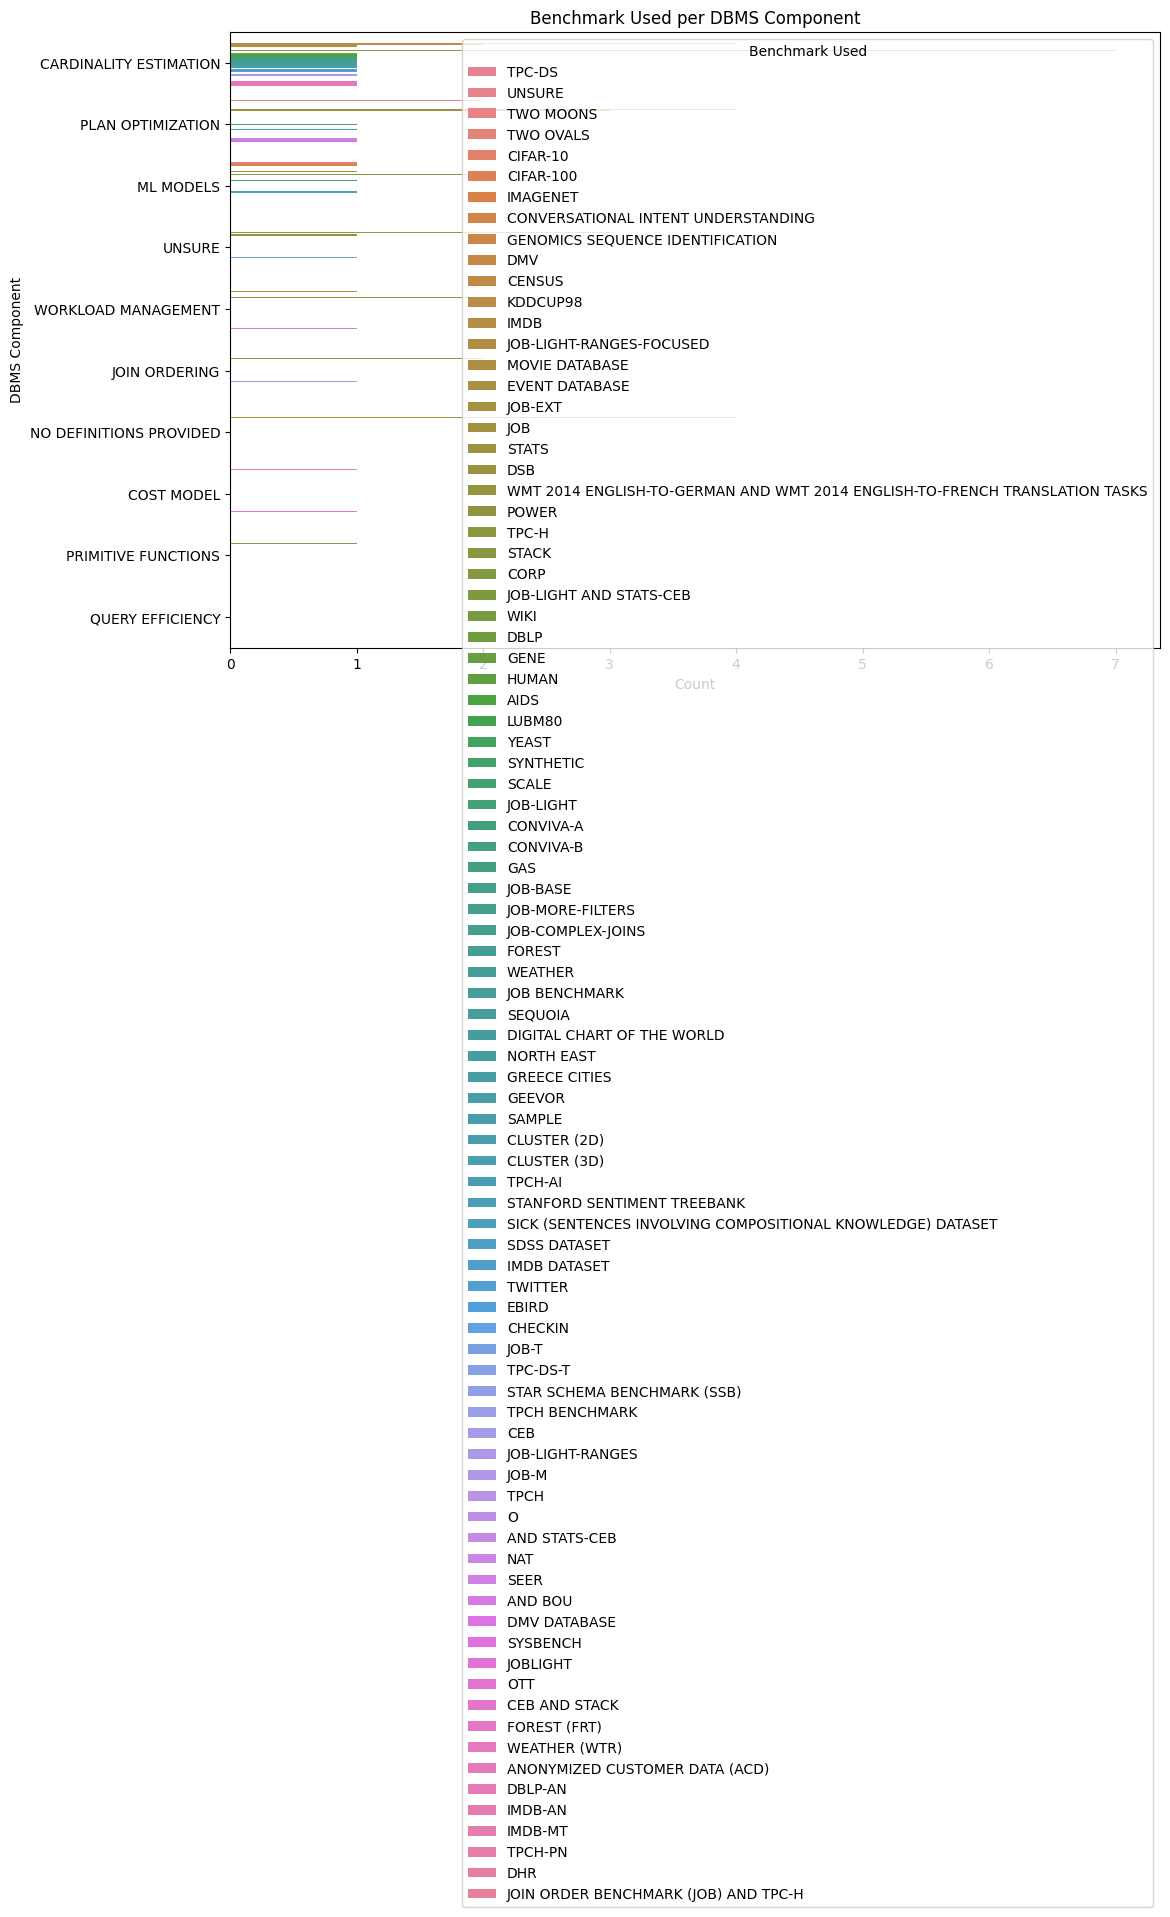

In [24]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Benchmark Used"
)


### DBMS Component Targeted vs Controlled Features

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/3258963335.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


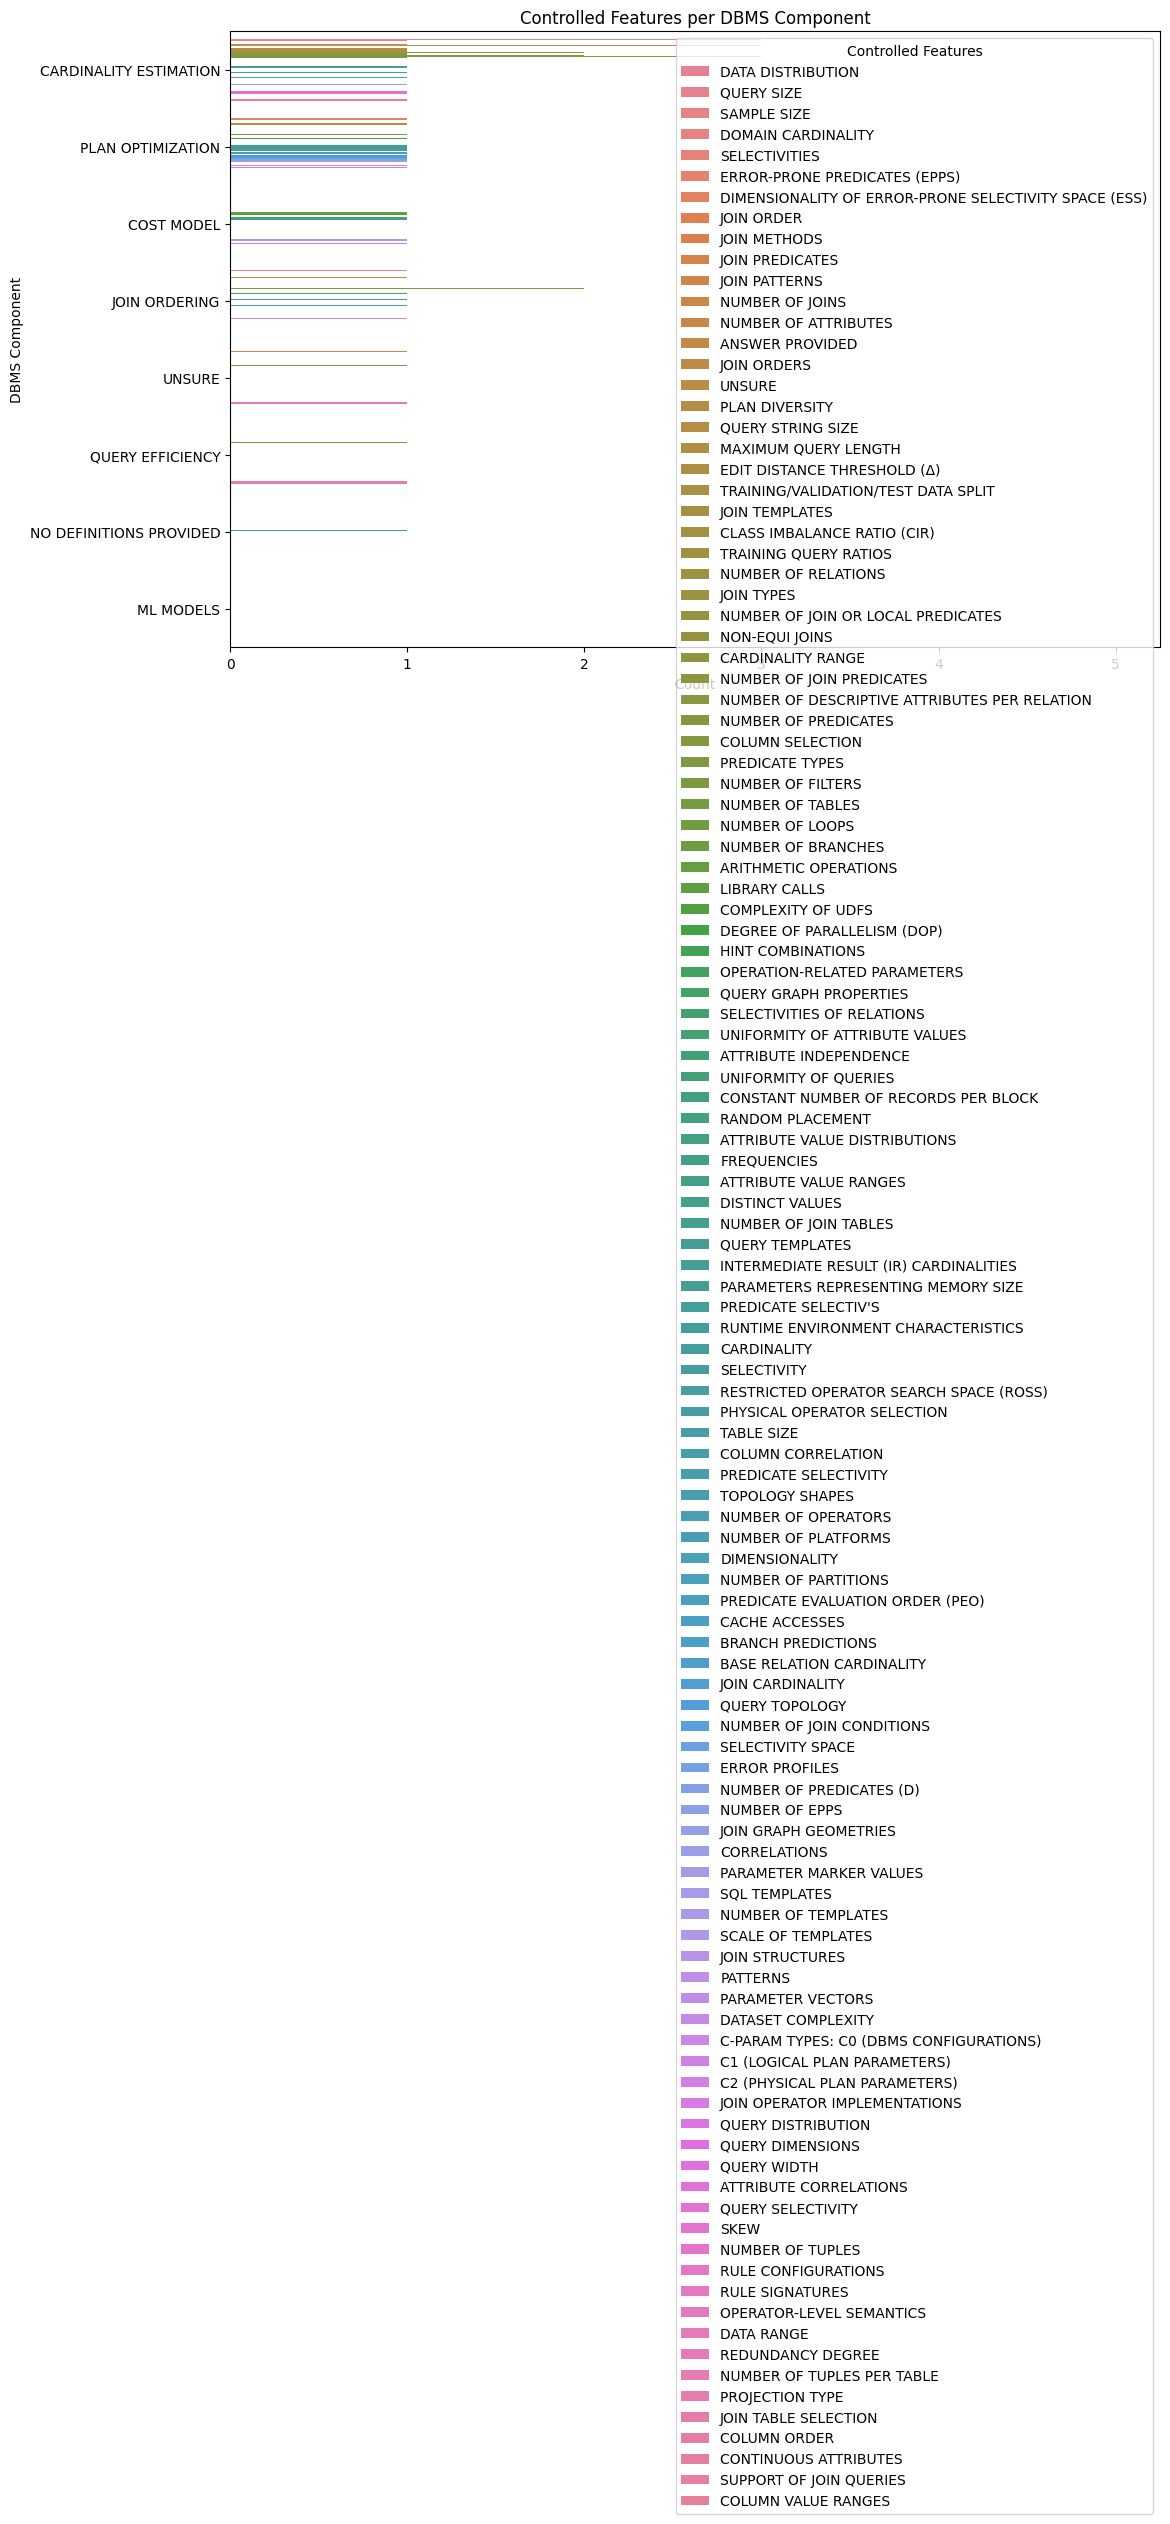

In [25]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Controlled Features"
)


### DBMS Component Targeted per Machine Learning Task Type

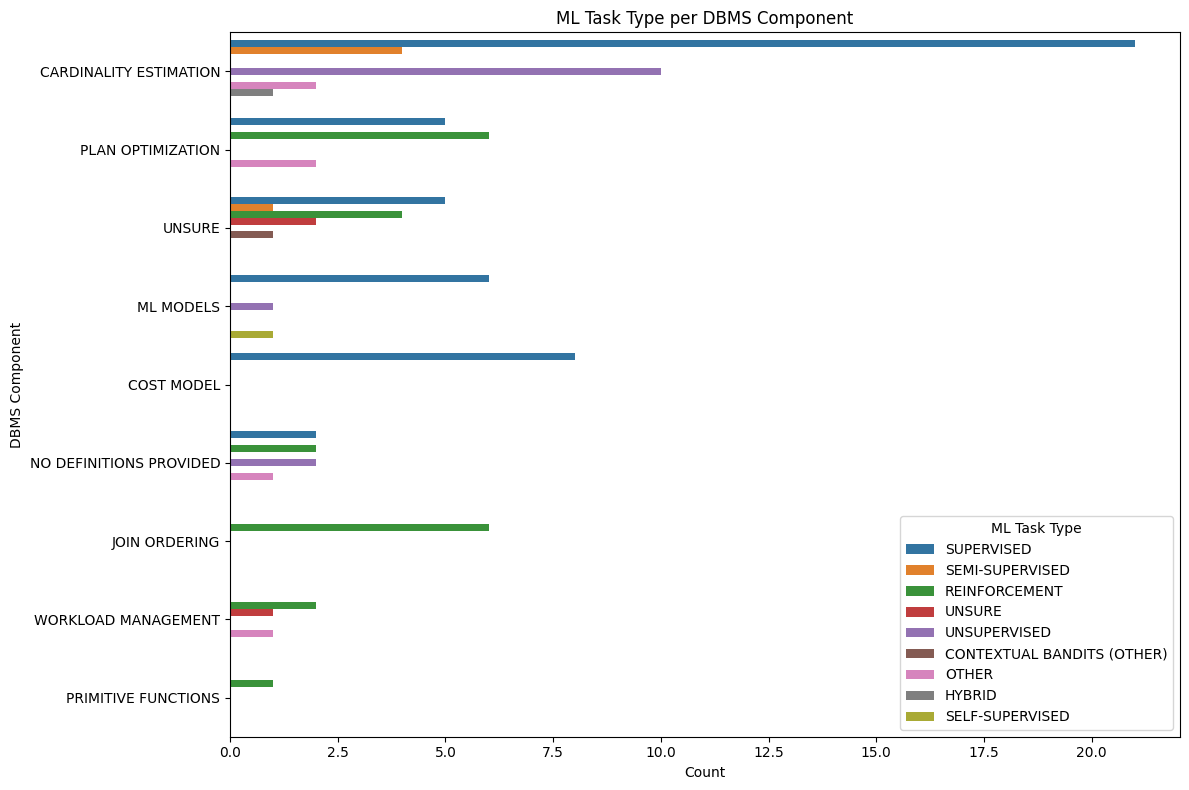

In [26]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="ML Task Type"
)


### Machine Learning Paradigm Used per DBMS Component Targeted

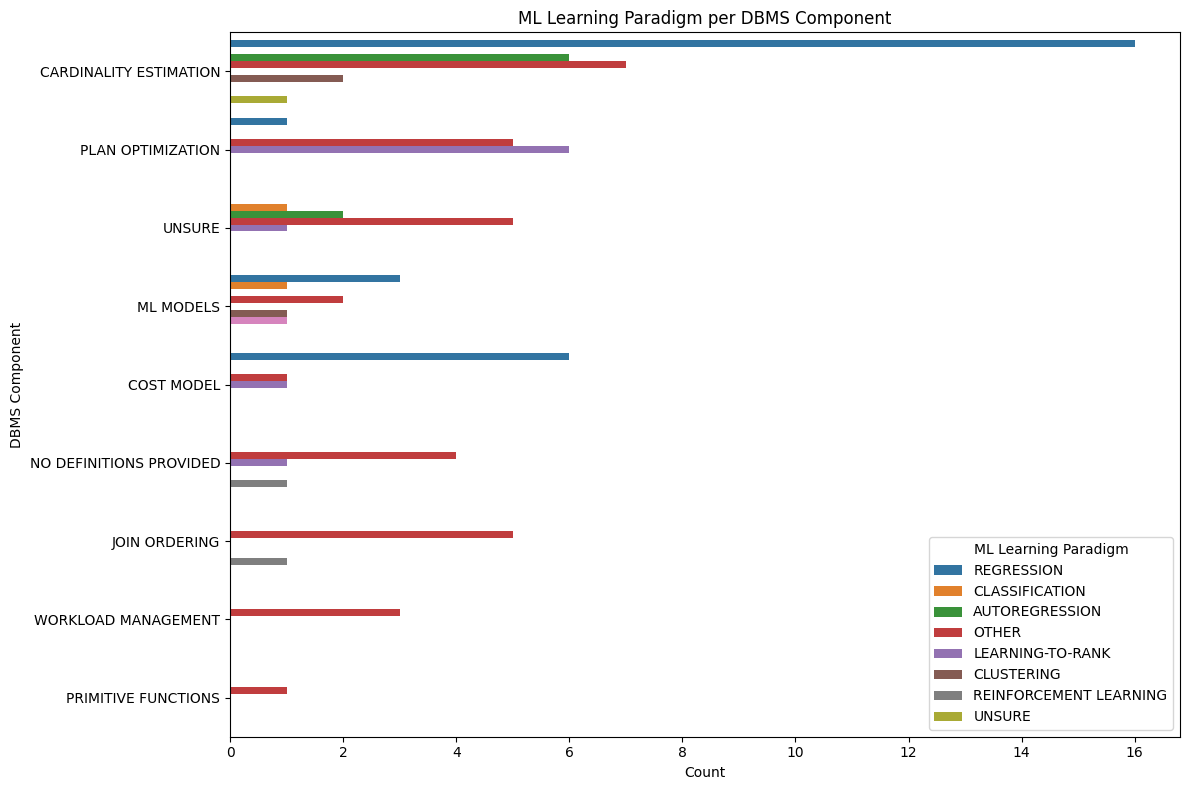

In [27]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="ML Learning Paradigm"
)


### Input Encoding Methods per DBMS Component

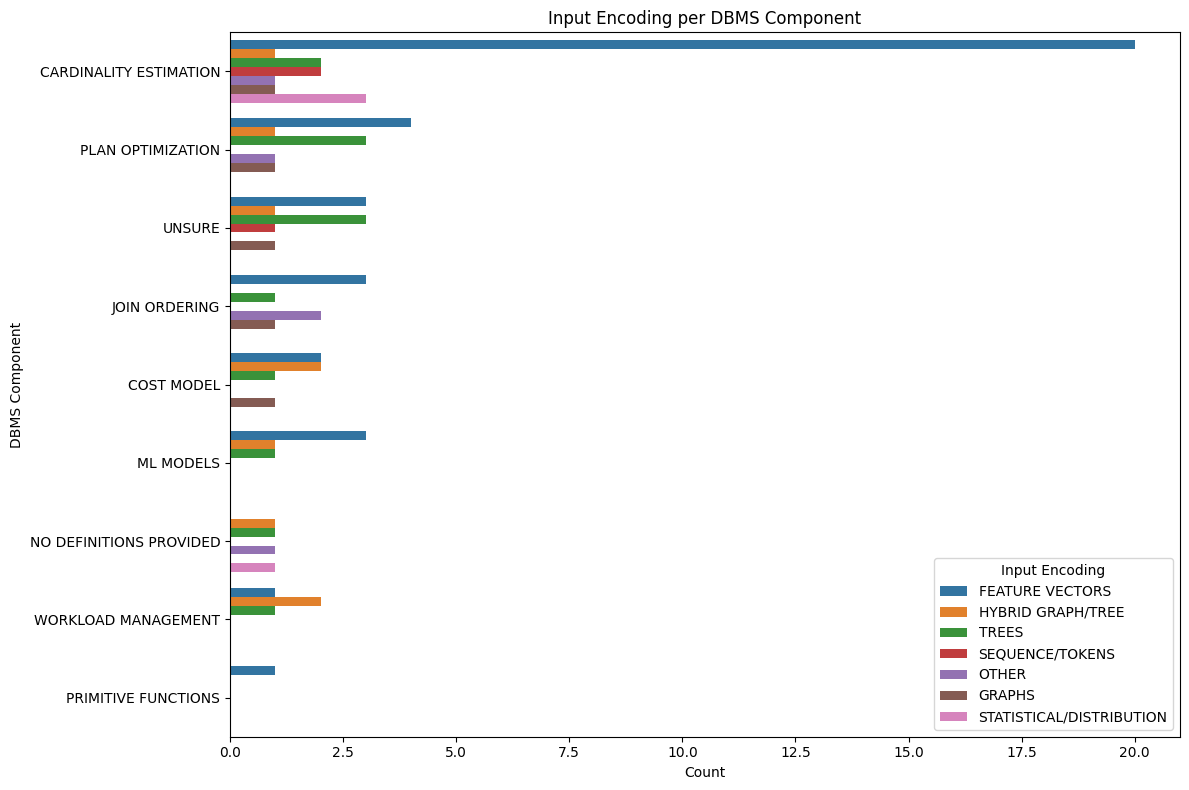

In [28]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Input Encoding"
)


### DBMS Components Targeted vs Uncertainty Evaluation

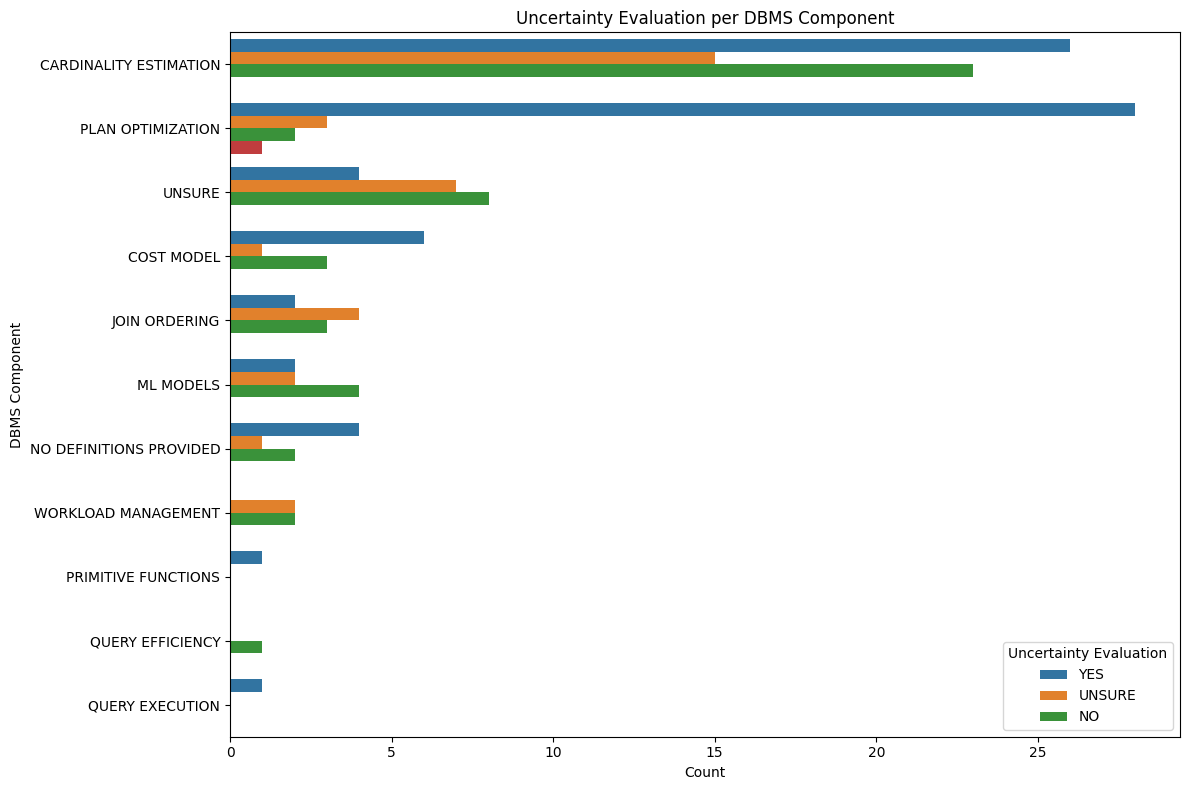

In [29]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Uncertainty Evaluation"
)

### Architecture Used per DBMS Component

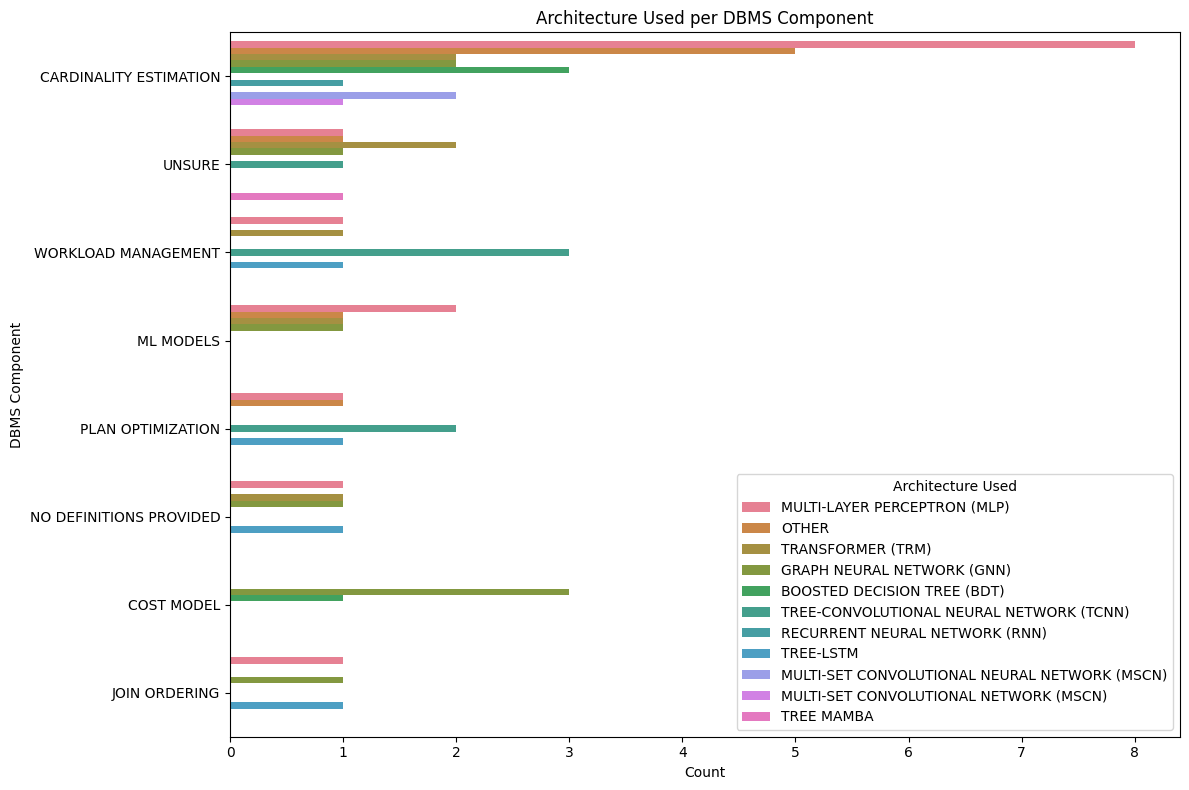

In [30]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Architecture Used"
)

## Analysis on the Types of Evaluation

### Types of Evaluation Done Over Time

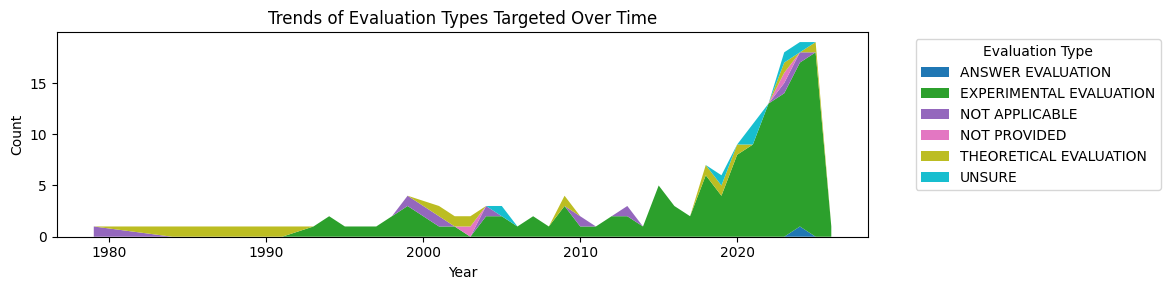

In [31]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Evaluation Type_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Evaluation Type_', '') if x.startswith('Evaluation Type_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Evaluation Types Targeted Over Time")
plt.legend(title="Evaluation Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Evaluation Type

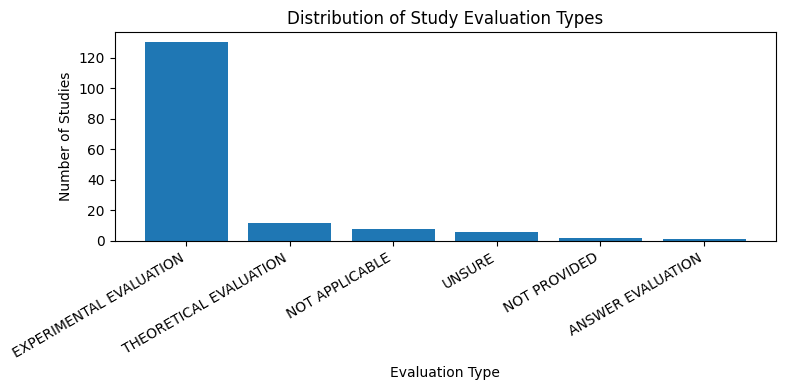

In [32]:
plot_multilabel_distribution(answers_df_encoded, "Evaluation Type", "Distribution of Study Evaluation Types")

## Analysis of Benchmarks Used

### Benchmarks Used Over Time

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/2647101649.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


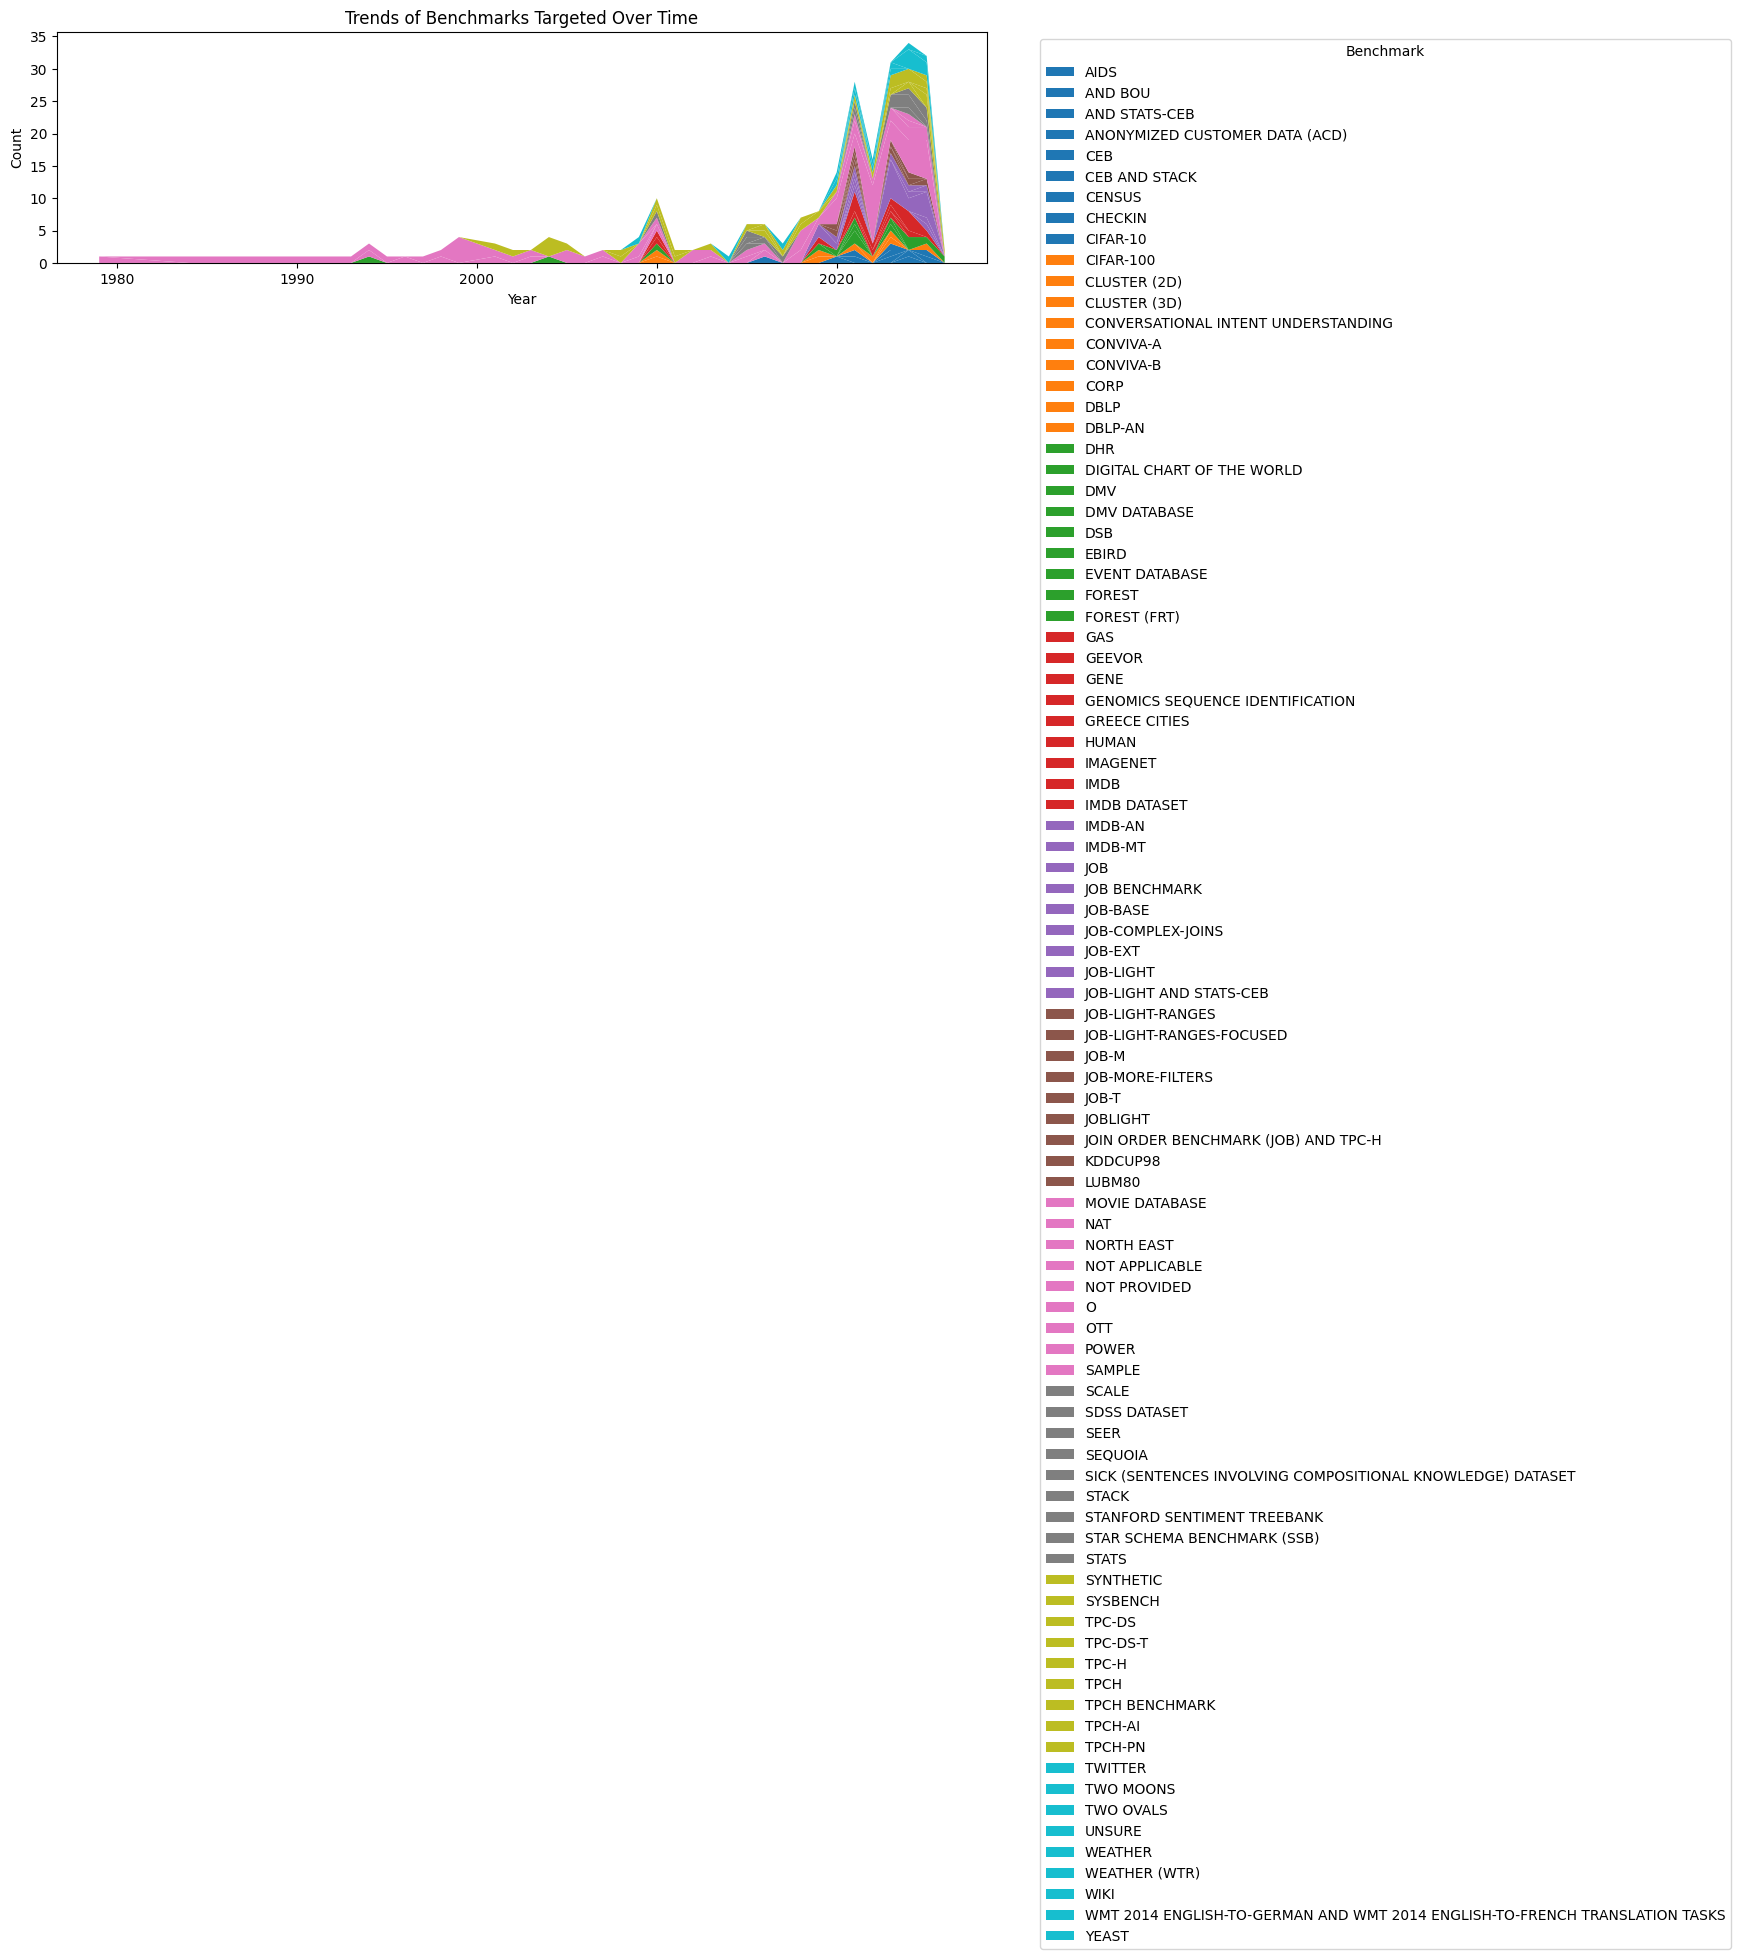

In [33]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Benchmark Used_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Benchmark Used_', '') if x.startswith('Benchmark Used_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Benchmarks Targeted Over Time")
plt.legend(title="Benchmark", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Benchmarks Used

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/3105094420.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


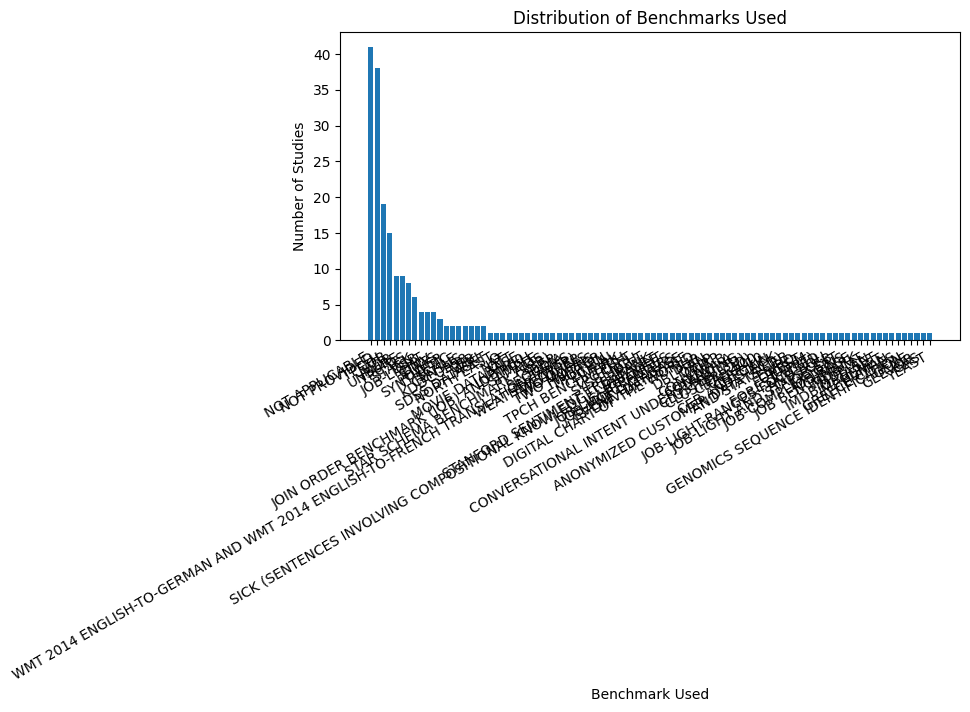

In [34]:
plot_multilabel_distribution(answers_df_encoded, "Benchmark Used", "Distribution of Benchmarks Used")

### Data Source per Benchmark

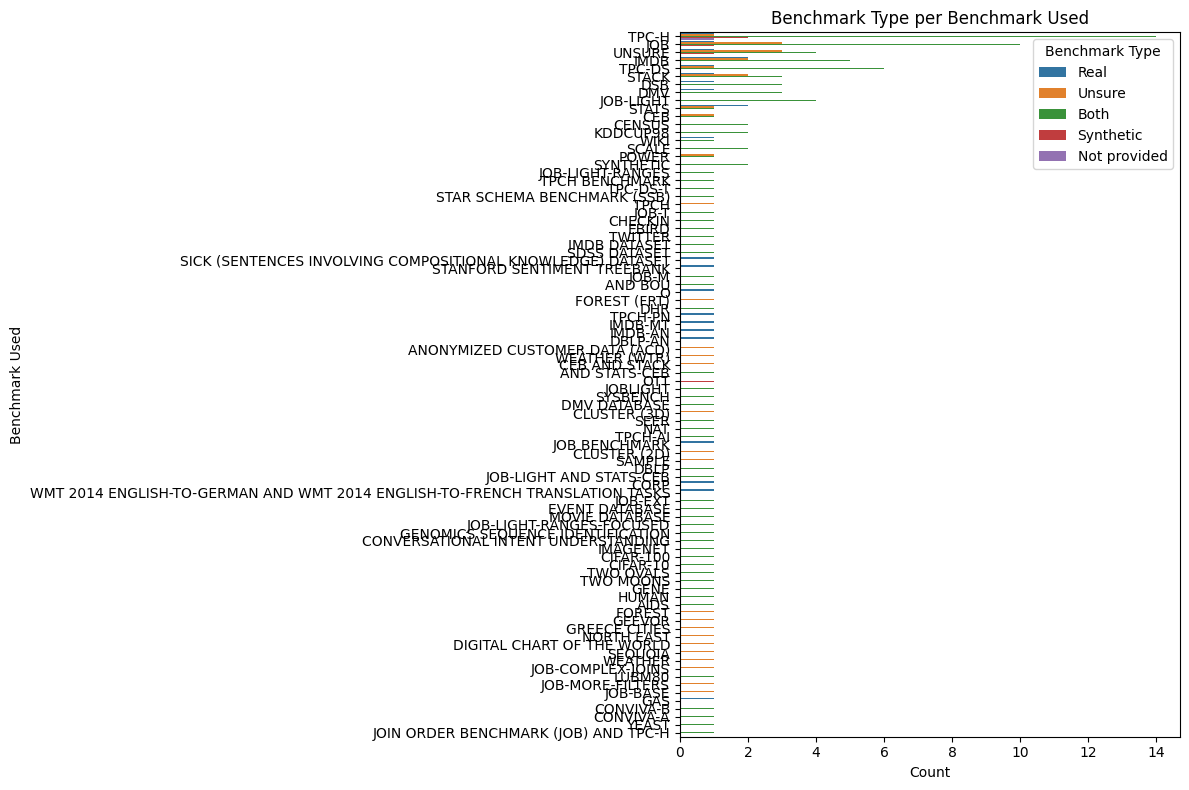

In [35]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Benchmark Used",
    col_y="Benchmark Type"
)

### Machine Learning Task Types per Benchmark

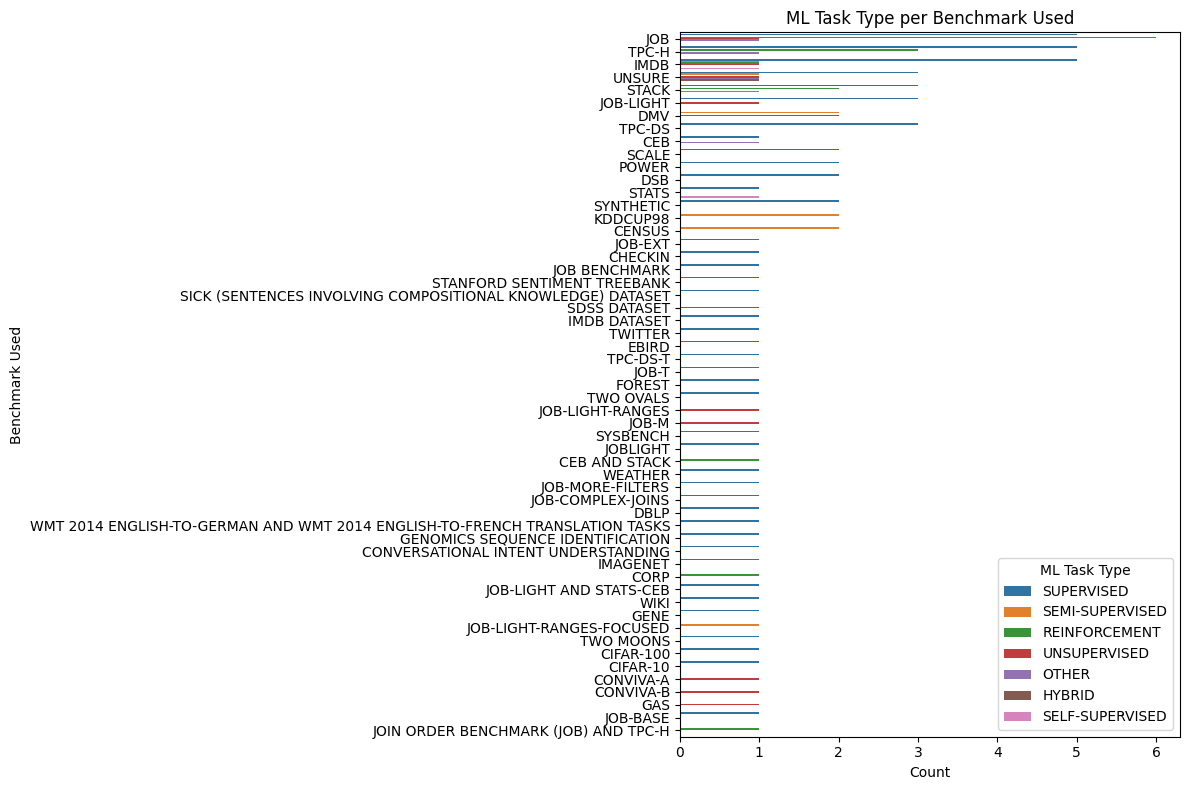

In [36]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Benchmark Used",
    col_y="ML Task Type"
)

### Machine Learning Paradigms per Benchmark

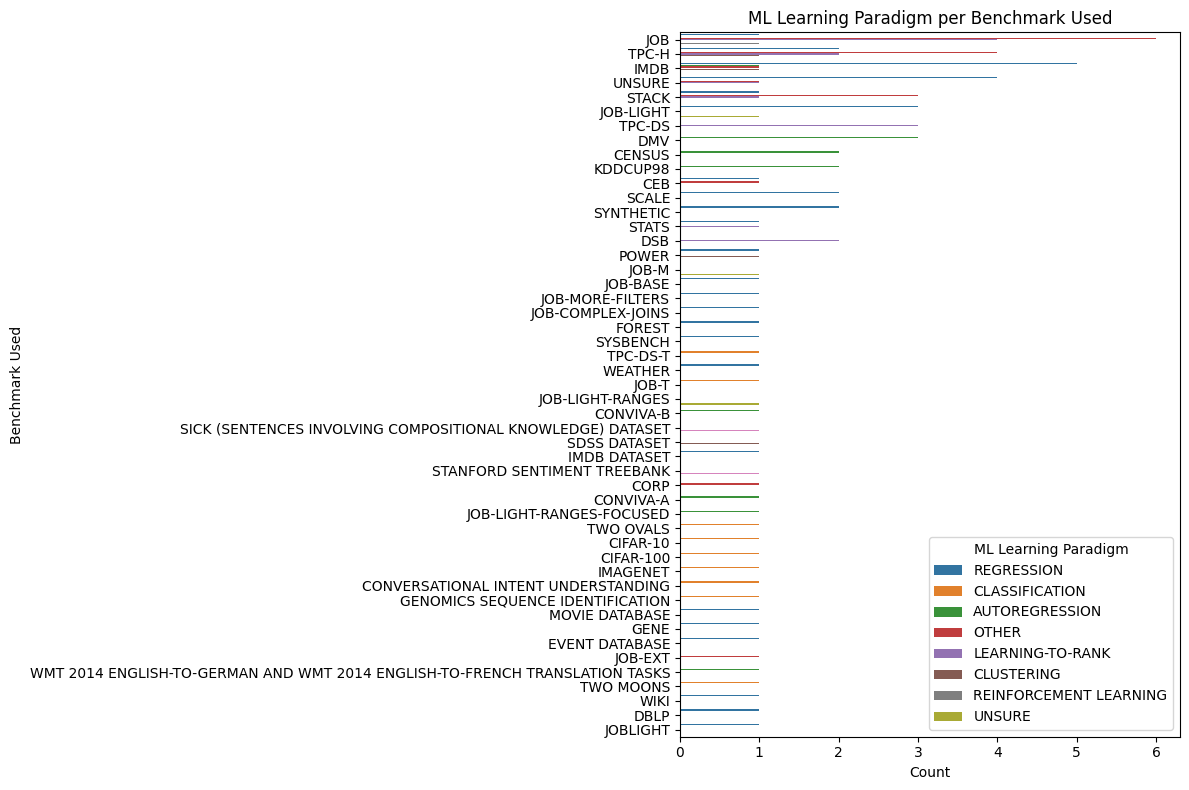

In [37]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Benchmark Used",
    col_y="ML Learning Paradigm"
)

### Benchmark vs Uncertainty Evaluation

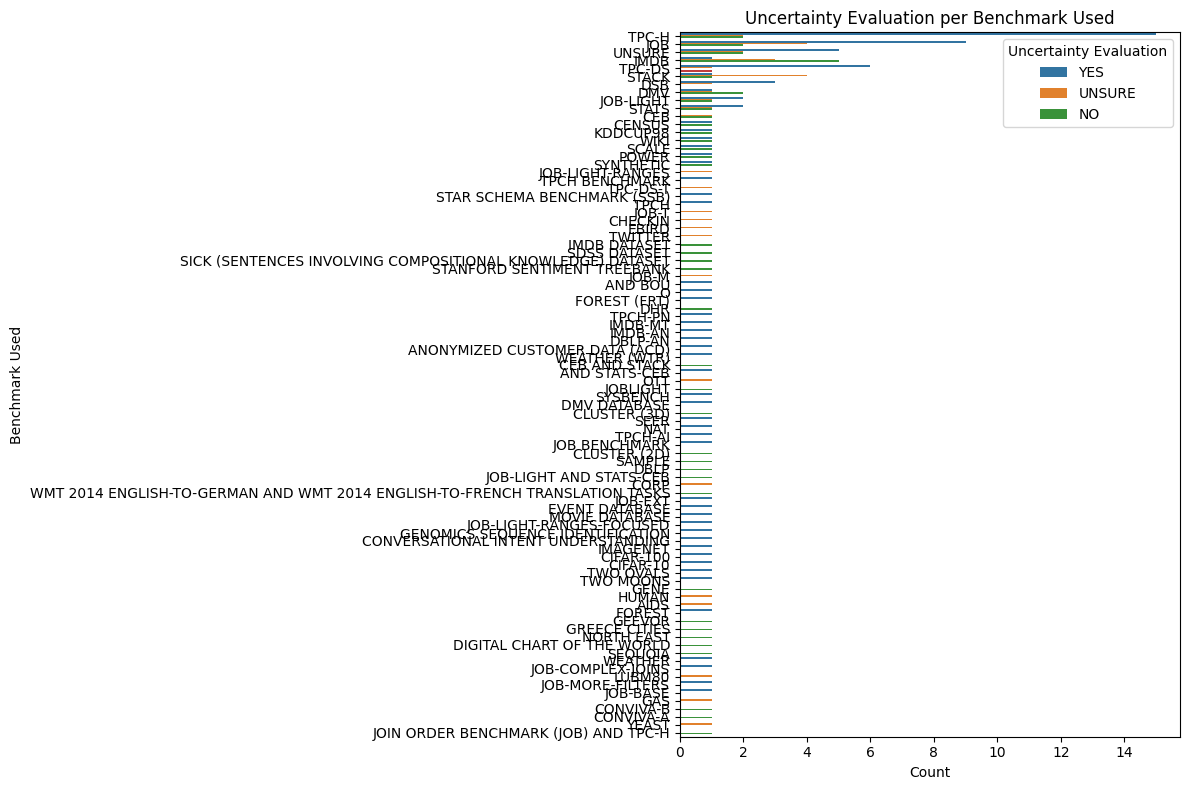

In [38]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Benchmark Used",
    col_y="Uncertainty Evaluation"
)

### Benchmark vs Out of Distribution Evaluation

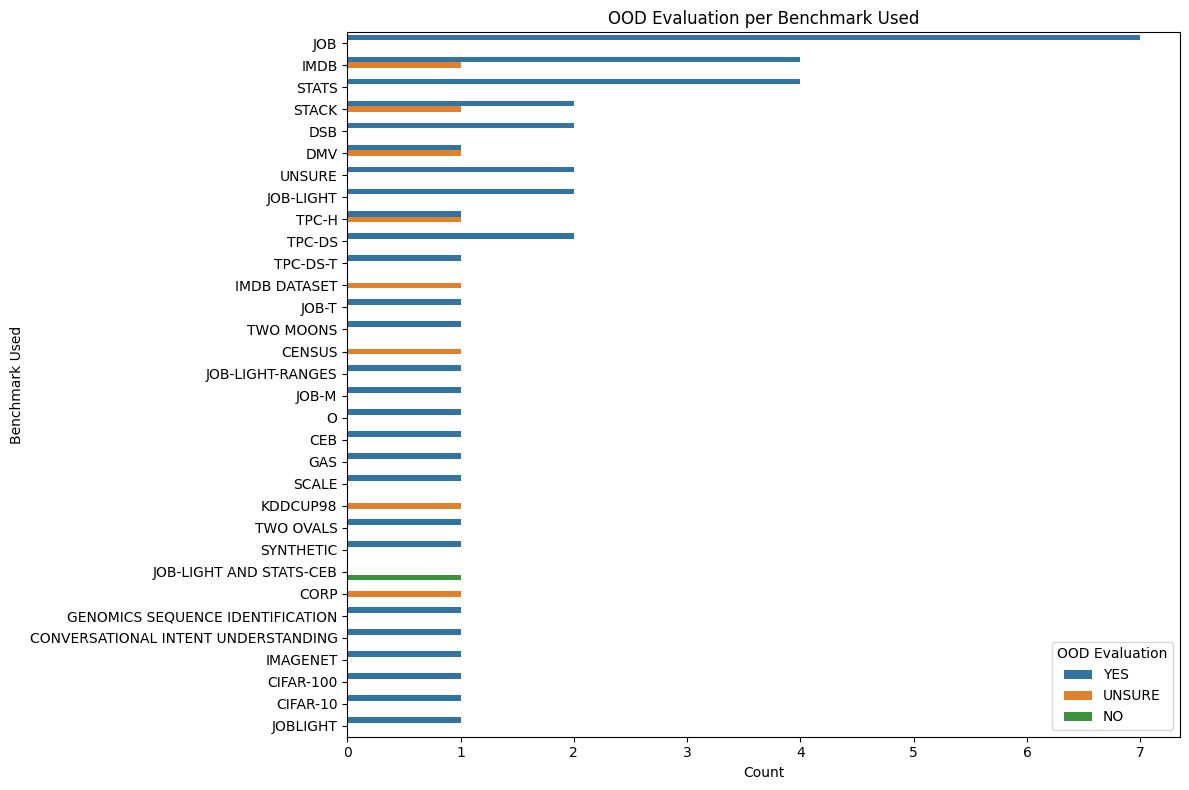

In [39]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Benchmark Used",
    col_y="OOD Evaluation"
)

## Analysis on Controlled Features

### Controlled Features During Training Over Time

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/2594641673.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


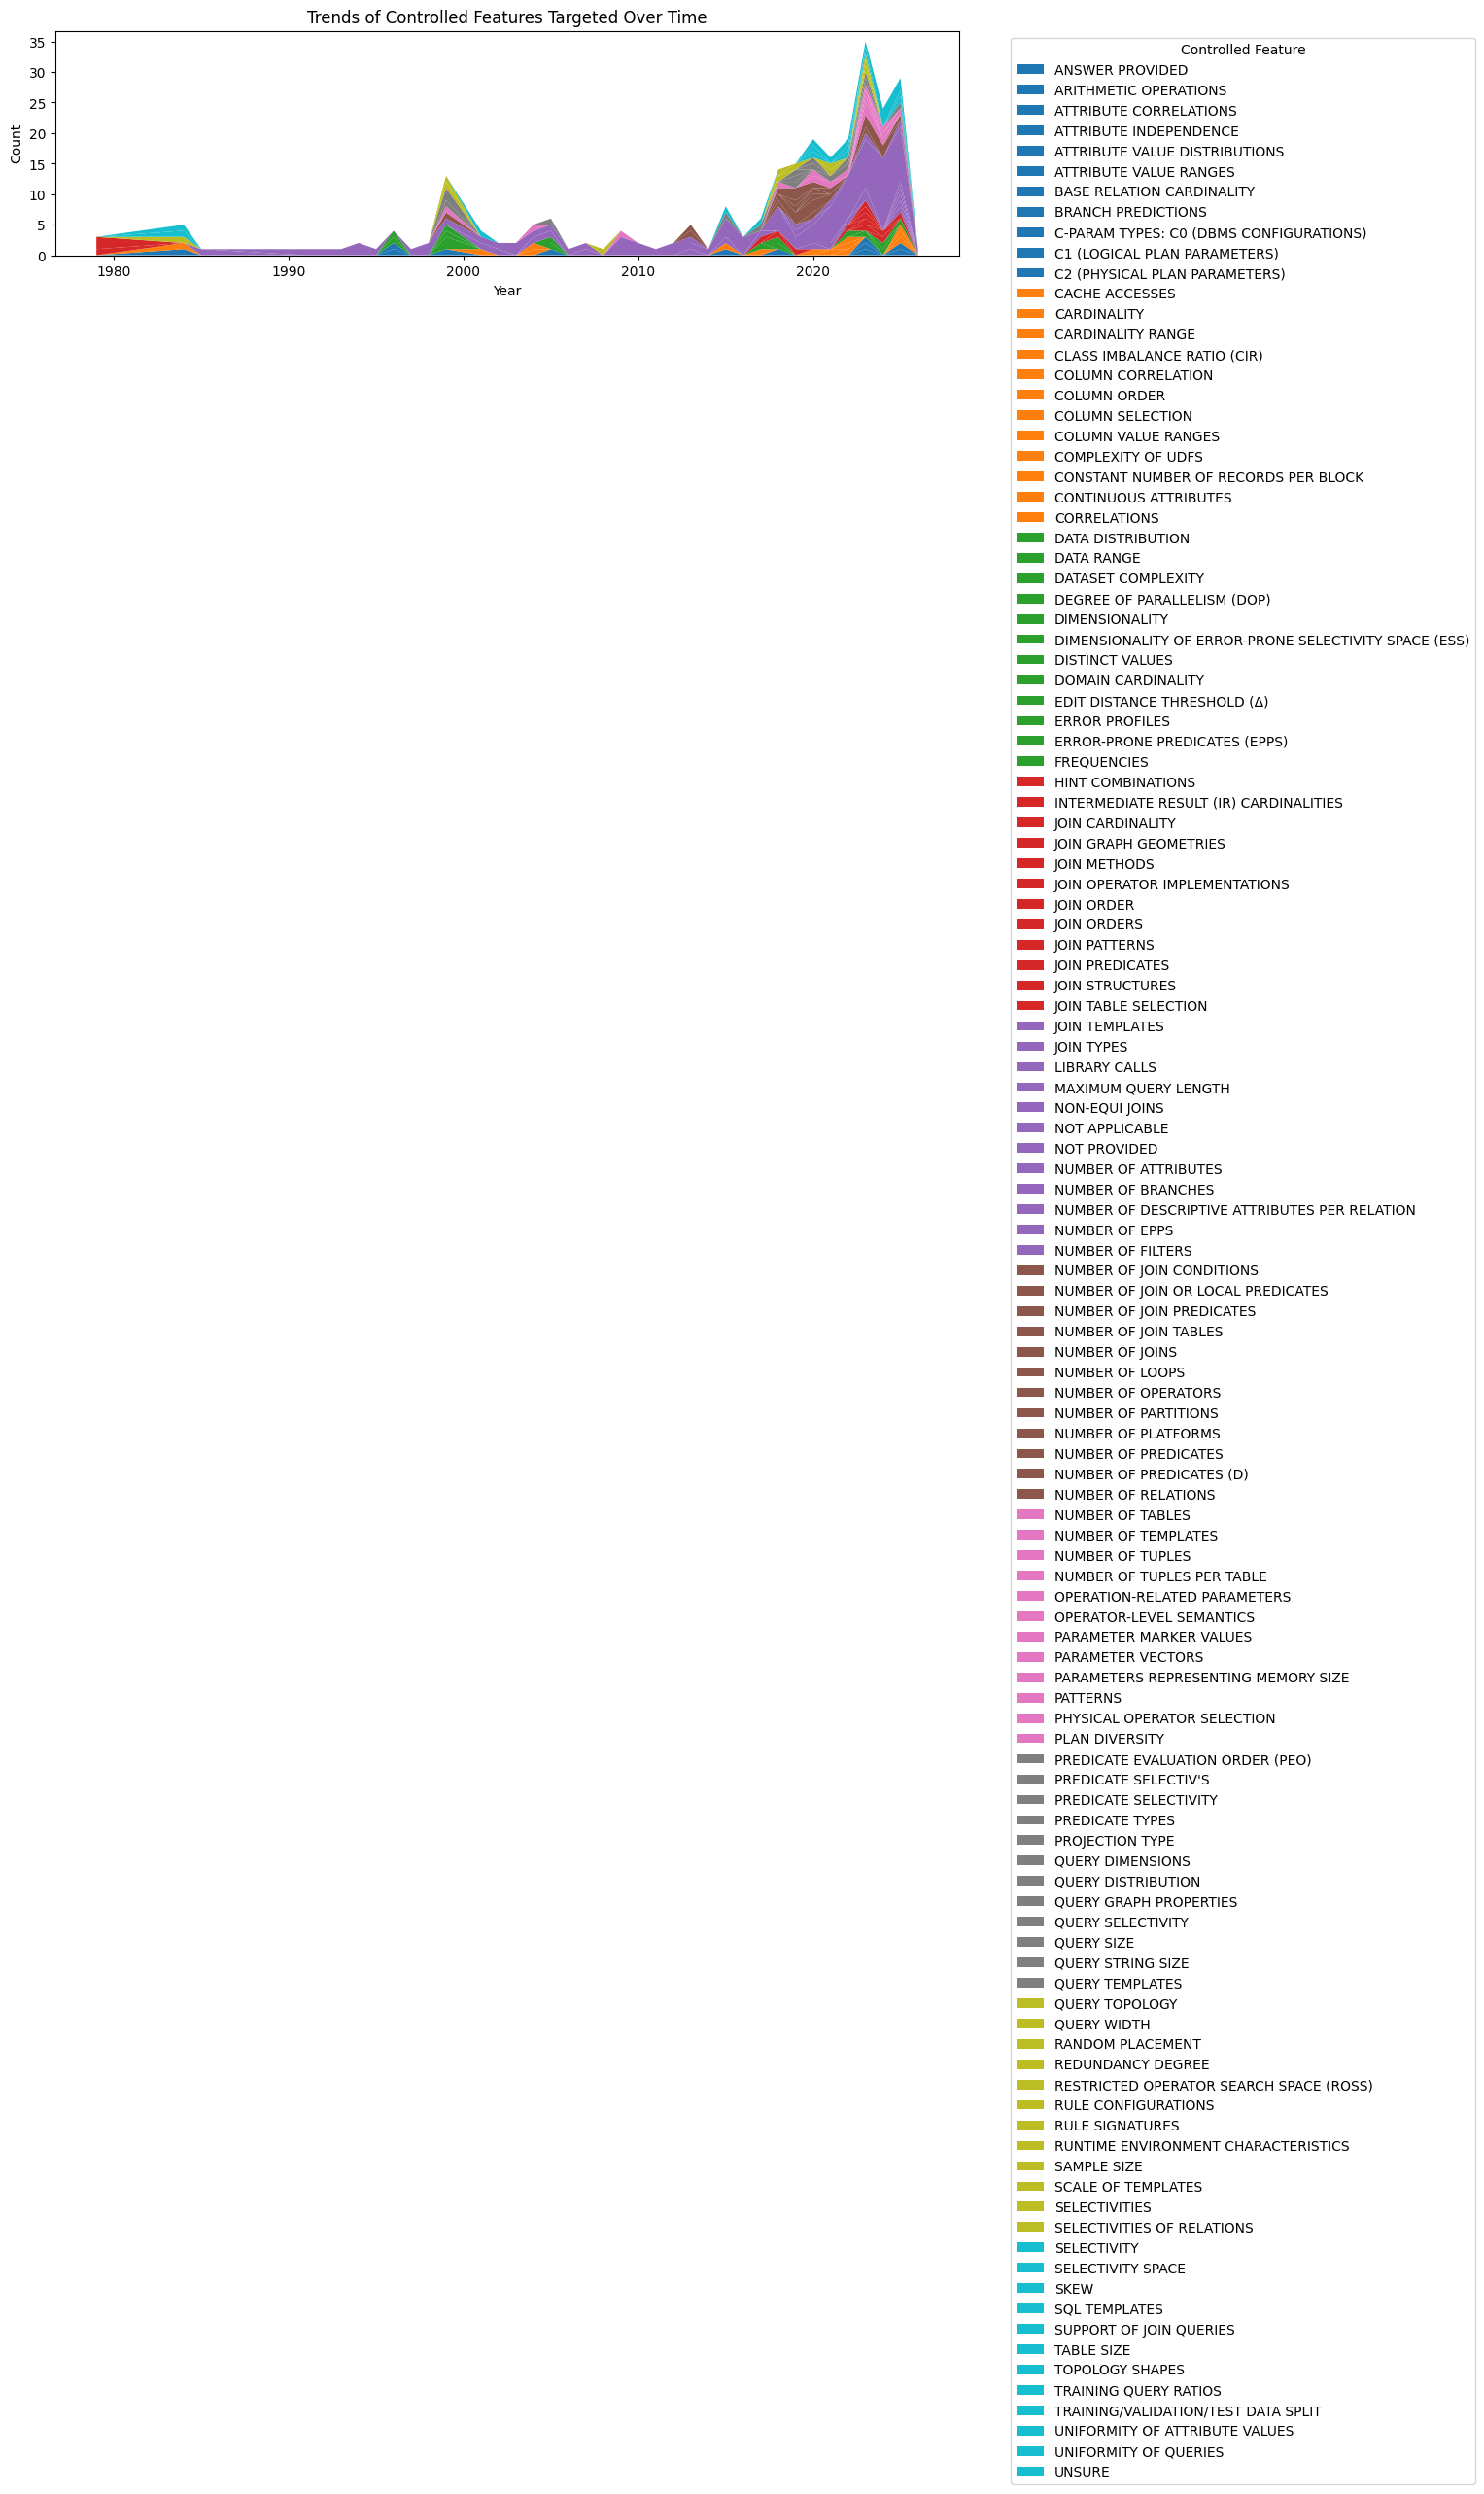

In [40]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Controlled Features_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Controlled Features_', '') if x.startswith('Controlled Features_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Controlled Features Targeted Over Time")
plt.legend(title="Controlled Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Features Controlled During Training

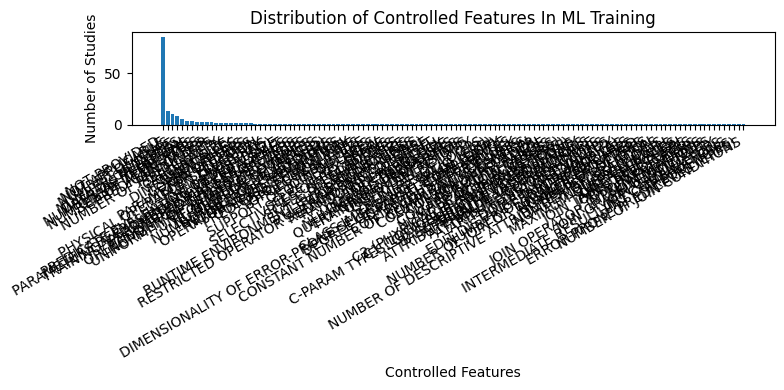

In [41]:
plot_multilabel_distribution(answers_df_encoded, "Controlled Features", "Distribution of Controlled Features In ML Training")

### Features Controlled During Training Per ML Task Type

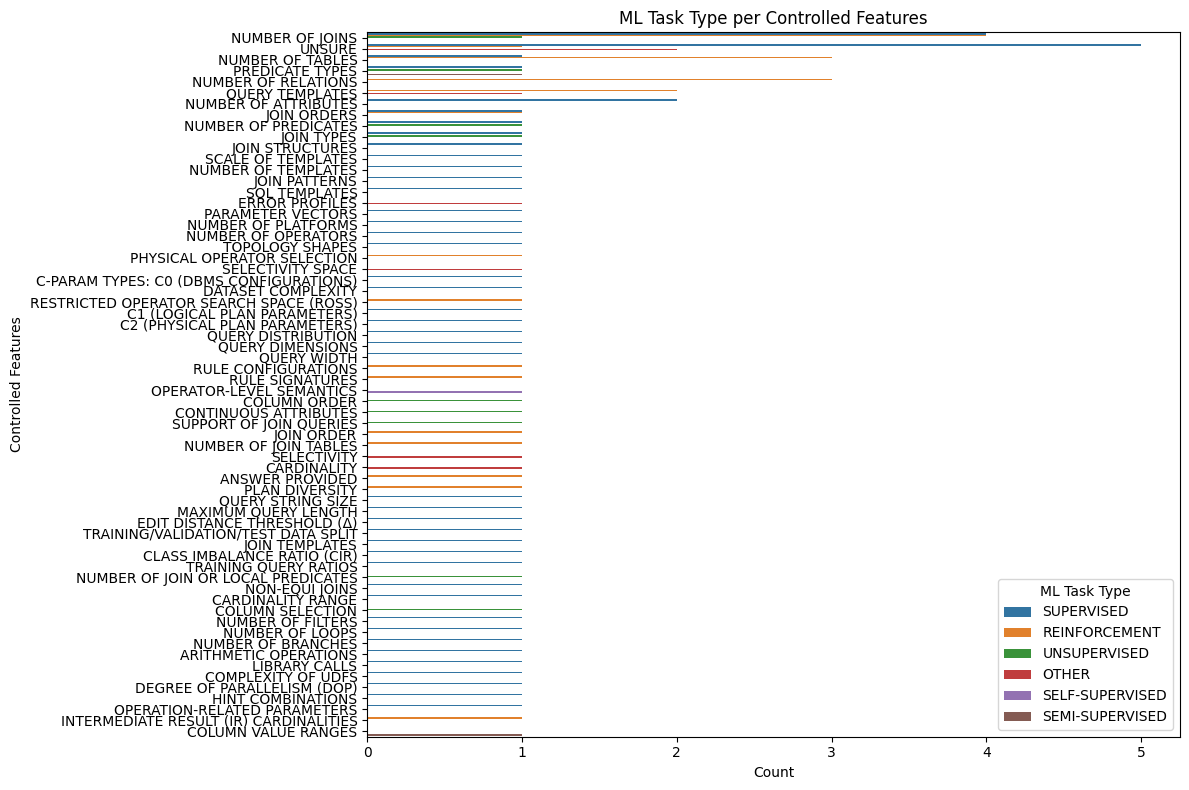

In [42]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Controlled Features",
    col_y="ML Task Type"
)

### Features Controlled During Training Per ML Task Type

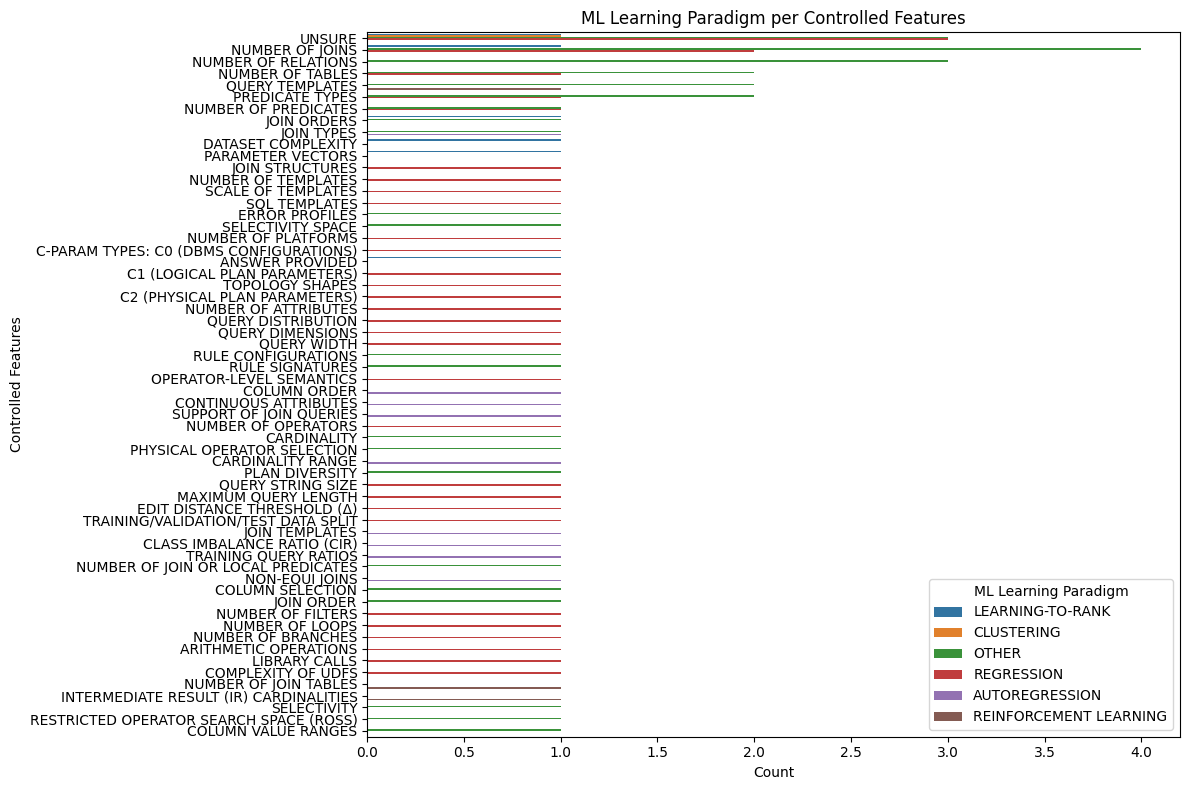

In [43]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Controlled Features",
    col_y="ML Learning Paradigm"
)

### Features Controlled per Model Architecture

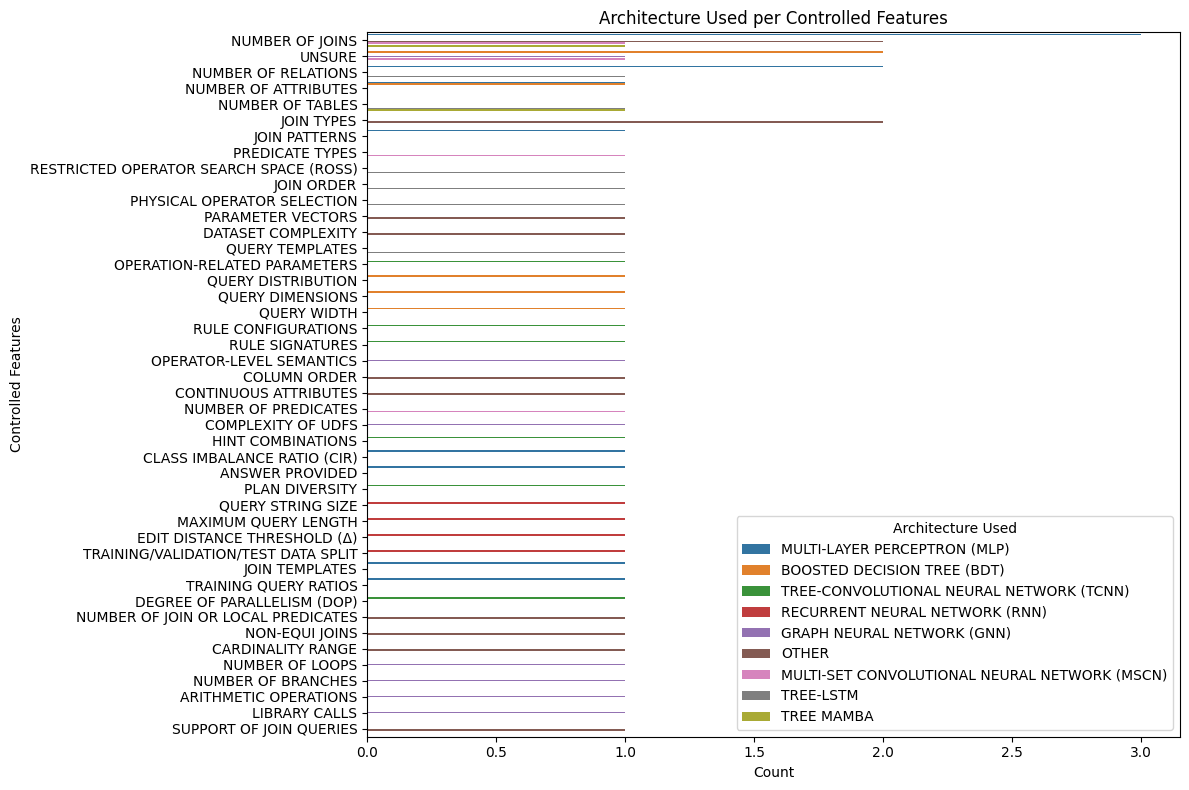

In [44]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Controlled Features",
    col_y="Architecture Used"
)

## Analysis on Machine Learning Task Type

### Distribution of Task Type Over all Papers Over Time

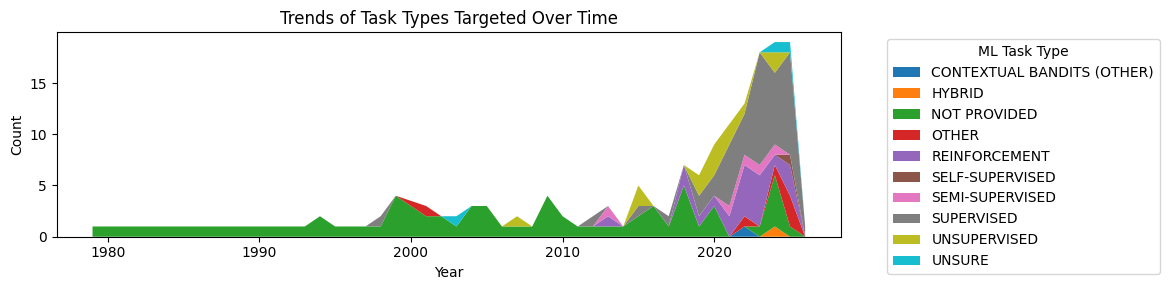

In [45]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('ML Task Type_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('ML Task Type_', '') if x.startswith('ML Task Type_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Task Types Targeted Over Time")
plt.legend(title="ML Task Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Distribution of Task Type Over all Papers

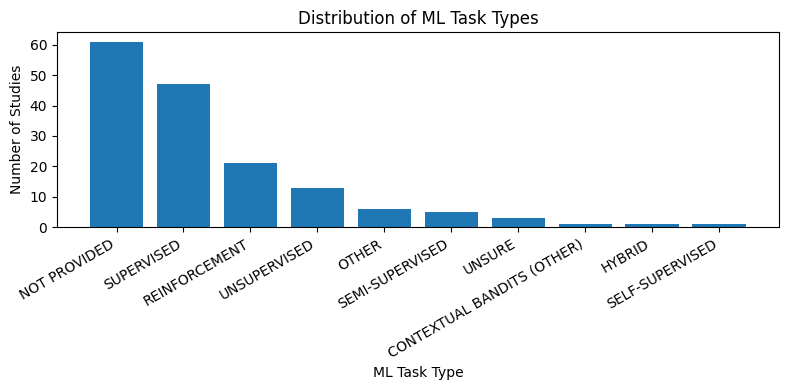

In [46]:
plot_multilabel_distribution(answers_df_encoded, "ML Task Type", "Distribution of ML Task Types")

### Comparing distribution of Learning Pardigm per Task Type

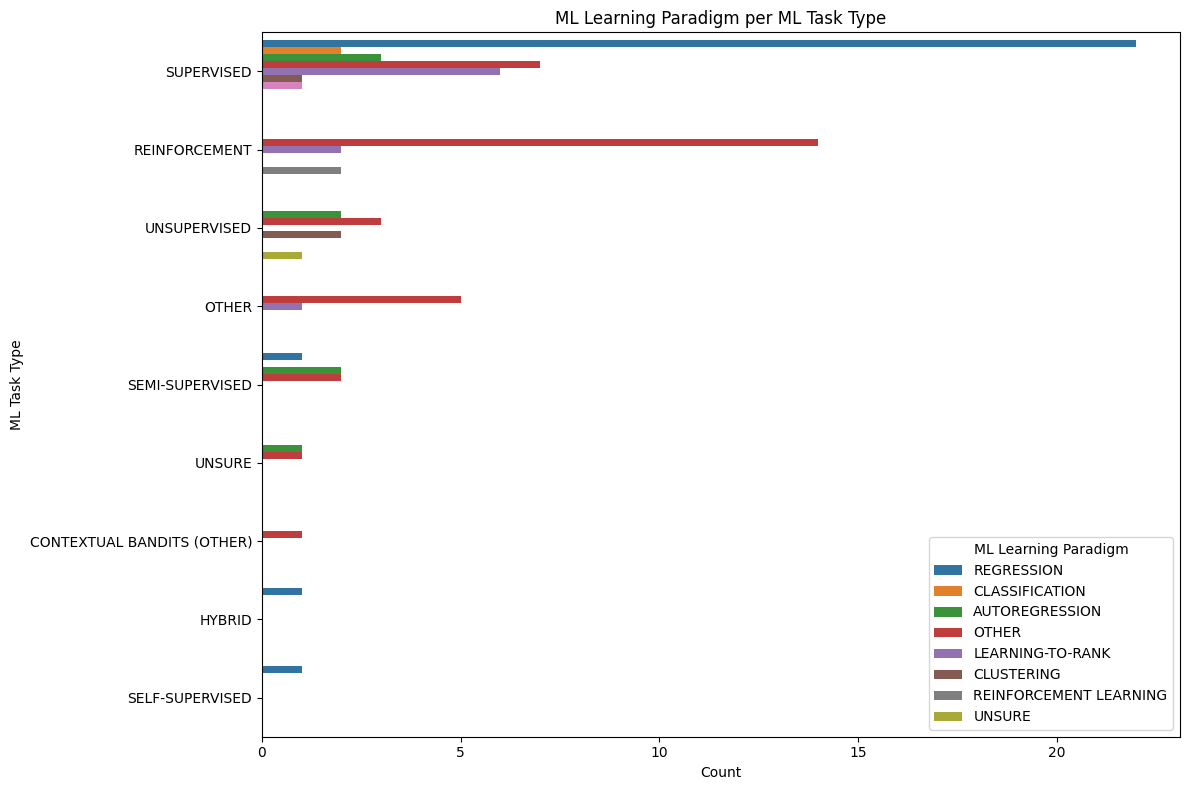

In [47]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="ML Task Type",
    col_y="ML Learning Paradigm"
)

### Data Generation methods per Task Type

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/3258963335.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


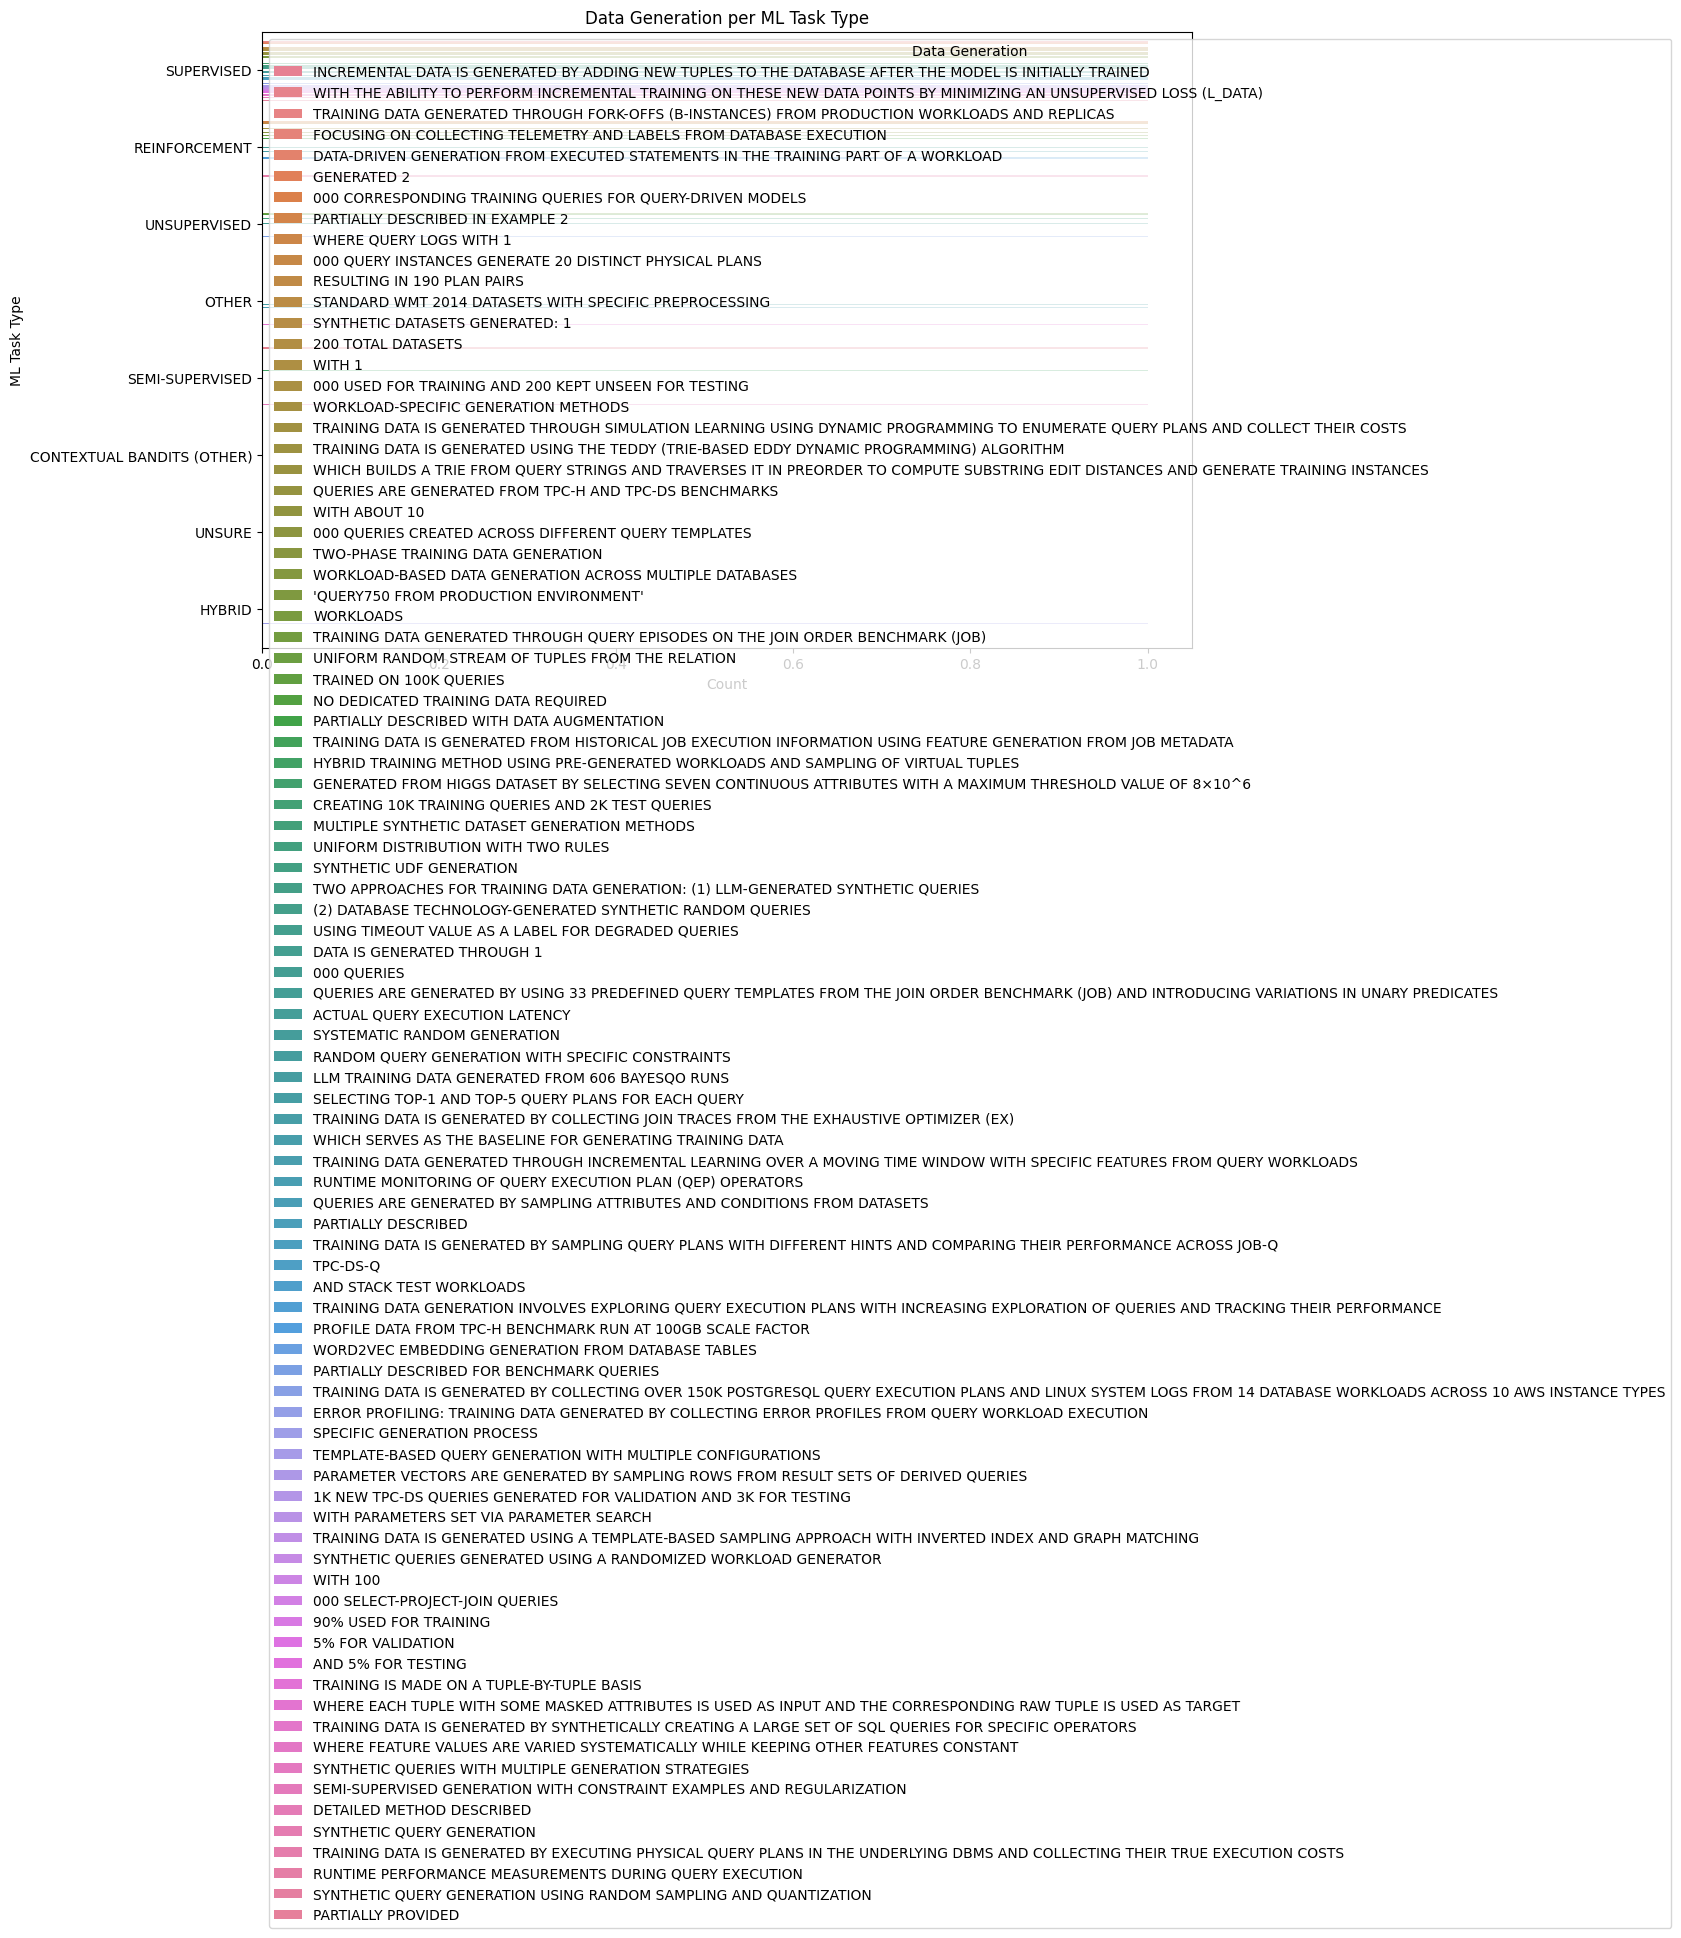

In [48]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="ML Task Type",
    col_y="Data Generation"
)

### Distribution of Encoding Techniques per Task Type

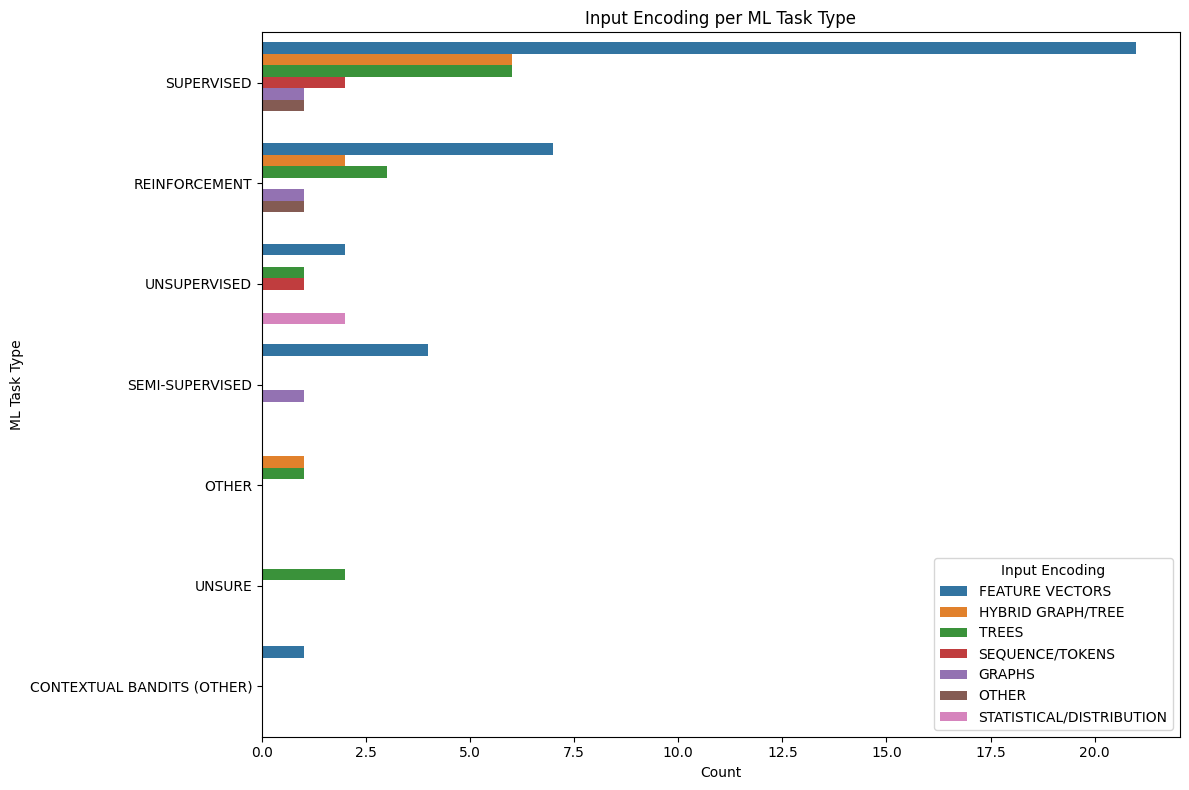

In [49]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="ML Task Type",
    col_y="Input Encoding"
)

###  Uncertainty Evaluation Counts per Task Type

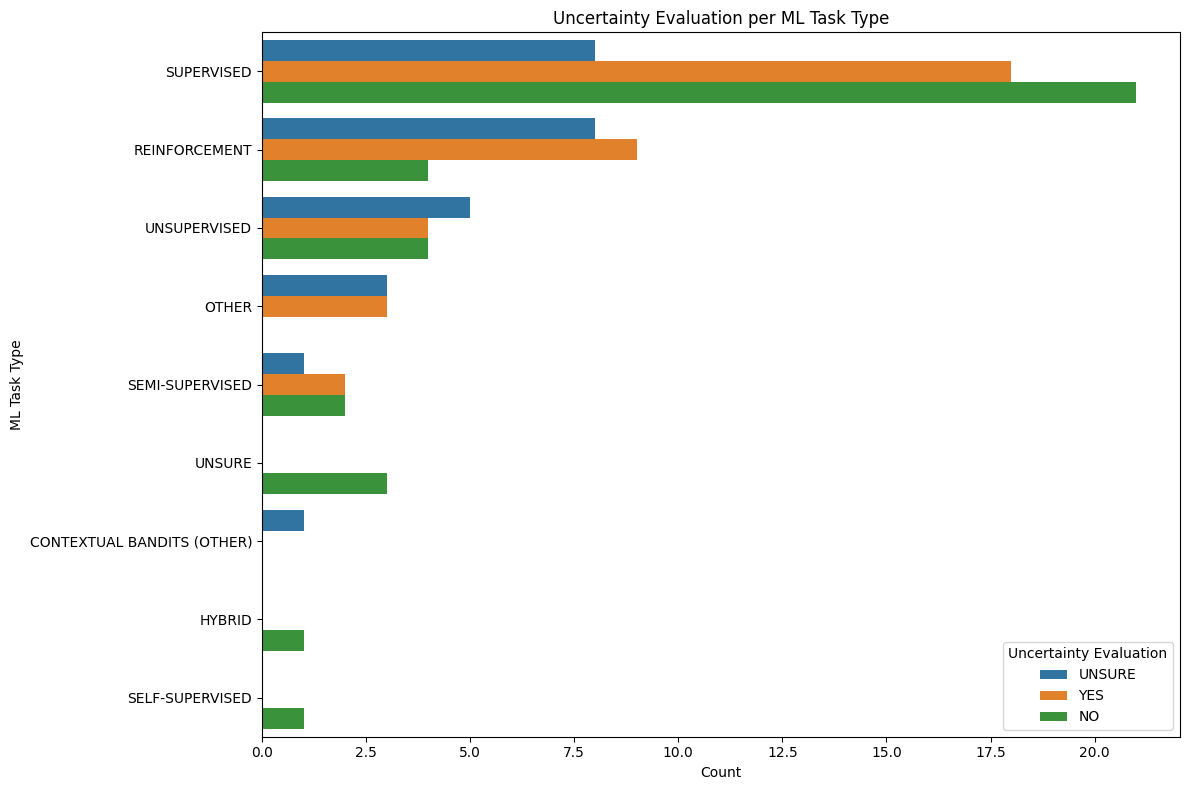

In [50]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="ML Task Type",
    col_y="Uncertainty Evaluation"
)

### Distribution of Techniques that Evaluate Out of Distribution per Task Type

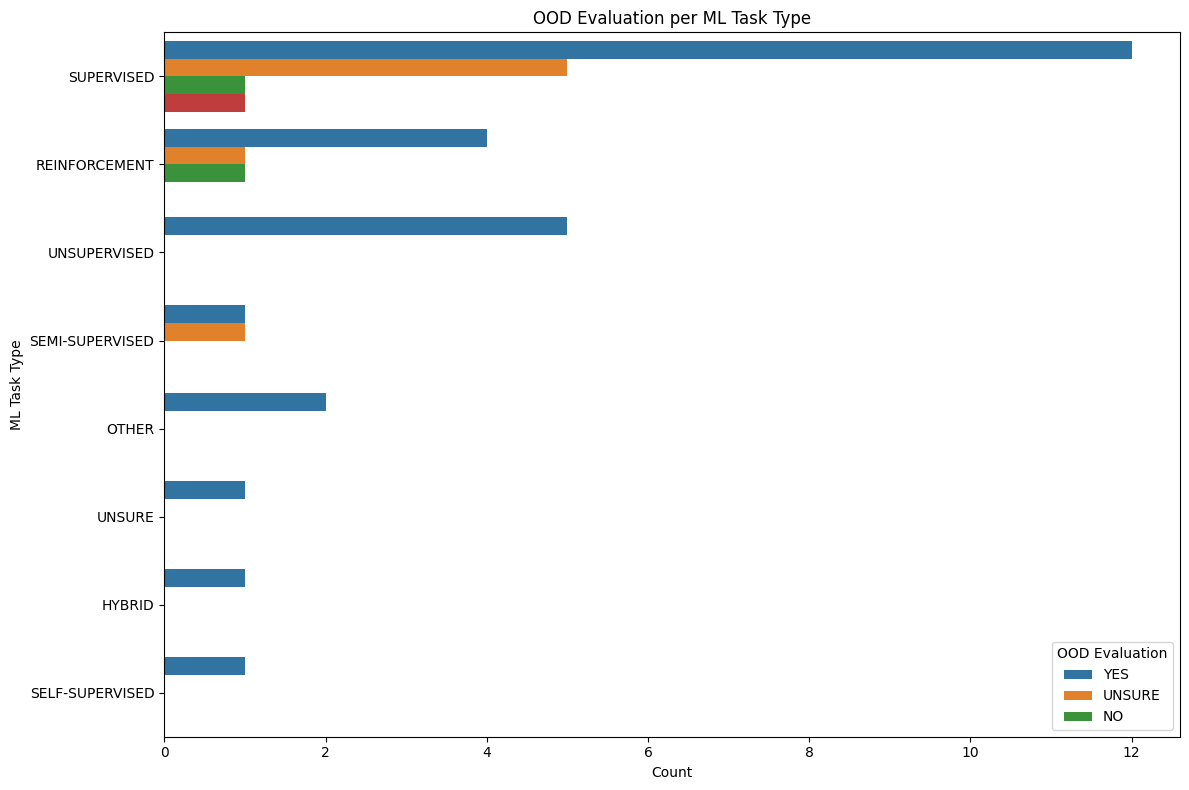

In [51]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="ML Task Type",
    col_y="OOD Evaluation"
)

### Distribution of Architecture per Task Type

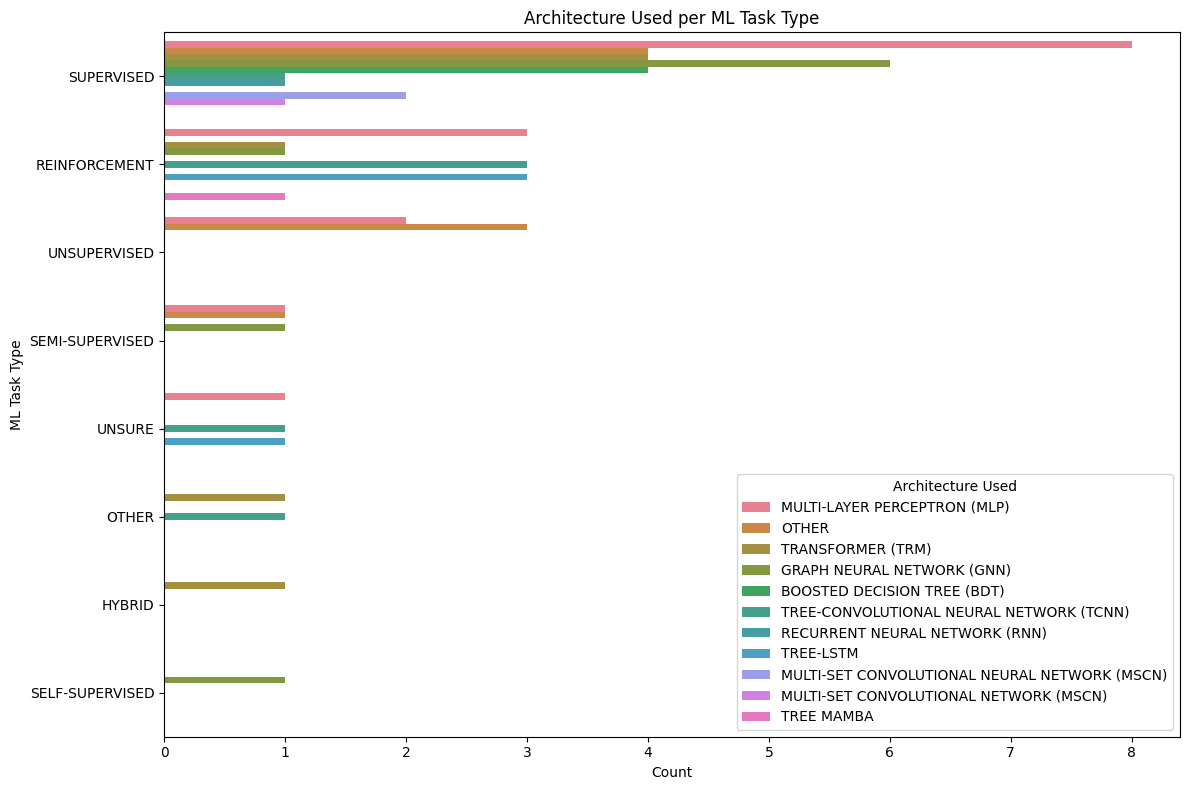

In [52]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="ML Task Type",
    col_y="Architecture Used"
)

## Analysis on Learning Paradigm

### Distribution of Learning Paradigm Over Time

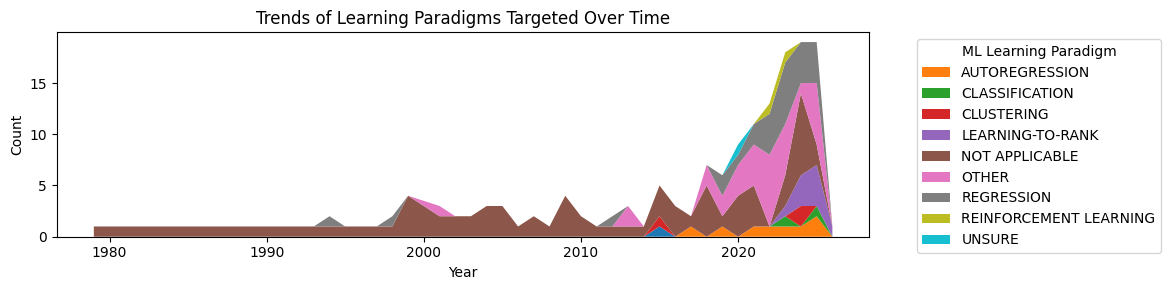

In [53]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('ML Learning Paradigm_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('ML Learning Paradigm_', '') if x.startswith('ML Learning Paradigm_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Learning Paradigms Targeted Over Time")
plt.legend(title="ML Learning Paradigm", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Distribution of Learning Paradigm Over all Papers

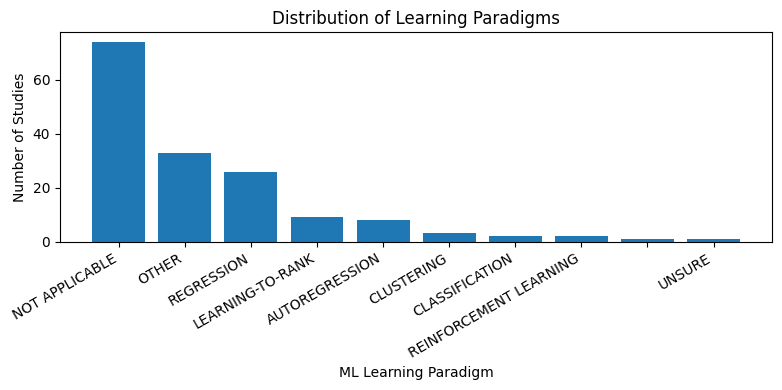

In [54]:
plot_multilabel_distribution(answers_df_encoded, "ML Learning Paradigm", "Distribution of Learning Paradigms")

### All Data Generation Methods per Machine Learning Paradigm

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/3258963335.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


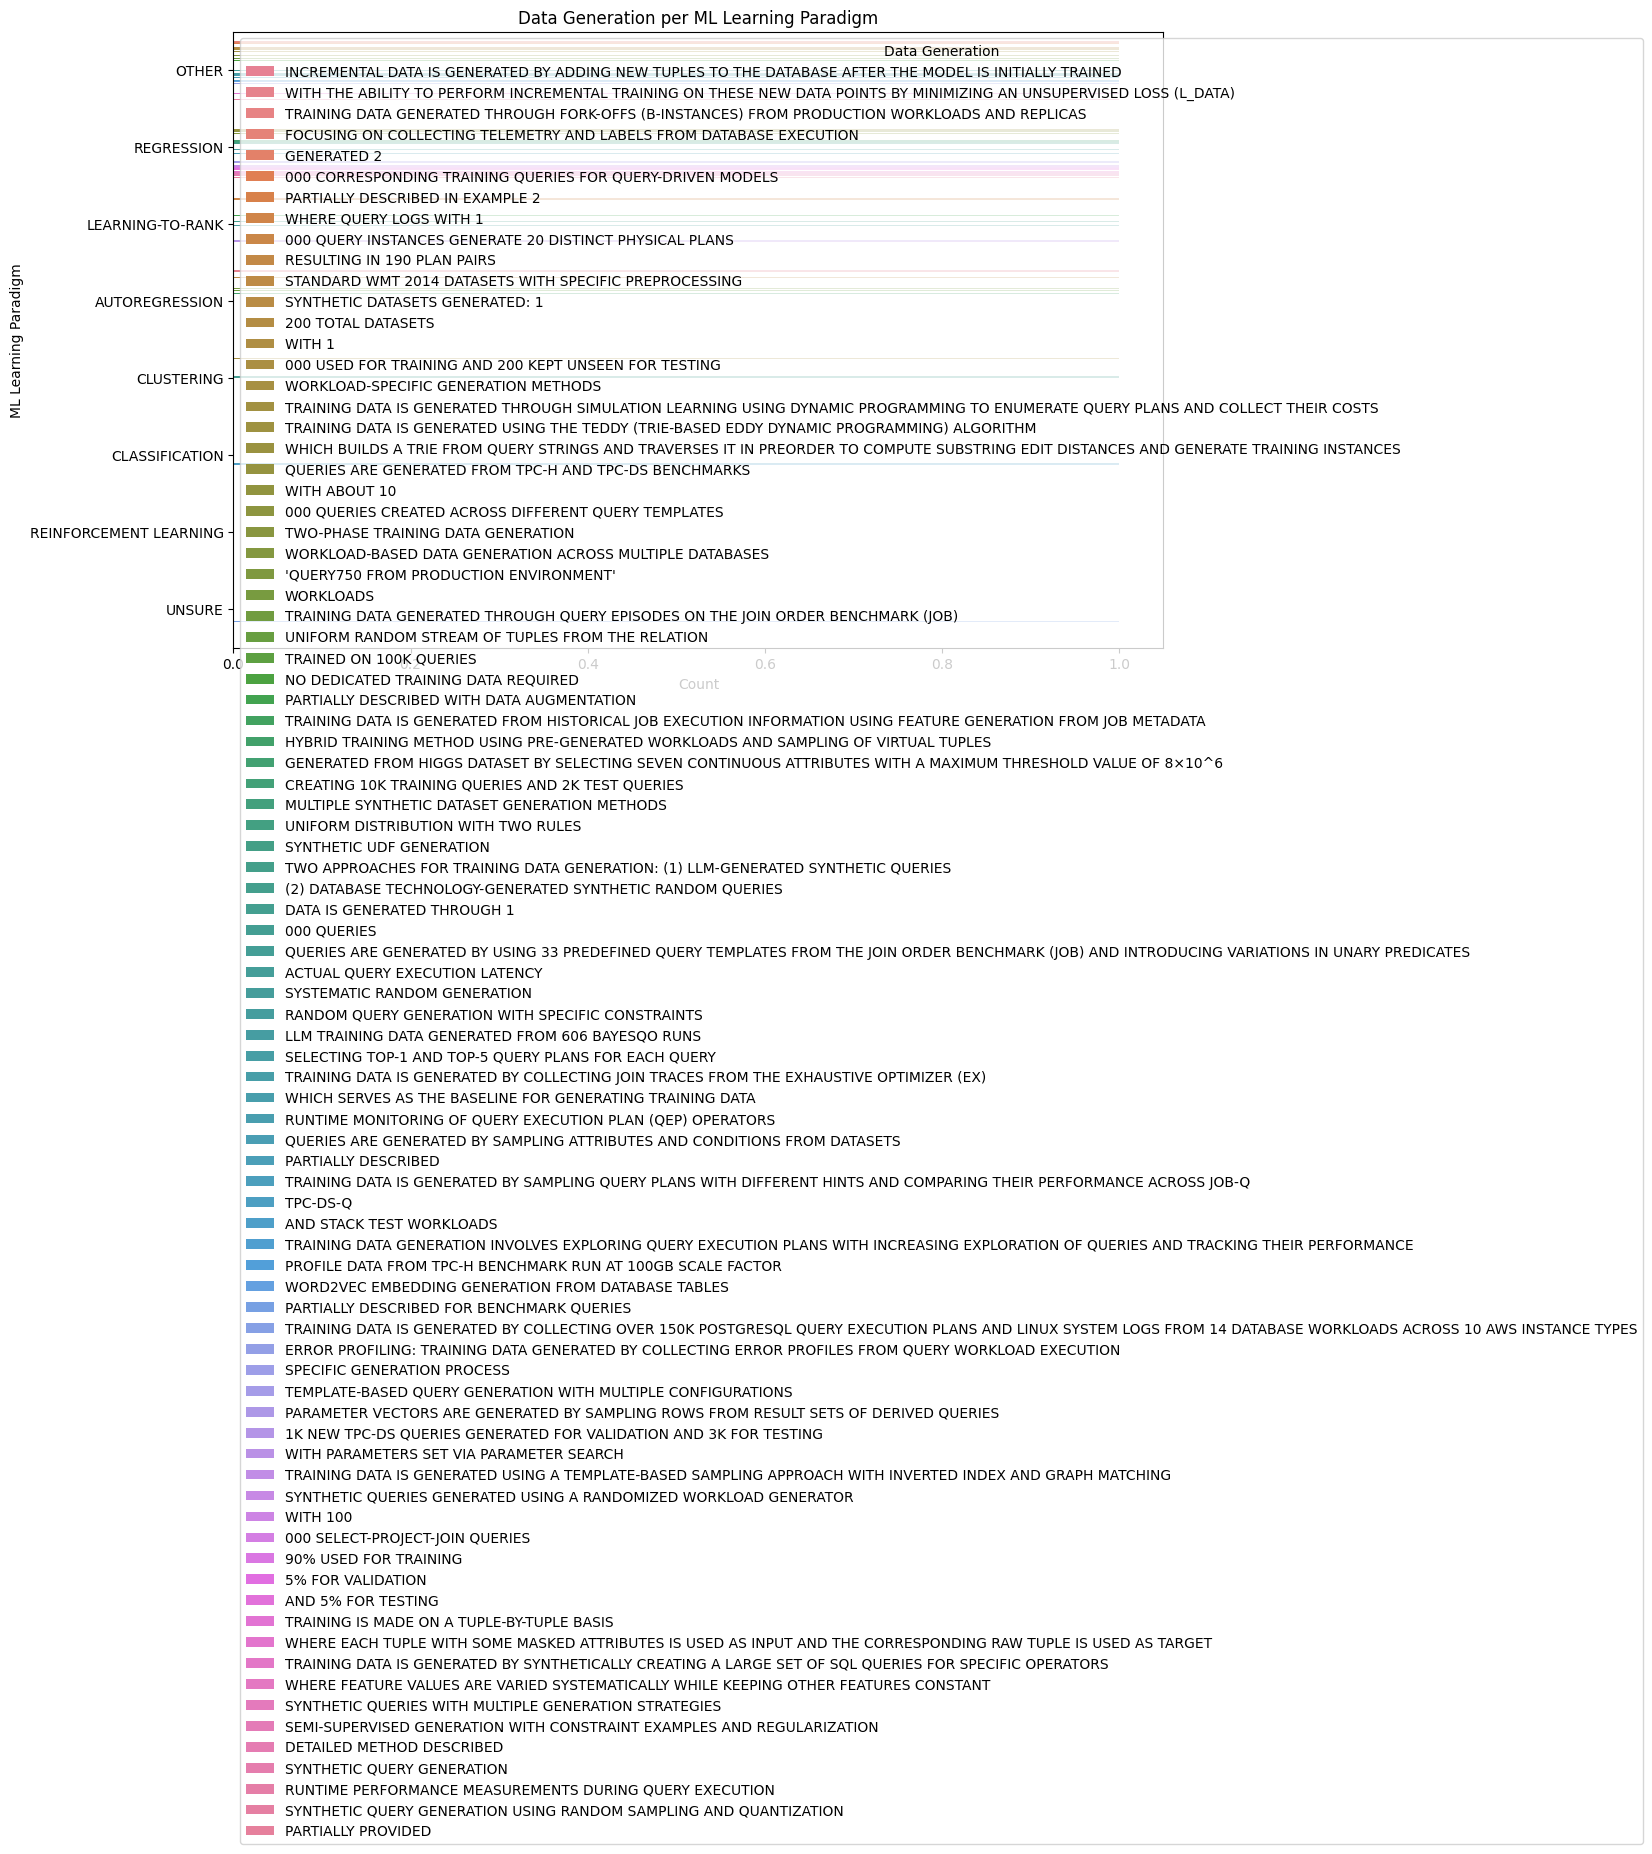

In [55]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="ML Learning Paradigm",
    col_y="Data Generation"
)


### All Input Encoding Methods per Machine Learning Paradigm

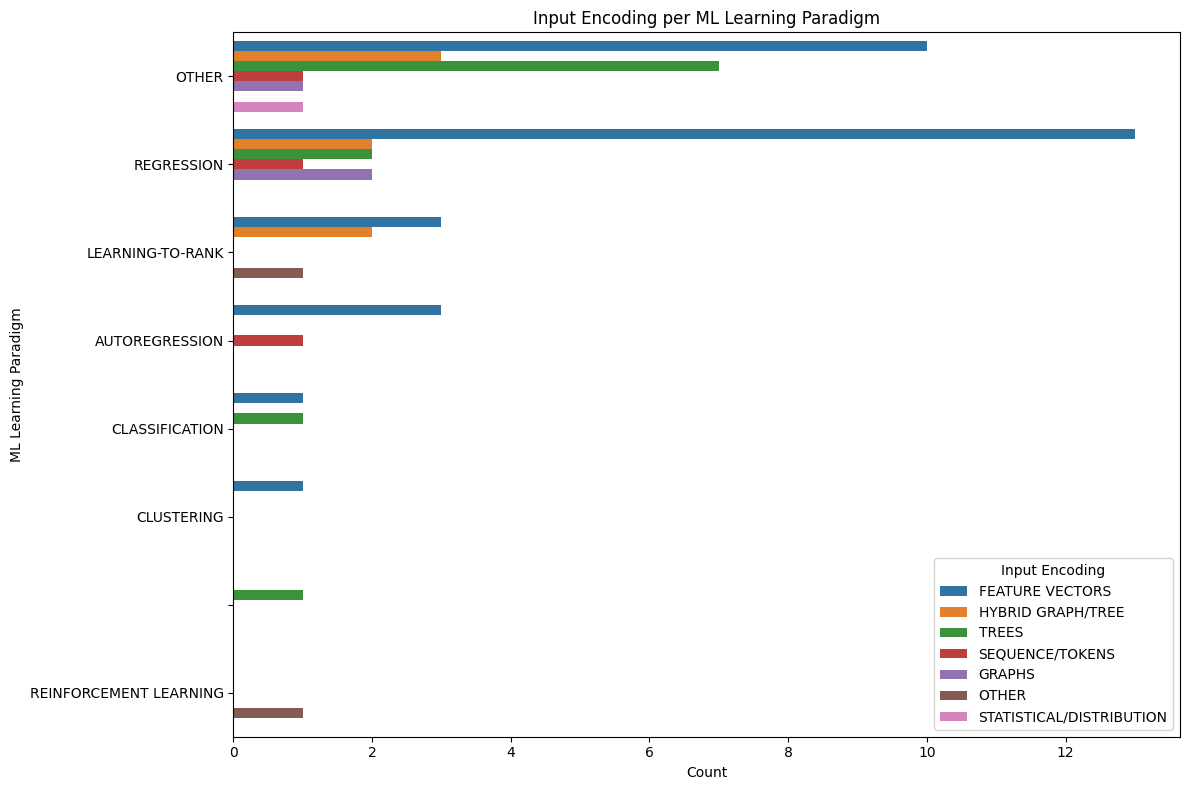

In [56]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="ML Learning Paradigm",
    col_y="Input Encoding"
)


## Analysis on Training Data Generation

### Distribution of Training Data Generation Methods Over Time

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/2024216035.py:27: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


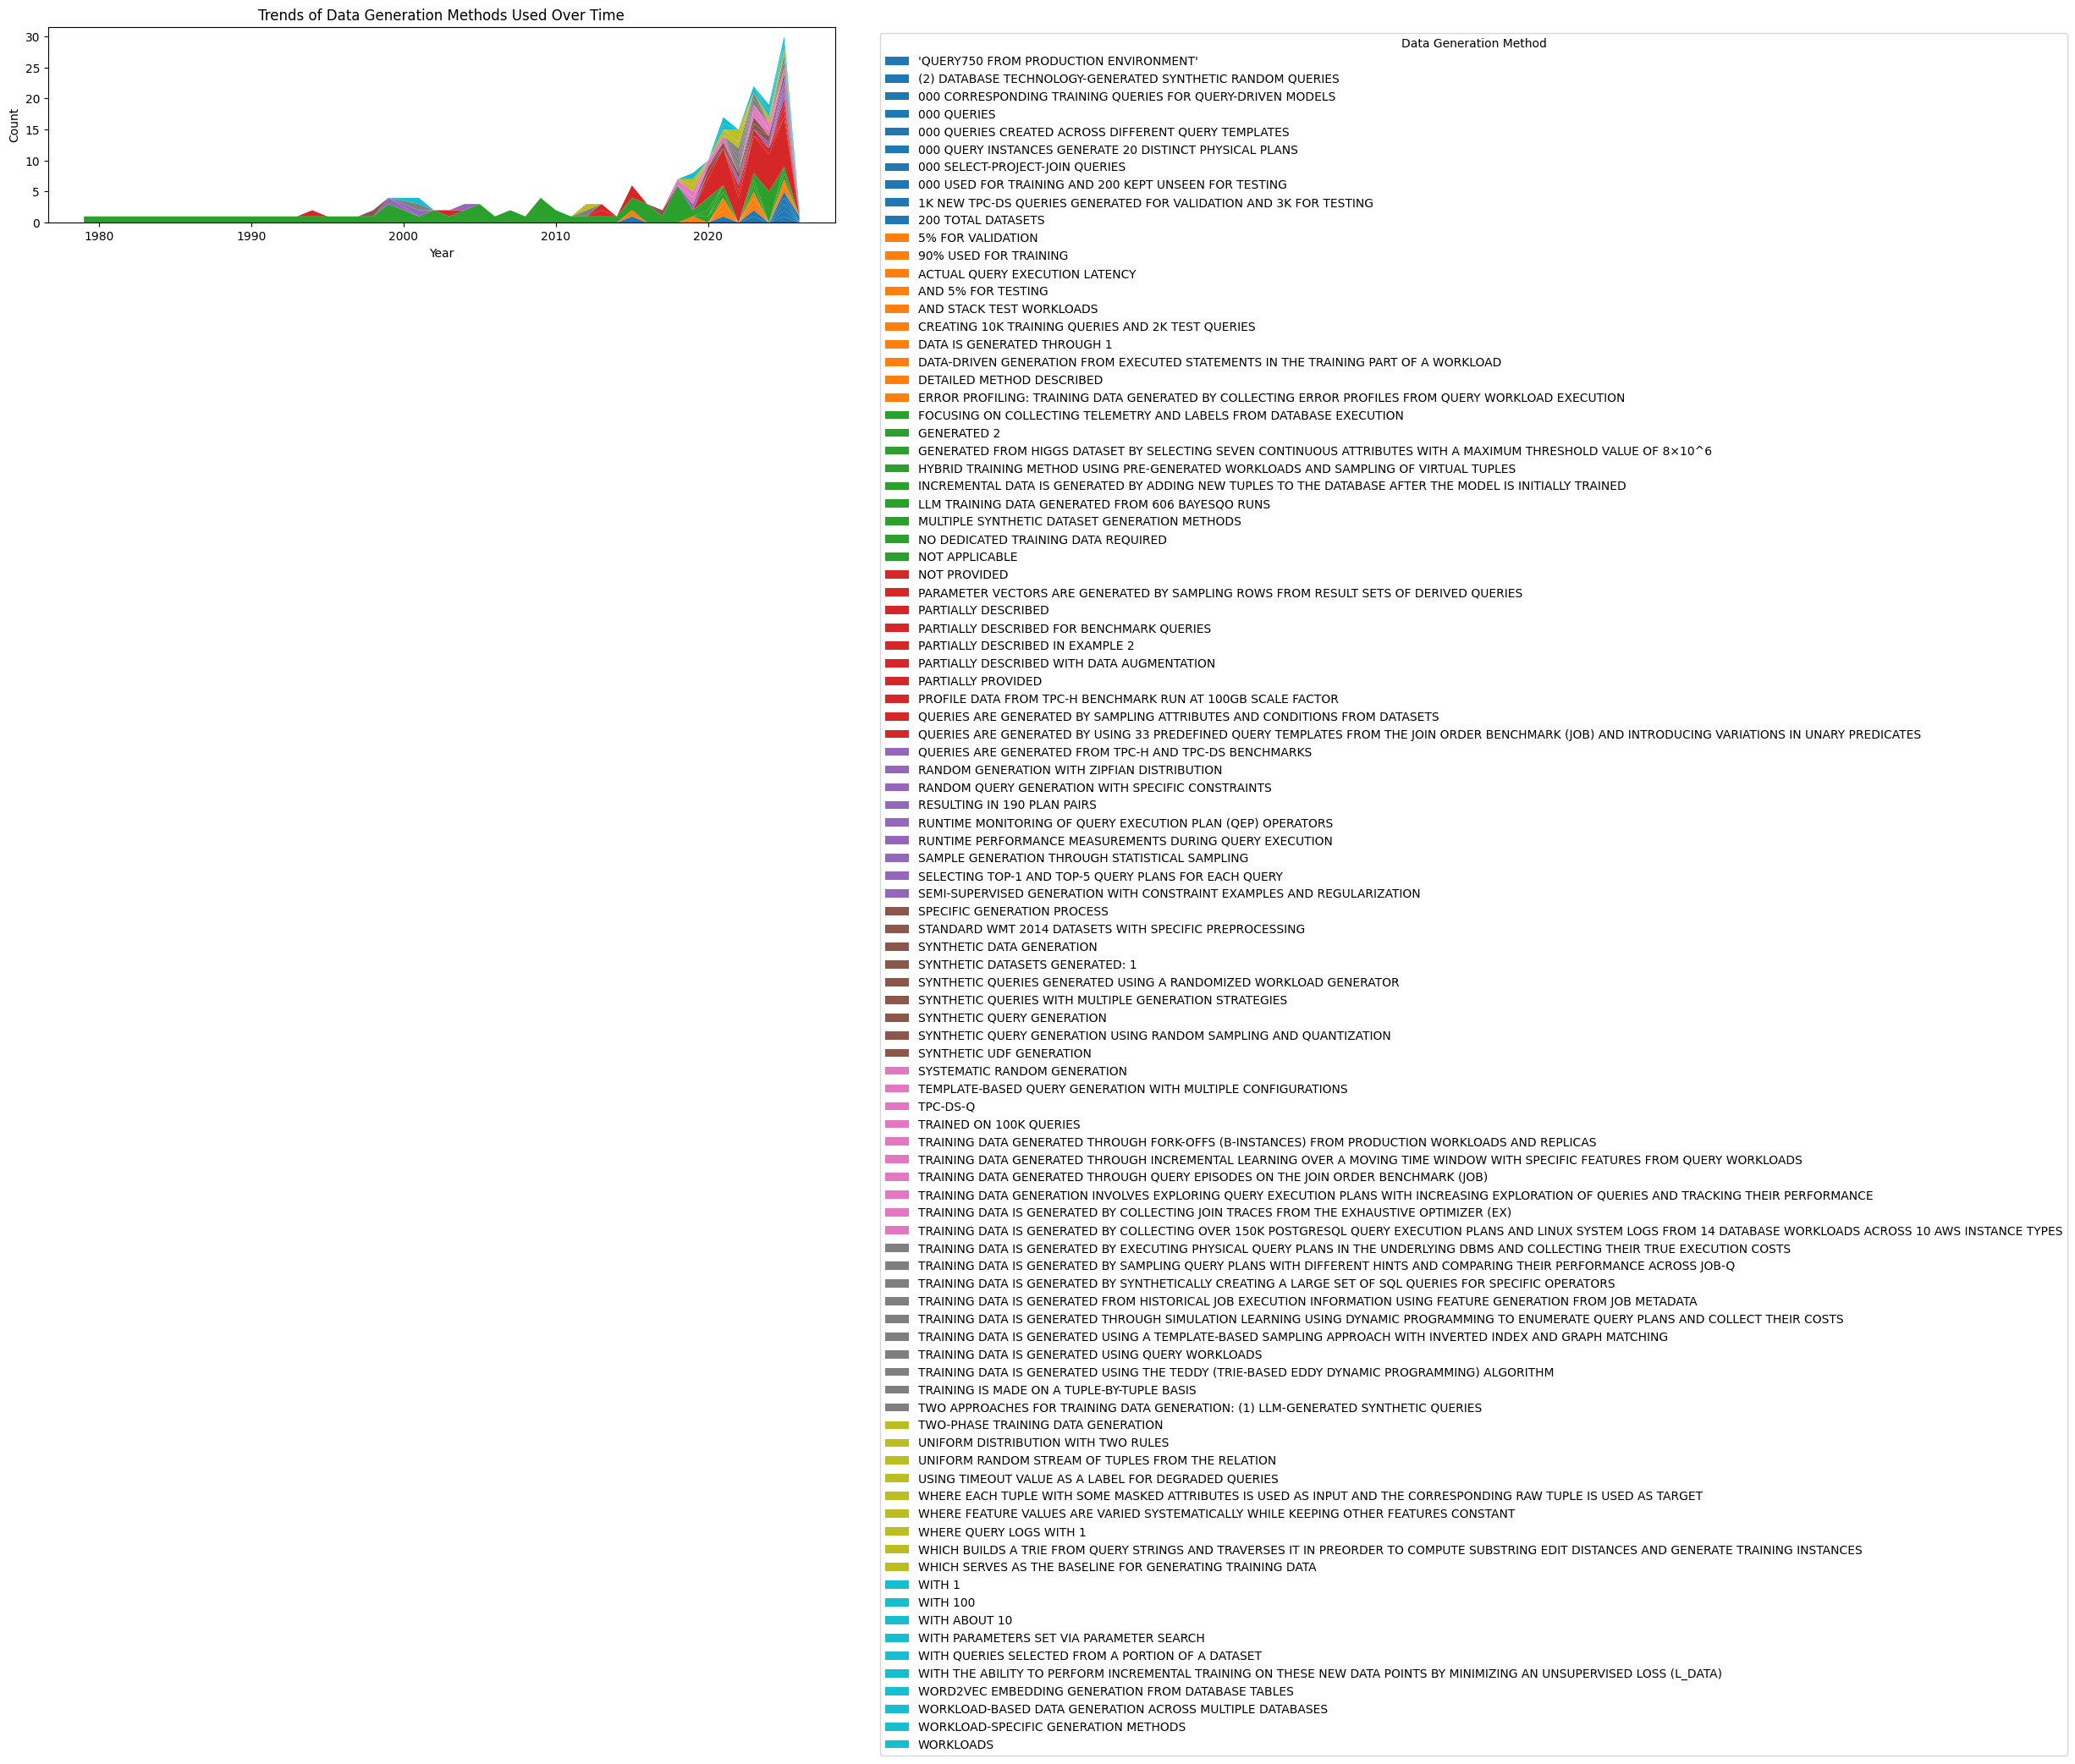

In [57]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Data Generation_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Data Generation_', '') if x.startswith('Data Generation_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Data Generation Methods Used Over Time")
plt.legend(title="Data Generation Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Training Data Generation Methods

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/3105094420.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


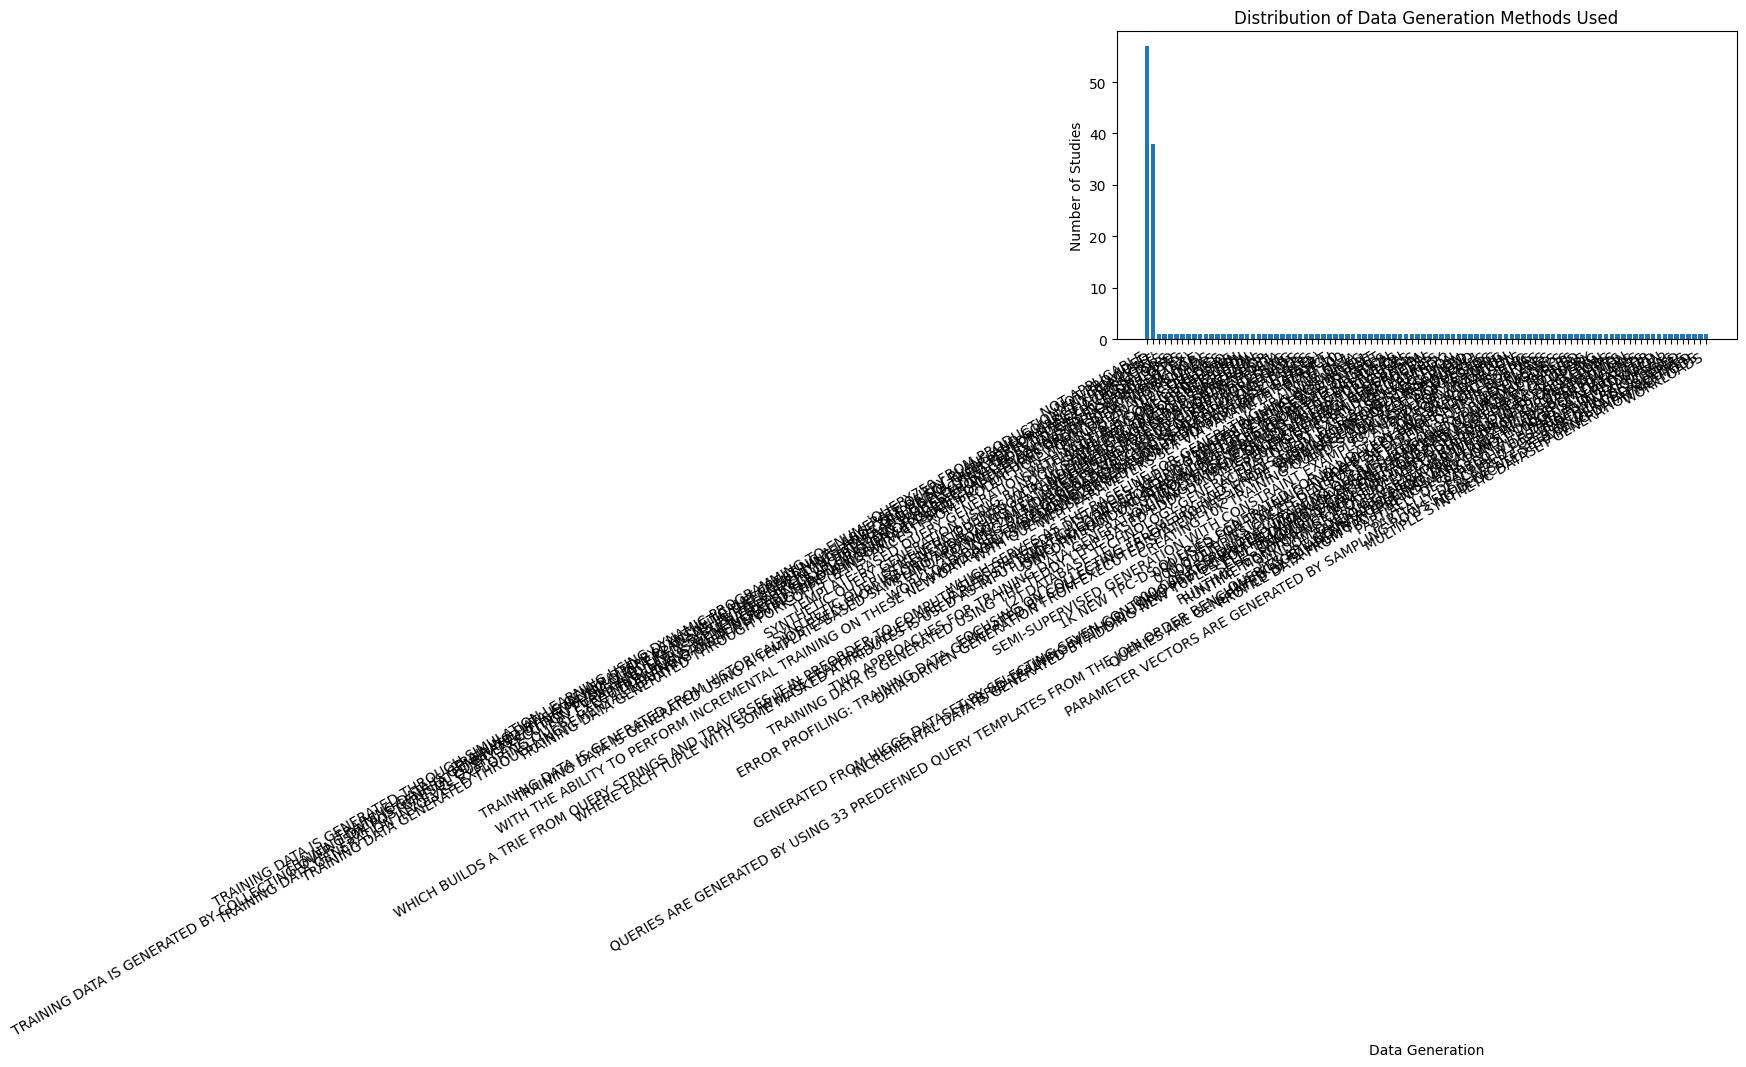

In [58]:
plot_multilabel_distribution(answers_df_encoded, "Data Generation", "Distribution of Data Generation Methods Used")

### Comparing Data Generation Methods per Input Encoding Method

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/3258963335.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


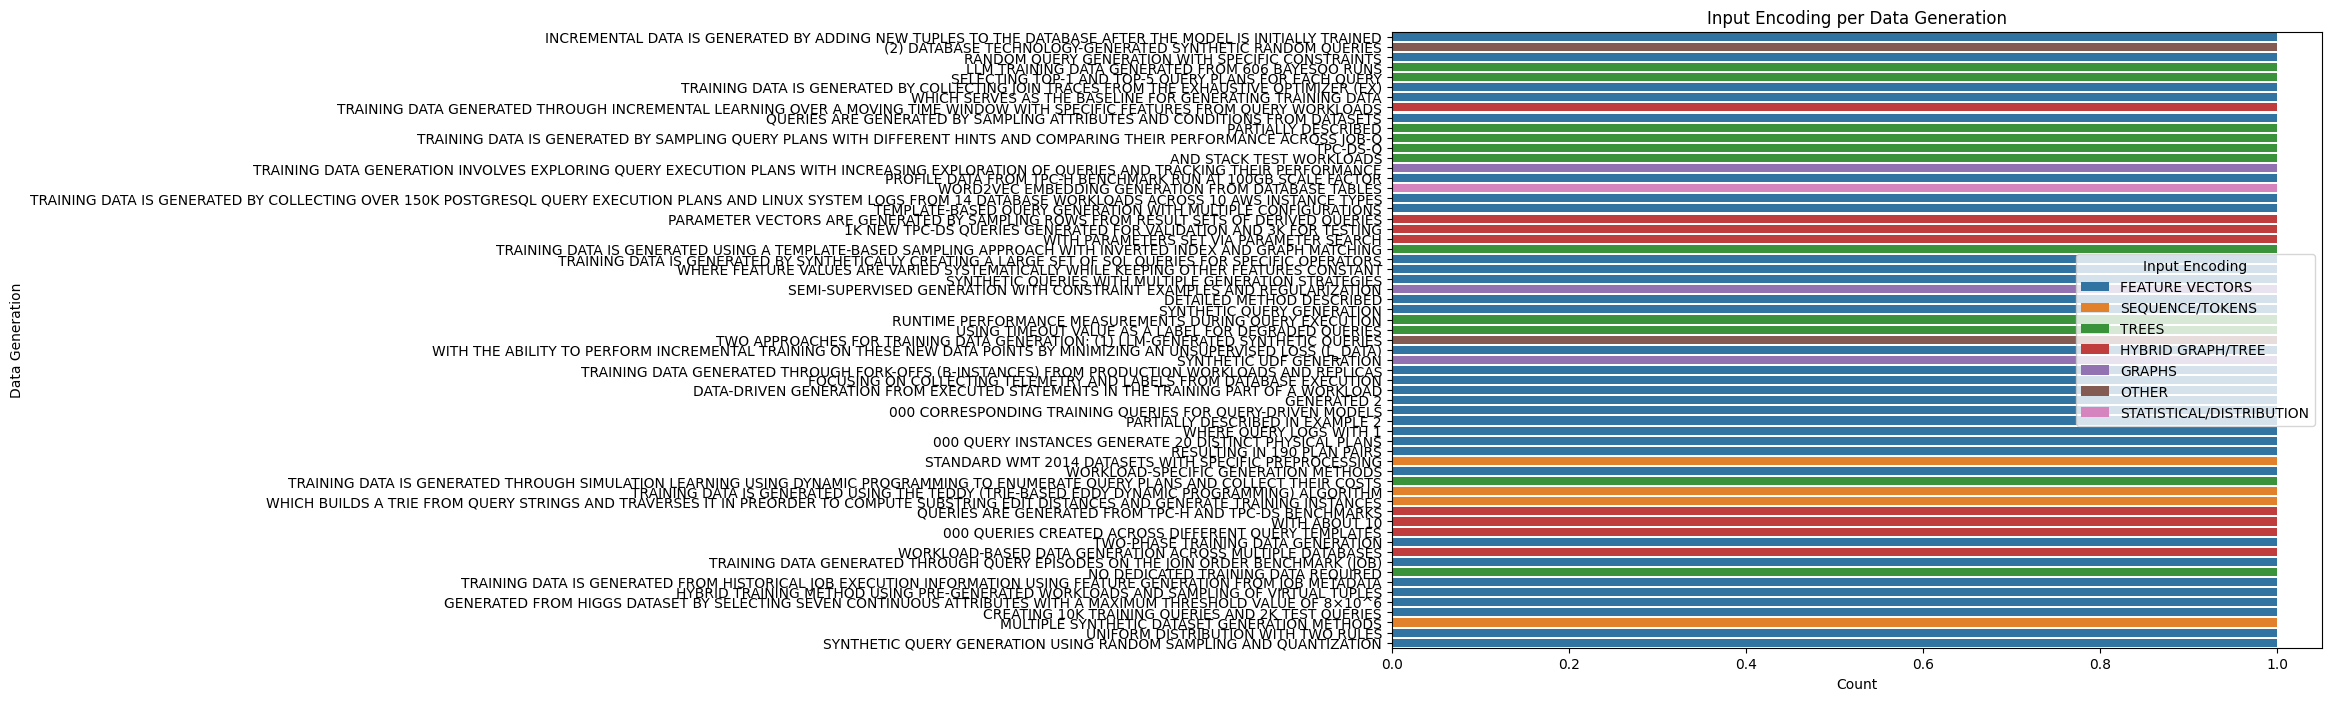

In [59]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Data Generation",
    col_y="Input Encoding"
)

### Data Generation Methods that have Uncertainty Evaluation

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/3258963335.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


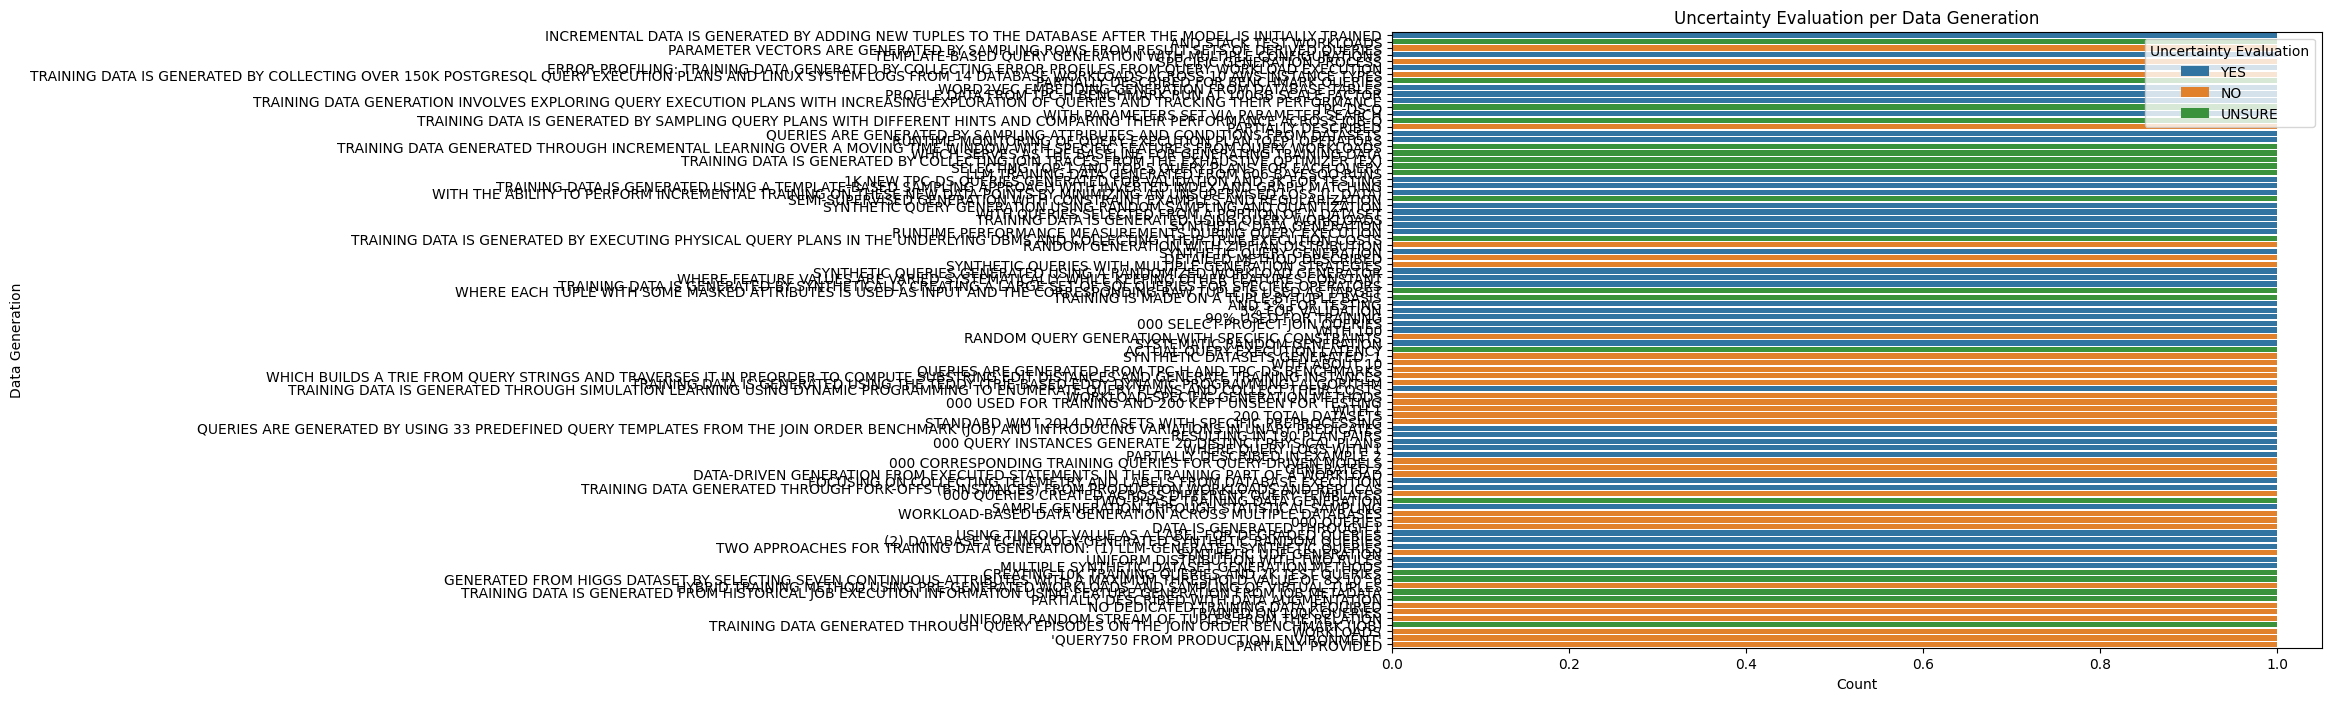

In [60]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Data Generation",
    col_y="Uncertainty Evaluation"
)

### Data Generation Methods that have OOD Evaluation

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/3258963335.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


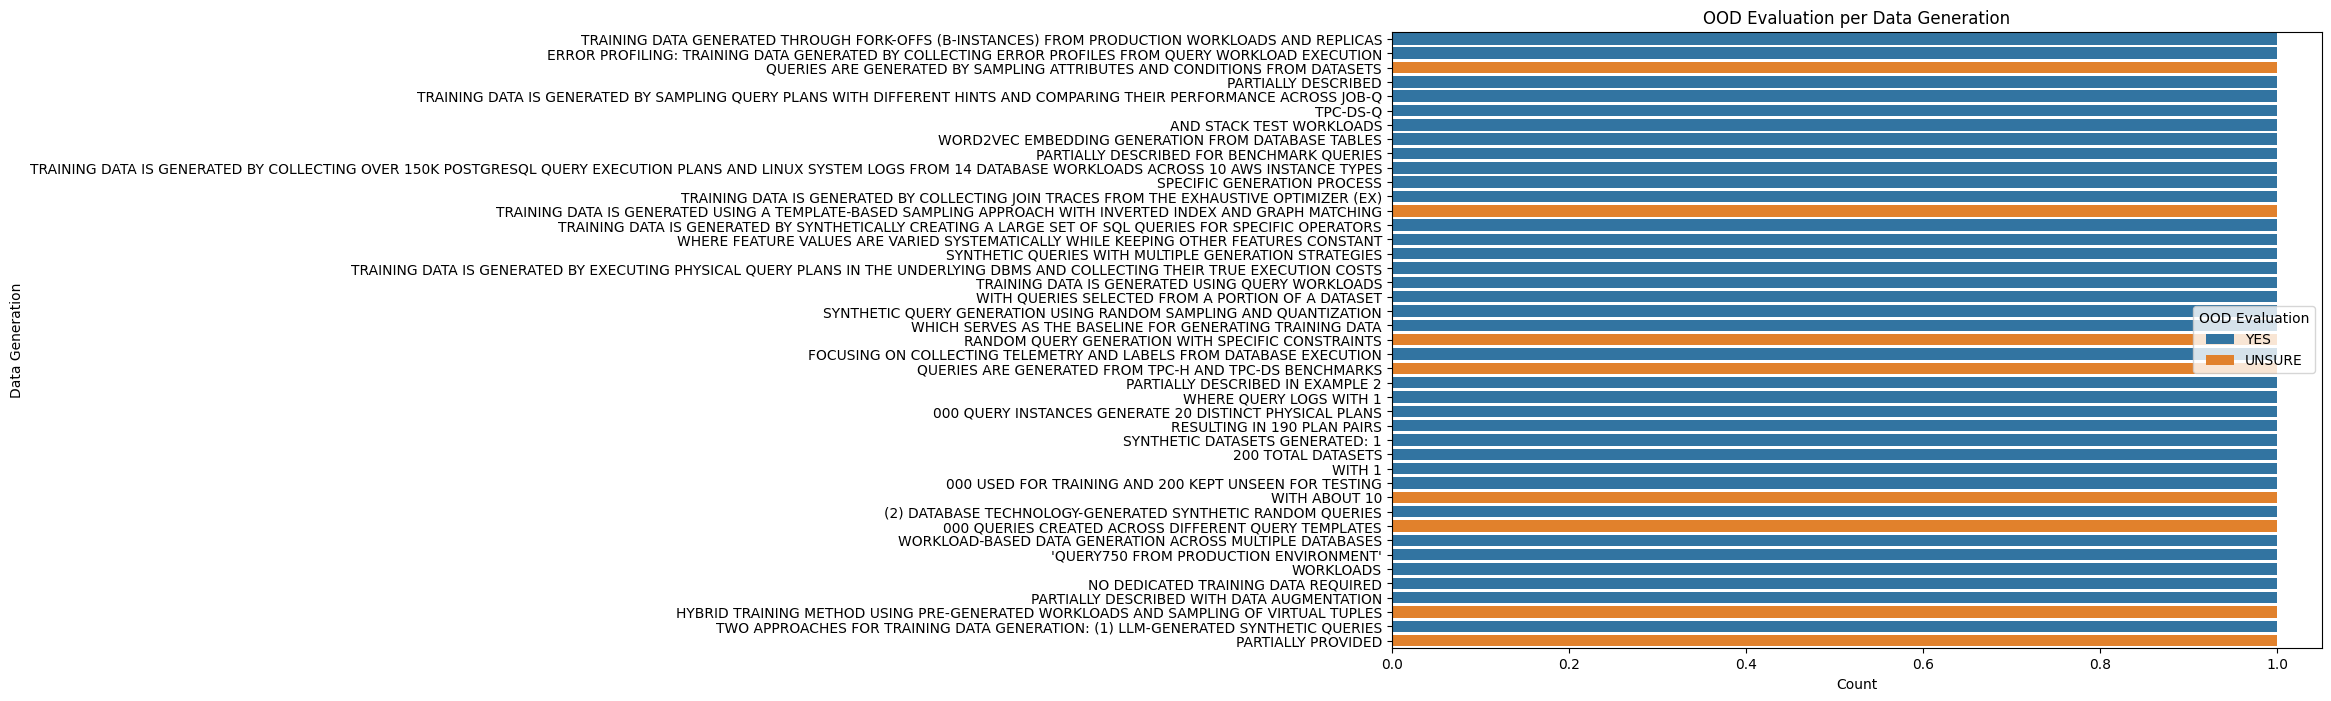

In [61]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Data Generation",
    col_y="OOD Evaluation"
)

## Analysis on Input Encoding

### Distribution of Task Type Over all Papers

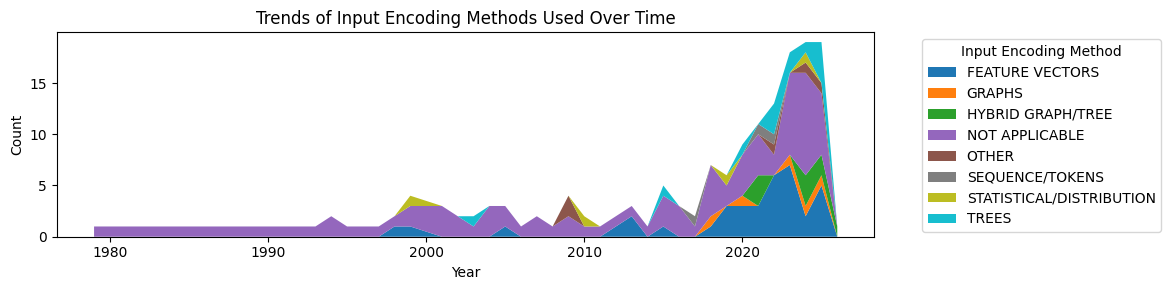

In [62]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Input Encoding_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Input Encoding_', '') if x.startswith('Input Encoding_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Input Encoding Methods Used Over Time")
plt.legend(title="Input Encoding Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Distribution of Task Type Over all Papers Over Time

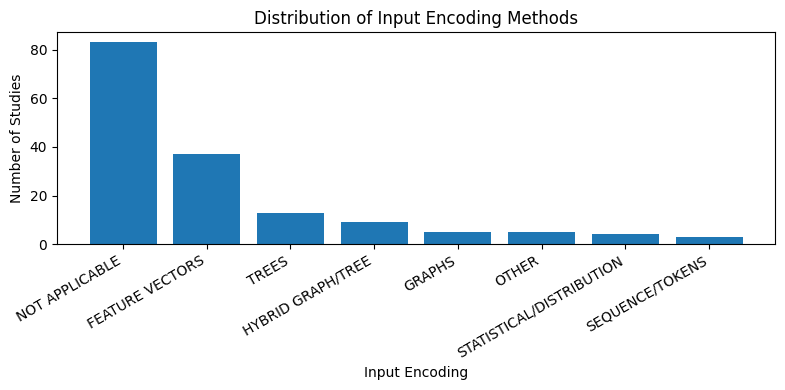

In [63]:
plot_multilabel_distribution(answers_df_encoded, "Input Encoding", "Distribution of Input Encoding Methods")

### Uncertainty Evaluation Counts per Input Encoding

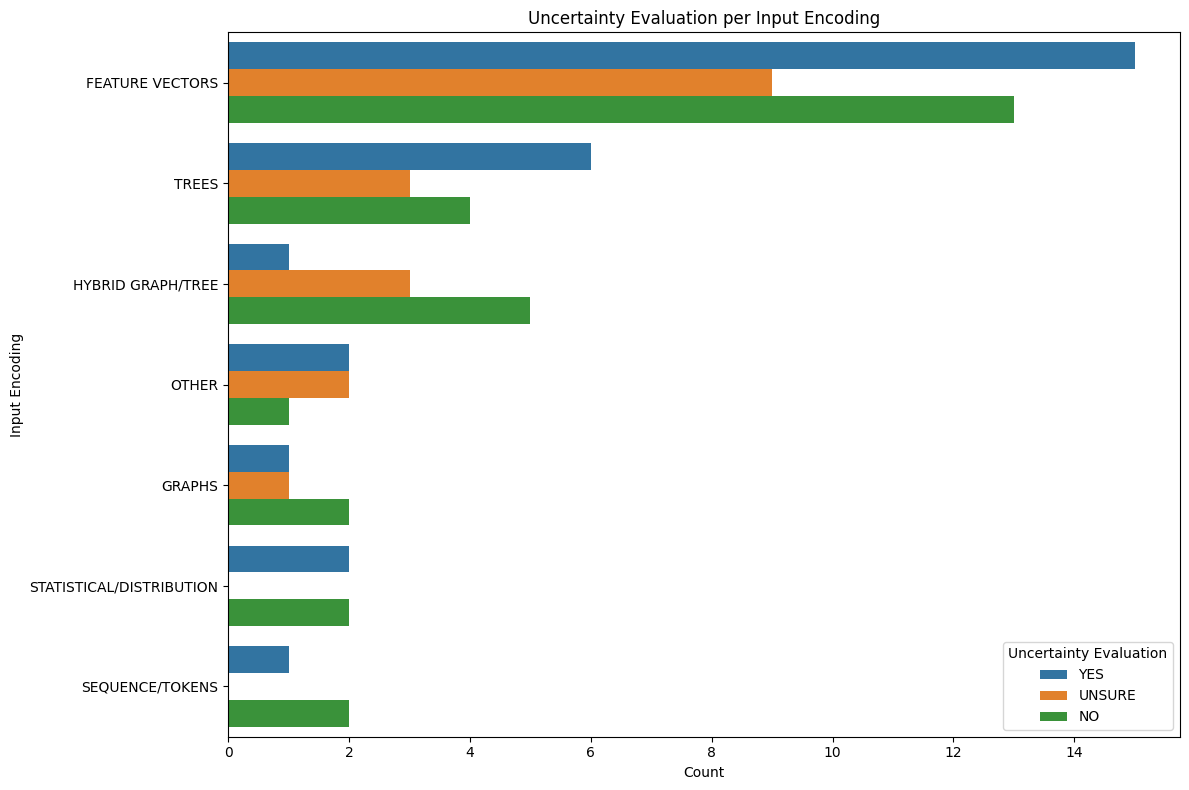

In [64]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Input Encoding",
    col_y="Uncertainty Evaluation"
)

### Out of Distribution Evaluation Counts per Input Encoding

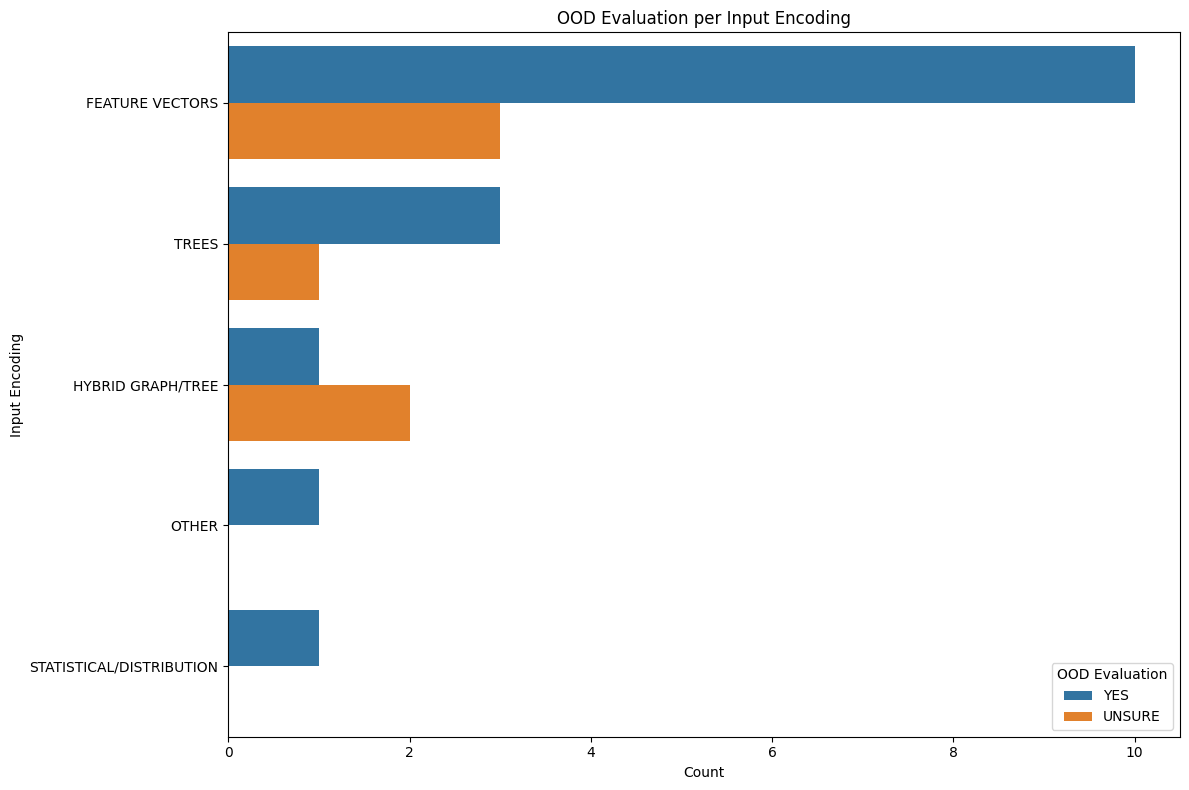

In [65]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Input Encoding",
    col_y="OOD Evaluation"
)

### Input Encoding Methods used per Model Architecture

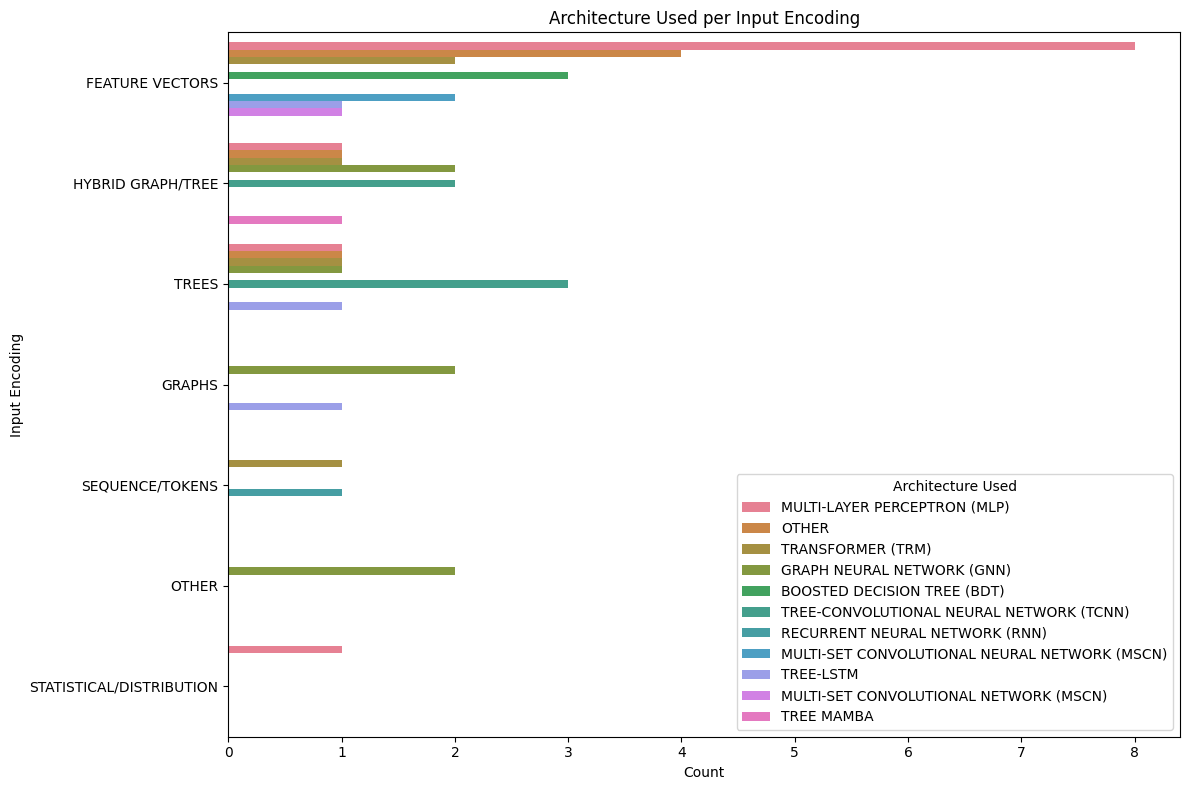

In [66]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Input Encoding",
    col_y="Architecture Used"
)

## Analysis on Uncertainty Evaluation

### Bar Plot of papers that have Uncertainty Evaluations

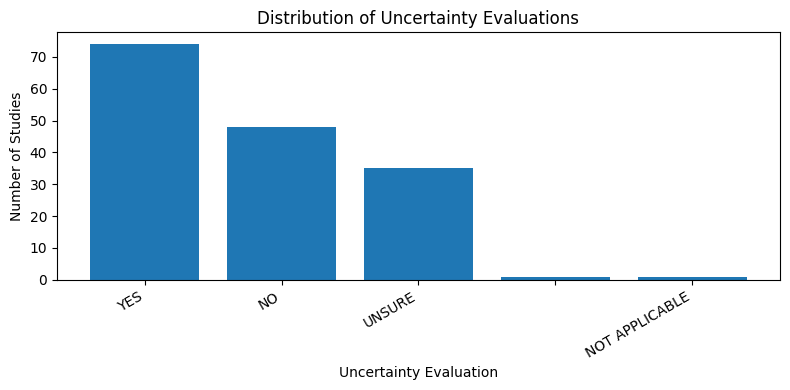

In [67]:
plot_multilabel_distribution(answers_df_encoded, "Uncertainty Evaluation", "Distribution of Uncertainty Evaluations")

### Uncertainty Evaluations that also account Out of Distribution Evaluations

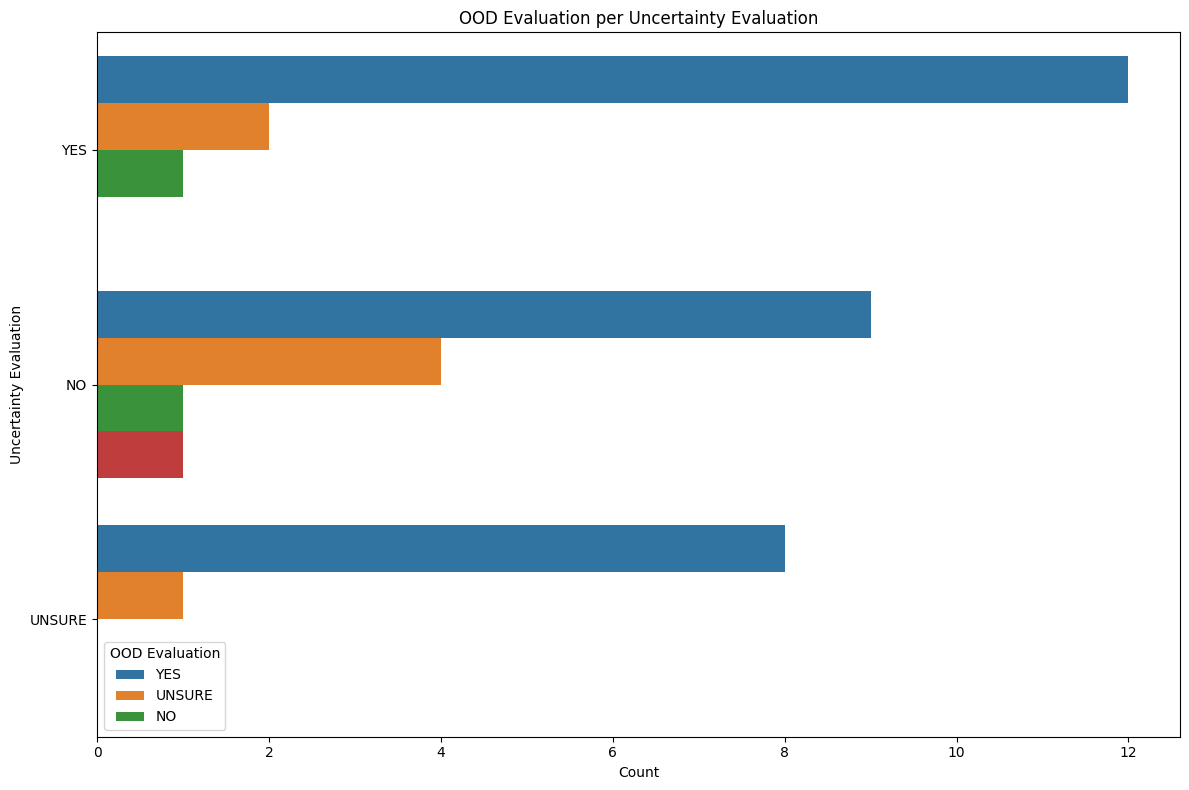

In [68]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Uncertainty Evaluation",
    col_y="OOD Evaluation"
)

### Uncertainty Evaluation Counts per Model Architecture

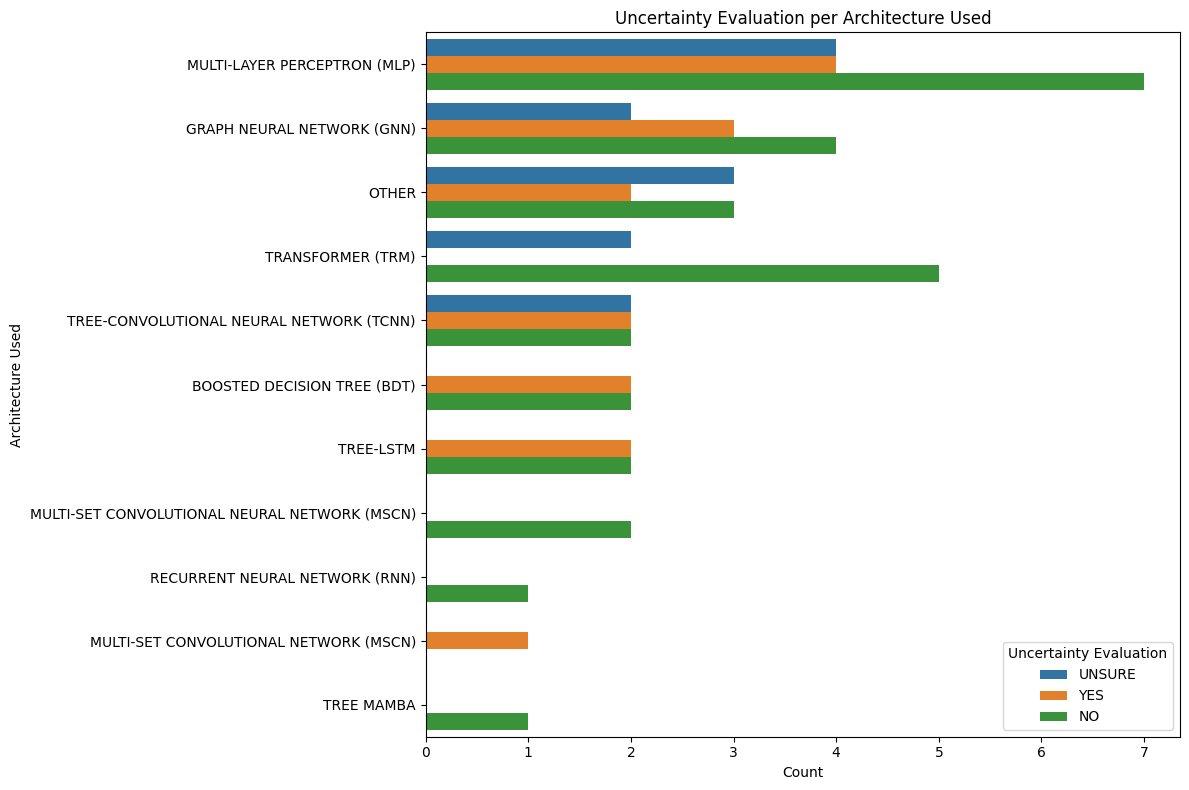

In [69]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Architecture Used",
    col_y="Uncertainty Evaluation"
)

## Analysis on Out of Distribution Evaluation

### Bar Plot of Training Data Generation Methods

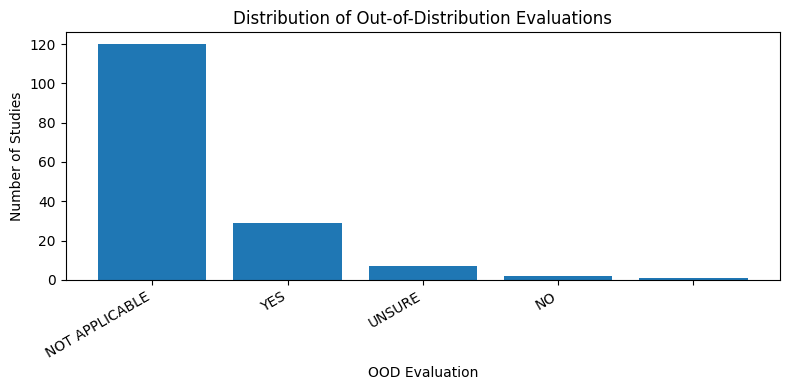

In [70]:
plot_multilabel_distribution(answers_df_encoded, "OOD Evaluation", "Distribution of Out-of-Distribution Evaluations")

## Analysis on Model Architecture

### Distribution of Model Architectures Used Over Time

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_14287/211451943.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("hsv", n)


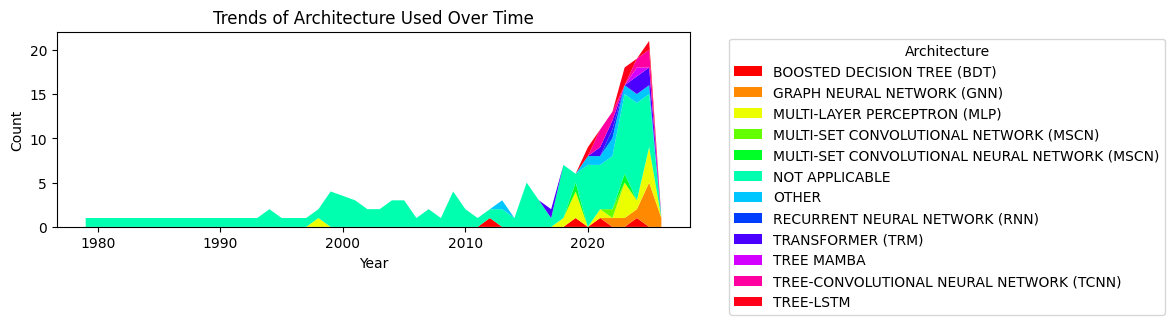

In [71]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Architecture Used_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()

# Force all target columns to numeric
time_series[target_cols] = time_series[target_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Architecture Used_', '') if x.startswith('Architecture Used_') else x,
    inplace=True
)

years = time_series.index.values
stack_data = [time_series[col].values.astype(float) for col in time_series.columns]  # explicit cast

n = len(time_series.columns)
cmap = plt.cm.get_cmap("hsv", n)
colors = [cmap(i) for i in range(n)]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Architecture Used Over Time")
plt.legend(title="Architecture", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Model Architectures Used

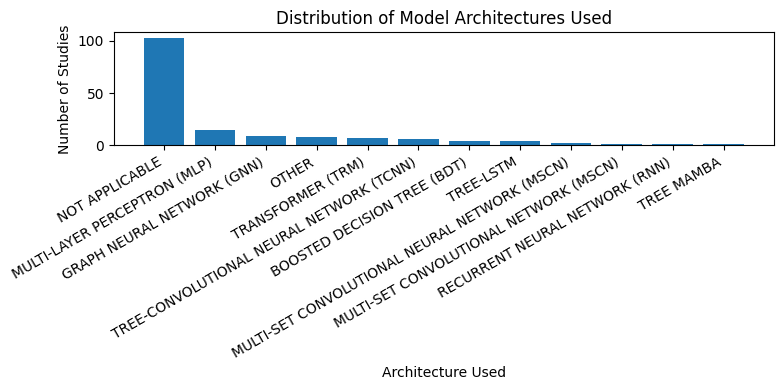

In [72]:
plot_multilabel_distribution(answers_df_encoded, "Architecture Used", "Distribution of Model Architectures Used")

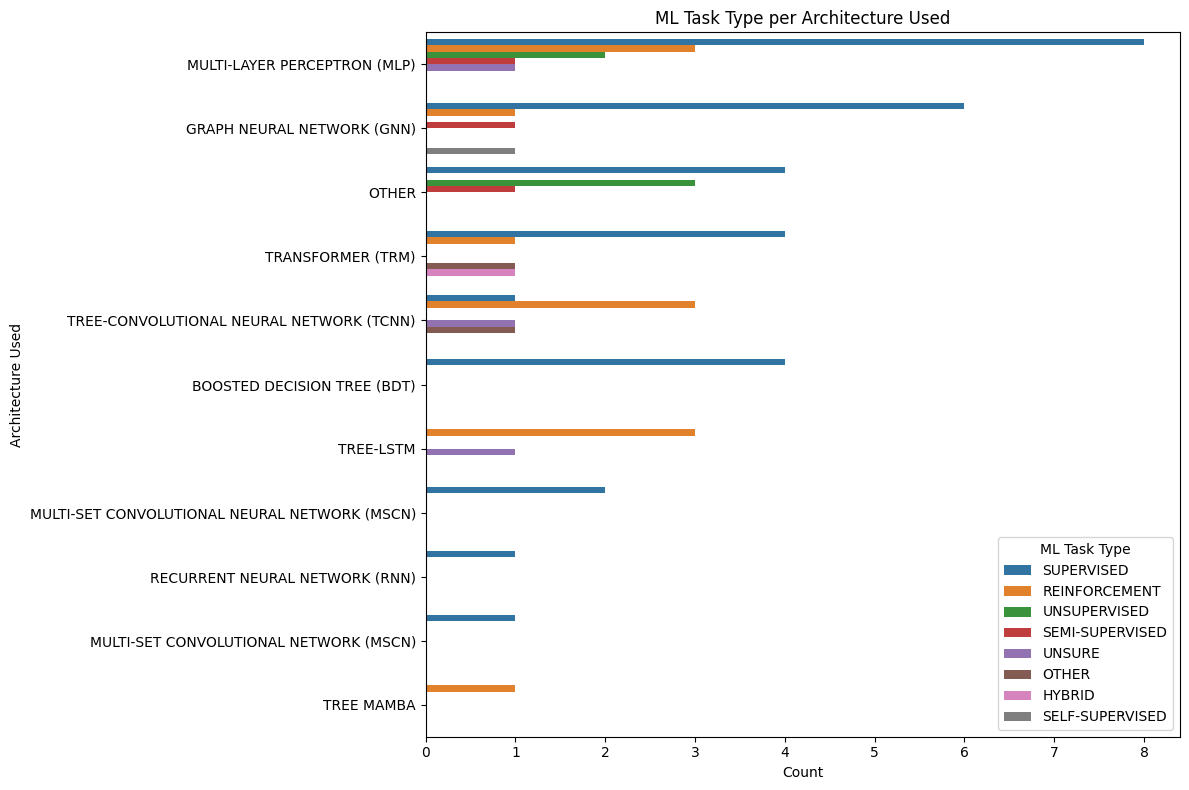

In [75]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Architecture Used",
    col_y="ML Task Type"
)